<a href="https://colab.research.google.com/github/nazrann233/Bitcoin-and-Gold-prediction-in-MYR/blob/main/FYP_GARCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This is my new FYP
### Nazran
- The version that need to use for this part of the analysis is numpy = V1.26.4 and pmdarima = V2.0.4

In [1]:
!pip uninstall numpy pmdarima -y

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [2]:
!pip install "numpy==1.26.4" "pmdarima==2.0.4"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 84.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
ope

# Restart Session then Proceed to run all coding

# Pre-processing Data

## Merge The Bitcoin and Gold (XAU/MYR)

In [1]:
# Load Packages
import pandas as pd

In [2]:
# Loading Data
bitcoin = pd.read_csv('/content/drive/MyDrive/Raw Data/BTC MYR.csv')
gold = pd.read_csv('/content/drive/MyDrive/Raw Data/XAU MYR.csv')
btc_Currency= pd.read_csv('/content/drive/MyDrive/Raw Data/btcusd and currency.csv')


In [3]:

merged = pd.merge(bitcoin, gold, on='Date', how='left') ## change to 'inner' to follow XAU/MYR dates
display(merged.head())

merged['Date'] = pd.to_datetime(merged['Date'], format='%d/%m/%Y')
merged = merged.sort_values(by='Date')

merged['Bitcoin'] = pd.to_numeric(merged['BTC/MYR'].str.replace(',', ''))
merged['Gold']    = pd.to_numeric(merged['Price'].str.replace(',', ''))

##After creating the clean columns, just delete the messy ones:
merged = merged.drop(columns=['BTC/MYR', 'Price'])


# Forward-fill missing 'Gold' values
merged['Gold'] = merged['Gold'].ffill()
display(merged.head())

,Date,BTC/MYR,Price
0,1/1/2016,1862.728,"4,548.43"
1,2/1/2016,1861.4404,NaN
2,3/1/2016,1848.5644,NaN
3,4/1/2016,1873.37255,"4,662.44"
4,5/1/2016,1872.486,"4,674.01"


,Date,Bitcoin,Gold
0,2016-01-01,1862.72800,4548.43
1,2016-01-02,1861.44040,4548.43
2,2016-01-03,1848.56440,4548.43
3,2016-01-04,1873.37255,4662.44
4,2016-01-05,1872.48600,4674.01


In [4]:
display(merged[['Date', 'Bitcoin', 'Gold']].head(60))

,Date,Bitcoin,Gold
0,2016-01-01,1862.72800,4548.43
1,2016-01-02,1861.44040,4548.43
2,2016-01-03,1848.56440,4548.43
3,2016-01-04,1873.37255,4662.44
4,2016-01-05,1872.48600,4674.01
5,2016-01-06,1882.38060,4799.37
6,2016-01-07,2017.19800,4867.63
7,2016-01-08,1979.39945,4828.91
8,2016-01-09,1959.29515,4828.91
9,2016-01-10,1950.11710,4828.91


# Does the USD/MYR Exchange Rate Affect Bitcoin Prices?

In [5]:
btc_Currency.head()
btc_Currency.columns


Index(['Date', 'BTC/USD', 'USD/MYR', 'Unnamed: 3'], dtype='object')

In [6]:
import pandas as pd

# Copy original
df = btc_Currency.copy()

# --- Clean column names robustly ---
# Force the first 3 columns to be Date, BTC_USD, USD_MYR
df = df.rename(columns={
    df.columns[0]: 'Date',
    df.columns[1]: 'BTC_USD',
    df.columns[2]: 'USD_MYR'
})

# --- Date & numeric cleaning ---
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['BTC_USD'] = pd.to_numeric(df['BTC_USD'], errors='coerce')
df['USD_MYR'] = pd.to_numeric(df['USD_MYR'], errors='coerce')

# Keep only rows with valid numbers
df = df.dropna(subset=['Date', 'BTC_USD', 'USD_MYR'])

# Sort by date
df = df.sort_values('Date')

# --- 1. Daily returns ---
df['BTC_Return'] = df['BTC_USD'].pct_change()
df['FX_Return'] = df['USD_MYR'].pct_change()

returns = df[['BTC_Return', 'FX_Return']].dropna()

# --- 2. Volatility ---
btc_std = returns['BTC_Return'].std()
fx_std = returns['FX_Return'].std()

print("=== VOLATILITY (Std Dev of Daily Returns) ===")
print(f"Bitcoin Volatility     : {btc_std:.4f}")
print(f"USD/MYR Volatility     : {fx_std:.4f}")
print(f"Bitcoin is {(btc_std / fx_std):.1f}x more volatile.\n")

# --- 3. Correlation ---
corr = returns['BTC_Return'].corr(returns['FX_Return'])

print("=== CORRELATION RESULT ===")
print(f"BTC vs FX Correlation : {corr:.4f}\n")

# --- 4. Interpretation ---
print("=== INTERPRETATION ===")
if btc_std > fx_std * 10:
    print("Bitcoin volatility is FAR higher → currency effect is negligible.")
else:
    print("Bitcoin volatility is higher but not extremely → some FX influence exists.")

if abs(corr) < 0.2:
    print("Correlation is very low → BTC movements are basically independent of FX.")
elif abs(corr) < 0.5:
    print("Moderate correlation → FX has some influence.")
else:
    print("High correlation → FX strongly affects BTC.")


=== VOLATILITY (Std Dev of Daily Returns) ===
Bitcoin Volatility     : 0.0268
USD/MYR Volatility     : 0.0049
Bitcoin is 5.4x more volatile.

=== CORRELATION RESULT ===
BTC vs FX Correlation : 0.0561

=== INTERPRETATION ===
Bitcoin volatility is higher but not extremely → some FX influence exists.
Correlation is very low → BTC movements are basically independent of FX.


## Raw Data Bitcoin and Gold(XAU/MYR) plot


In [7]:
import numpy as np

In [8]:
import matplotlib.pyplot as plt

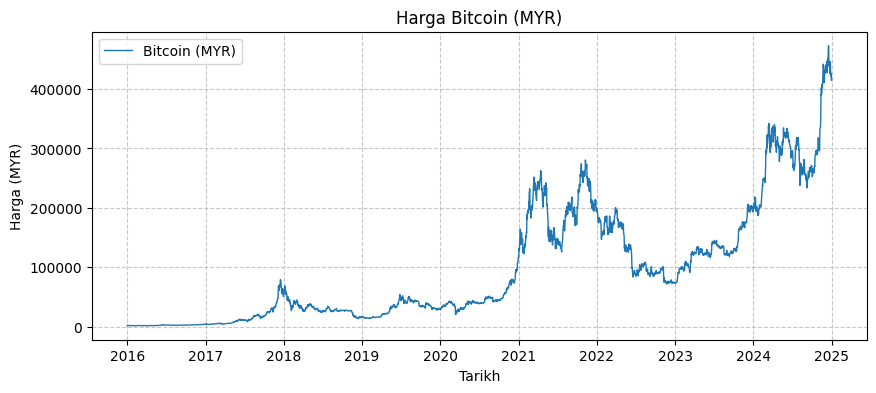

In [9]:
plt.figure(figsize=(10,4))
plt.plot(merged['Date'], merged['Bitcoin'], label='Bitcoin (MYR)', linewidth=1)
plt.title('Harga Bitcoin (MYR)')
plt.xlabel('Tarikh')
plt.ylabel('Harga (MYR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

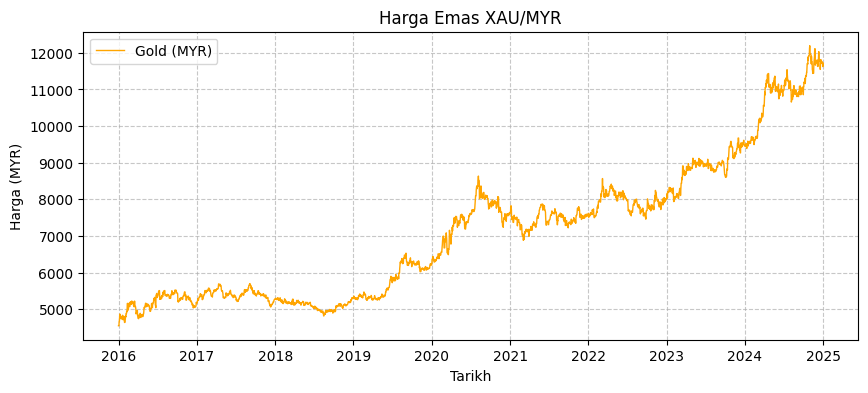

In [10]:
plt.figure(figsize=(10,4))
plt.plot(merged['Date'], merged['Gold'], label='Gold (MYR)', color='orange', linewidth=1)
plt.title('Harga Emas XAU/MYR')
plt.xlabel('Tarikh')
plt.ylabel('Harga (MYR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Raw Bitcoin and Gold ADF

In [23]:
from statsmodels.tsa.stattools import adfuller

In [24]:
# ADF ON RAW DATA
# ========================
from statsmodels.tsa.stattools import adfuller

def adf_print(series, name):
    res = adfuller(series.dropna())
    print(f"\n--- ADF Test: {name} ---")
    print(f"ADF Statistic: {res[0]:.6f}")
    print(f"p-value     : {res[1]:.6f}")
    for k, v in res[4].items():
        print(f"Critical Value ({k}): {v:.4f}")
    print("→ Stationary ✅" if res[1] < 0.05 else "→ Non-stationary ❌")

adf_print(merged['Bitcoin'], 'Raw Bitcoin')
adf_print(merged['Gold'],    'Raw Gold')


--- ADF Test: Raw Bitcoin ---
ADF Statistic: -0.102345
p-value     : 0.949204
Critical Value (1%): -3.4324
Critical Value (5%): -2.8624
Critical Value (10%): -2.5672
→ Non-stationary ❌

--- ADF Test: Raw Gold ---
ADF Statistic: 0.724747
p-value     : 0.990319
Critical Value (1%): -3.4323
Critical Value (5%): -2.8624
Critical Value (10%): -2.5672
→ Non-stationary ❌



# Log Return

In [25]:
# Calculate log returns (natural log difference between consecutive prices)
merged['Bitcoin_logret'] = np.log(merged['Bitcoin'] / merged['Bitcoin'].shift(1))
merged['Gold_logret']    = np.log(merged['Gold'] / merged['Gold'].shift(1))

# Drop any missing values caused by the shift
merged = merged.dropna(subset=['Bitcoin_logret', 'Gold_logret'])

# Display first few rows to check
display(merged[['Date', 'Bitcoin_logret', 'Gold_logret']].head(50))

,Date,Bitcoin_logret,Gold_logret
2,2016-01-03,-0.006941,0.000000
3,2016-01-04,0.013331,0.024757
4,2016-01-05,-0.000473,0.002478
5,2016-01-06,0.005270,0.026467
6,2016-01-07,0.069172,0.014123
7,2016-01-08,-0.018916,-0.007986
8,2016-01-09,-0.010209,0.000000
9,2016-01-10,-0.004695,0.000000
10,2016-01-11,0.009742,-0.007723
11,2016-01-12,-0.004799,-0.000013


In [26]:
# ADF ON LOG RETURNS
# ========================
from statsmodels.tsa.stattools import adfuller

def adf_print(series, name):
    res = adfuller(series.dropna())
    print(f"\n--- ADF Test: {name} ---")
    print(f"ADF Statistic: {res[0]:.6f}")
    print(f"p-value     : {res[1]:.6f}")
    for k, v in res[4].items():
        print(f"Critical Value ({k}): {v:.4f}")
    print("→ Stationary ✅" if res[1] < 0.05 else "→ Non-stationary ❌")

adf_print(merged['Bitcoin_logret'], 'Bitcoin Log Return')
adf_print(merged['Gold_logret'],    'Gold Log Return')


--- ADF Test: Bitcoin Log Return ---
ADF Statistic: -39.939749
p-value     : 0.000000
Critical Value (1%): -3.4323
Critical Value (5%): -2.8624
Critical Value (10%): -2.5672
→ Stationary ✅

--- ADF Test: Gold Log Return ---
ADF Statistic: -43.357640
p-value     : 0.000000
Critical Value (1%): -3.4323
Critical Value (5%): -2.8624
Critical Value (10%): -2.5672
→ Stationary ✅


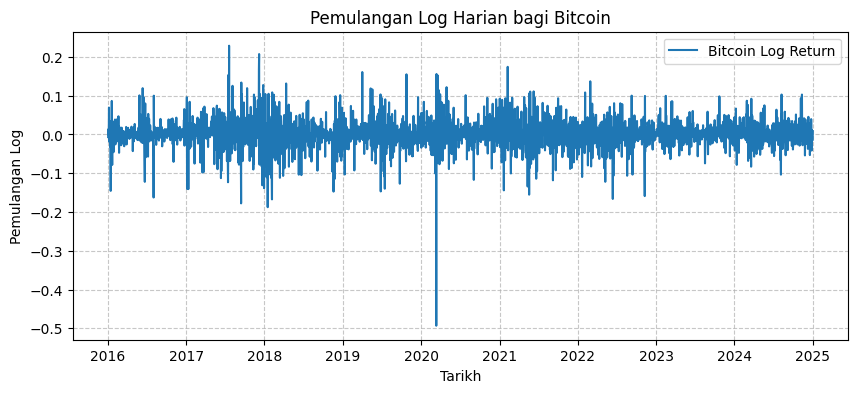

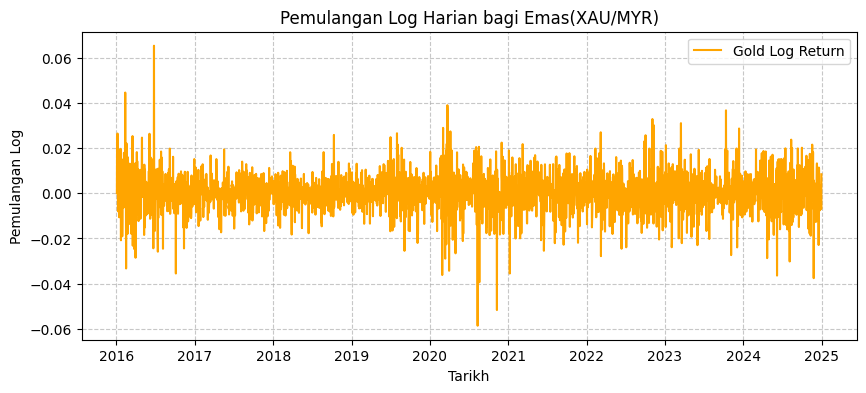

In [27]:
#Plot the log returns ---
plt.figure(figsize=(10,4))
plt.plot(merged['Date'], merged['Bitcoin_logret'], label='Bitcoin Log Return')
plt.title('Pemulangan Log Harian bagi Bitcoin')
plt.xlabel('Tarikh')
plt.ylabel('Pemulangan Log')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(merged['Date'], merged['Gold_logret'], label='Gold Log Return', color='orange')
plt.title('Pemulangan Log Harian bagi Emas(XAU/MYR)')
plt.xlabel('Tarikh')
plt.ylabel('Pemulangan Log')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

##  ACF and PACF of Log Returns( measures "How much did the price change?") (Direction and amount)


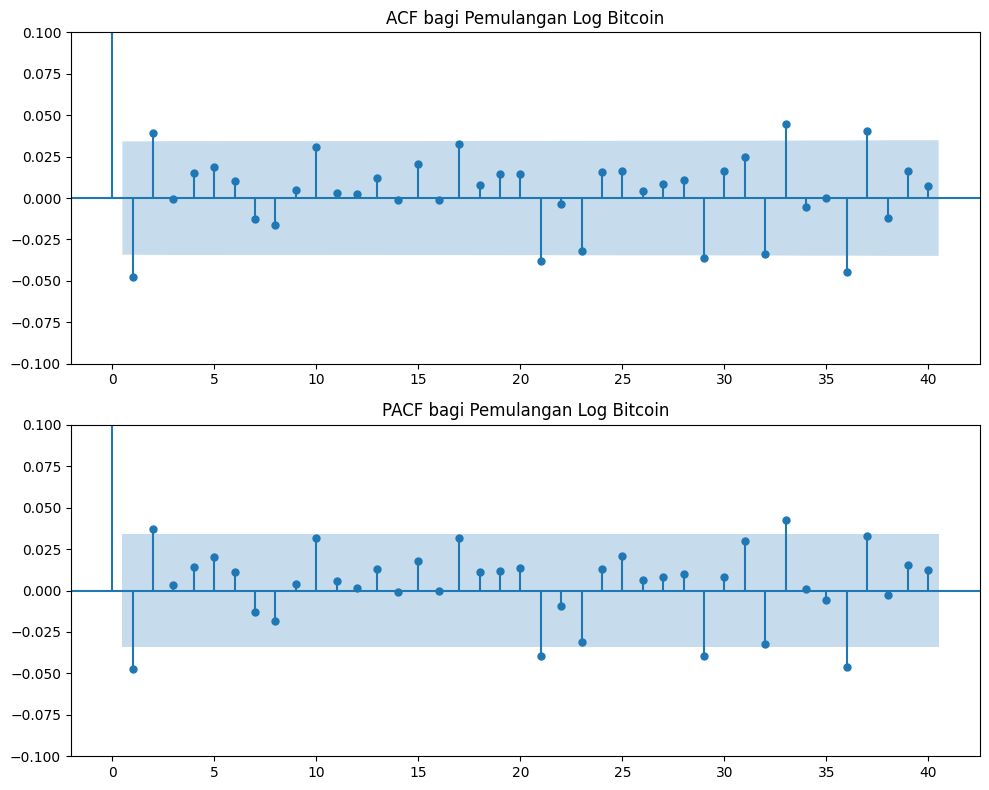

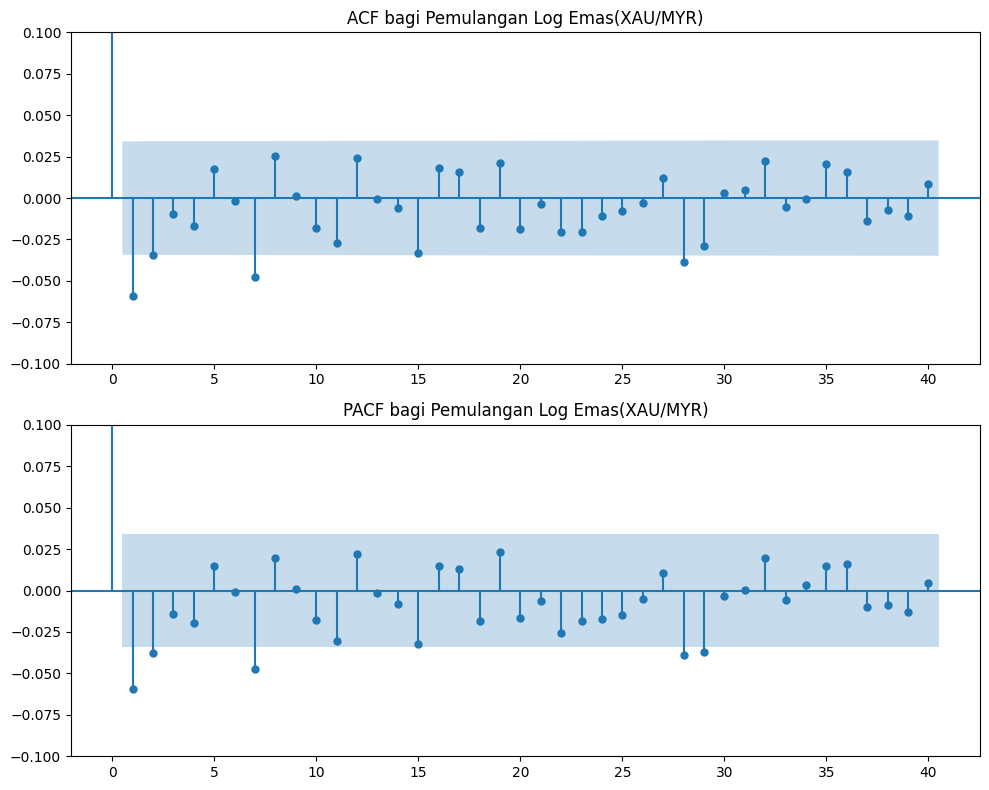

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for Bitcoin Log Returns
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(merged['Bitcoin_logret'].dropna(), ax=axes[0], lags=40)
plot_pacf(merged['Bitcoin_logret'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF bagi Pemulangan Log Bitcoin')
axes[1].set_title('PACF bagi Pemulangan Log Bitcoin')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Plot ACF and PACF for Gold Log Returns
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(merged['Gold_logret'].dropna(), ax=axes[0], lags=40)
plot_pacf(merged['Gold_logret'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF bagi Pemulangan Log Emas(XAU/MYR)')
axes[1].set_title('PACF bagi Pemulangan Log Emas(XAU/MYR)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

## ACF and PACF Squared Log Returns (This measures "How volatile was the market?") (Magnitude/Risk only, ignoring direction).


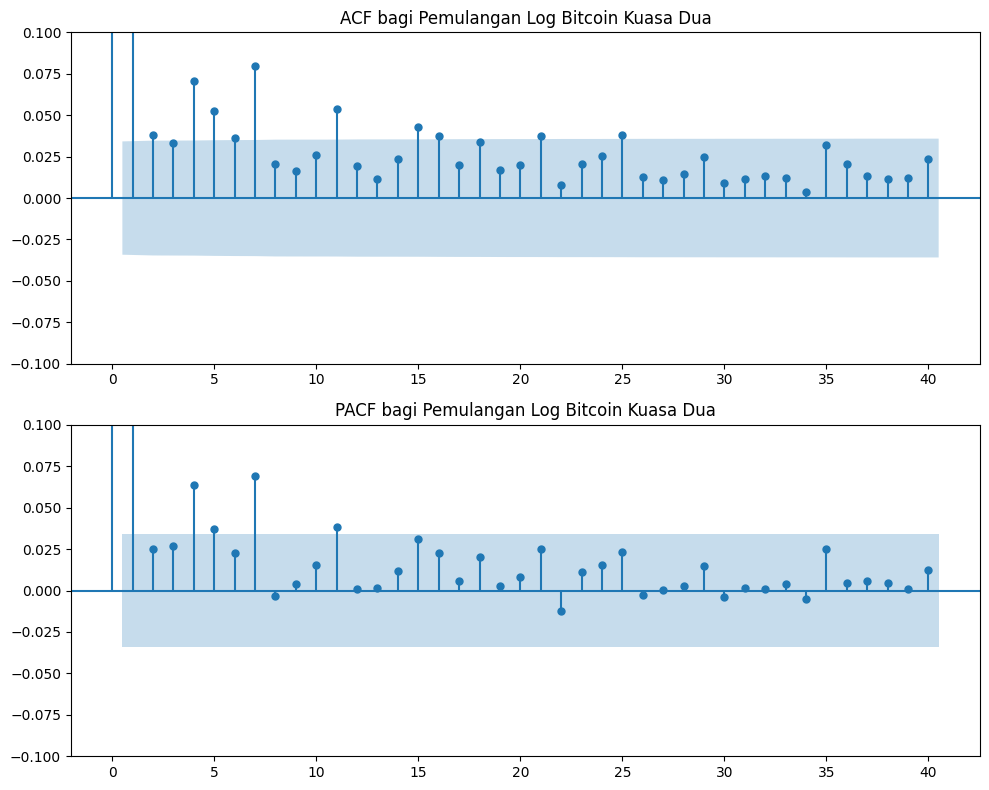

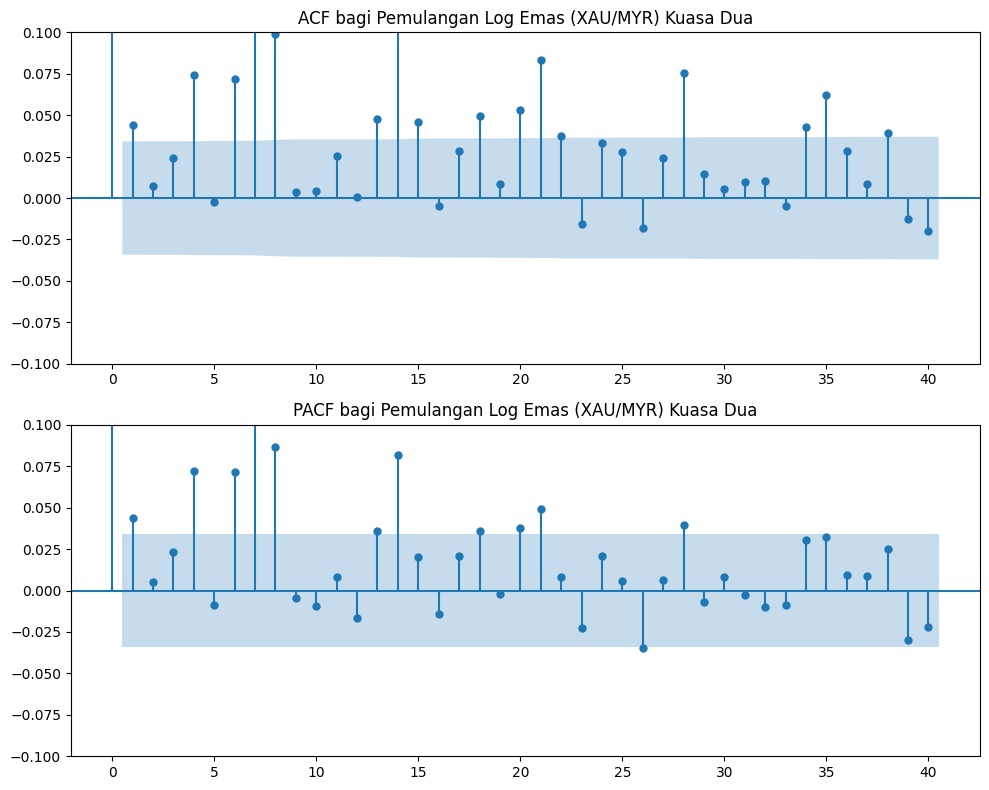

In [29]:
# Calculate squared log returns
merged['Bitcoin_logret_sq'] = merged['Bitcoin_logret']**2
merged['Gold_logret_sq'] = merged['Gold_logret']**2

# Plot ACF and PACF for squared Bitcoin Log Returns
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(merged['Bitcoin_logret_sq'].dropna(), ax=axes[0], lags=40)
plot_pacf(merged['Bitcoin_logret_sq'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF bagi Pemulangan Log Bitcoin Kuasa Dua')
axes[1].set_title('PACF bagi Pemulangan Log Bitcoin Kuasa Dua')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Plot ACF and PACF for squared Gold Log Returns
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(merged['Gold_logret_sq'].dropna(), ax=axes[0], lags=40)
plot_pacf(merged['Gold_logret_sq'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF bagi Pemulangan Log Emas (XAU/MYR) Kuasa Dua')
axes[1].set_title('PACF bagi Pemulangan Log Emas (XAU/MYR) Kuasa Dua')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Descriptive Statistic

In [30]:
# Calculate and display descriptive statistics for log returns
print("Descriptive statistics for Bitcoin Log Returns:")
display(merged['Bitcoin_logret'].describe())

print("\nDescriptive statistics for Gold Log Returns:")
display(merged['Gold_logret'].describe())

print("\nSkewness for Bitcoin Log Returns:", merged['Bitcoin_logret'].skew())
print("Kurtosis for Bitcoin Log Returns:", merged['Bitcoin_logret'].kurtosis())

print("\nSkewness for Gold Log Returns:", merged['Gold_logret'].skew())
print("Kurtosis for Gold Log Returns:", merged['Gold_logret'].kurtosis())

Descriptive statistics for Bitcoin Log Returns:


,Bitcoin_logret
count,3286.000000
mean,0.001648
std,0.037121
min,-0.493155
25%,-0.012866
50%,0.001429
75%,0.017338
max,0.228652



Descriptive statistics for Gold Log Returns:


,Gold_logret
count,3286.000000
mean,0.000288
std,0.007687
min,-0.058673
25%,-0.002182
50%,0.000000
75%,0.003135
max,0.065374



Skewness for Bitcoin Log Returns: -0.7764381281408228
Kurtosis for Bitcoin Log Returns: 12.942647849938977

Skewness for Gold Log Returns: -0.14237010715463774
Kurtosis for Gold Log Returns: 6.469693760931854


# Split 70:30


In [31]:
# Split data into training and testing sets (70:30 ratio) using log return data
train_size = int(len(merged) * 0.7)
train_data = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[0:train_size]
test_data = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[train_size:len(merged)]

print("Training data size:", len(train_data))
print("Testing data size:", len(test_data))

Training data size: 2300
Testing data size: 986


## ARIMA before Scalling


In [32]:
from pmdarima import auto_arima

In [33]:
import warnings
warnings.filterwarnings("ignore")

In [34]:
# Fit auto_arima model on Bitcoin log returns
model_bitcoin = auto_arima(train_data['Bitcoin_logret'], seasonal=False, suppress_warnings=True)
print("Bitcoin Auto ARIMA Model Summary:")
print(model_bitcoin.summary())

# Fit auto_arima model on Gold log returns
model_gold = auto_arima(train_data['Gold_logret'], seasonal=False, suppress_warnings=True)
print("\nGold Auto ARIMA Model Summary:")
print(model_gold.summary())

Bitcoin Auto ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2300
Model:               SARIMAX(2, 0, 0)   Log Likelihood                4122.334
Date:                Fri, 05 Dec 2025   AIC                          -8236.667
Time:                        10:31:40   BIC                          -8213.704
Sample:                             0   HQIC                         -8228.295
                               - 2300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0020      0.001      2.331      0.020       0.000       0.004
ar.L1         -0.0494      0.014     -3.519      0.000      -0.077      -0.022
ar.L2          0.0

## Scaled ARIMA


In [37]:
import pmdarima as pm

In [25]:
from statsmodels.tsa.arima.model import ARIMA
# Fit auto_arima model on Bitcoin log returns
model_bitcoin = pm.auto_arima(train_data['Bitcoin_logret']*100,
                              start_p=1, start_q=1,
                              max_p=5, max_q=5,
                              m=1,            # frequency of series (set to 1 for non-seasonal data)
                              d=None,         # let the model determine 'd'
                              seasonal=False, # assuming no seasonality
                              test='adf', # use ADF test to find 'd'
                              trace=True,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)
print("Bitcoin Auto ARIMA Model Summary:")
print(model_bitcoin.summary())


# Fit auto_arima model on Gold log returns
model_gold = auto_arima(train_data['Gold_logret']*100,
                        start_p=1, start_q=1,
                        max_p=5, max_q=5,
                        m=1,            # frequency of series (set to 1 for non-seasonal data)
                        d=None,         # let the model determine 'd'
                        seasonal=False, # assuming no seasonality
                        test='adf', # use ADF test to find 'd'
                        trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)
print("\nGold Auto ARIMA Model Summary:")
print(model_gold.summary())

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=12951.207, Time=1.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=12954.758, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=12951.346, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=12951.693, Time=0.25 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=12949.358, Time=1.52 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=12950.841, Time=0.42 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=12954.804, Time=0.59 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=12950.056, Time=3.44 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=12949.717, Time=1.39 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=12952.811, Time=0.26 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=12951.718, Time=2.99 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=12949.117, Time=1.51 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=12947.305, Time=1.40 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=12947.613, Time=0.32 sec
 ARIMA(1,0,0)(0,0,0

### Plot Reja dan sebagainya





In [26]:
%pip install seaborn

In [27]:
%pip install scipy

In [28]:
# 1. Get residuals from your auto_arima models (which are already fitted)
btc_residuals = model_bitcoin.resid()
gold_residuals = model_gold.resid()

# 2. Rescale the residuals to fix the DataScaleWarning
btc_resid_scaled = btc_residuals
gold_resid_scaled = gold_residuals

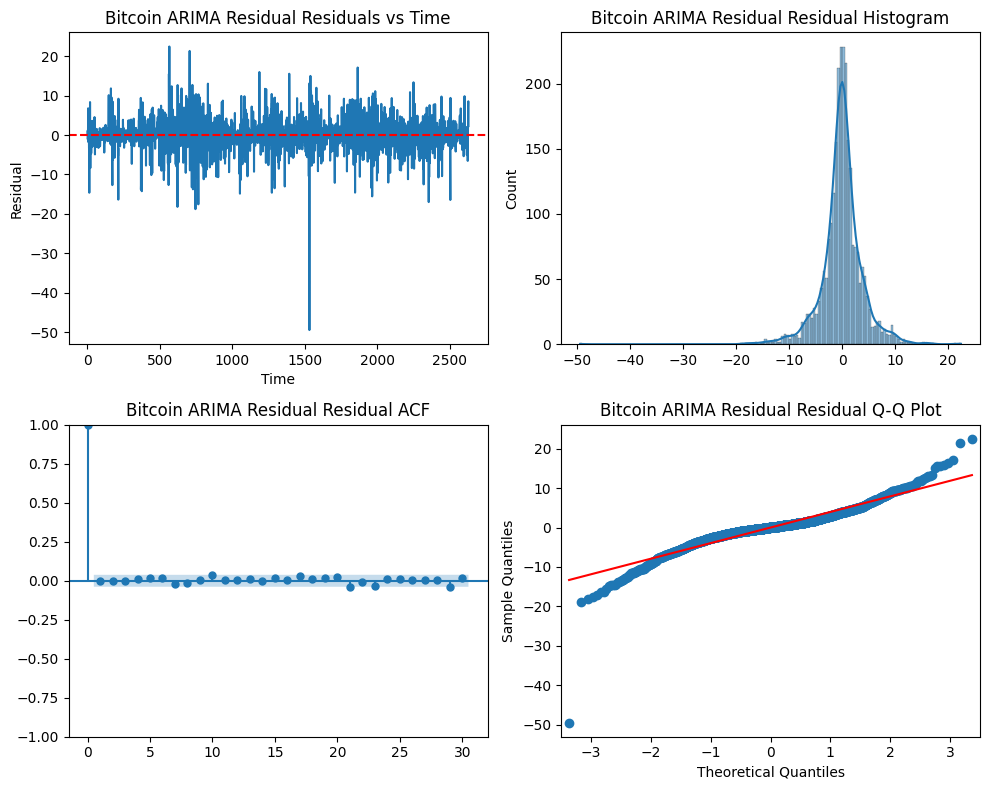

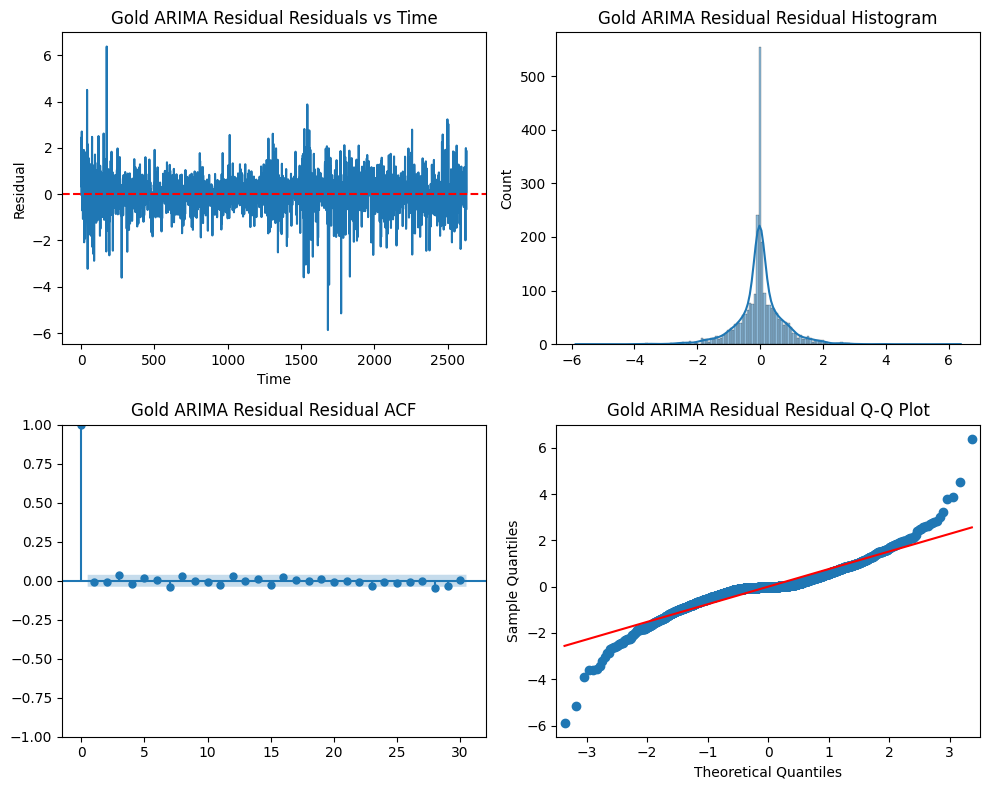

In [46]:
# ================================
# 1. RESIDUAL DIAGNOSTIC PLOTS
# ================================
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot

def residual_diagnostic_plots(residuals, title_prefix):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    # (a) Residual vs Time
    axes[0, 0].plot(residuals)
    axes[0, 0].axhline(0, linestyle='--',color='red')
    axes[0, 0].set_title(f'{title_prefix} Residuals vs Time')
    axes[0, 0].set_xlabel('Time')
    axes[0, 0].set_ylabel('Residual')

    # (b) Histogram
    sns.histplot(residuals, kde=True, ax=axes[0, 1])
    axes[0, 1].set_title(f'{title_prefix} Residual Histogram')

    # (c) ACF plot
    plot_acf(residuals, ax=axes[1, 0], lags=30)
    axes[1, 0].set_title(f'{title_prefix} Residual ACF')

    # (d) Q-Q plot
    qqplot(residuals, line='s', ax=axes[1, 1])
    axes[1, 1].set_title(f'{title_prefix} Residual Q-Q Plot')

    plt.tight_layout()
    plt.show()

# ---- Bitcoin ----
residual_diagnostic_plots(btc_resid_scaled, "Bitcoin ARIMA Residual")

# ---- Gold ----
residual_diagnostic_plots(gold_resid_scaled, "Gold ARIMA Residual")

In [30]:
# ================================
# 2. LJUNG-BOX TEST
# ================================
from statsmodels.stats.diagnostic import acorr_ljungbox

print("\n=== Ljung-Box Test: Bitcoin ===")
lb_btc = acorr_ljungbox(btc_resid_scaled, lags=[10, 20], return_df=True)
print(lb_btc)

print("\n=== Ljung-Box Test: Gold ===")
lb_gold = acorr_ljungbox(gold_resid_scaled, lags=[10, 20], return_df=True)
print(lb_gold)



=== Ljung-Box Test: Bitcoin ===
     lb_stat  lb_pvalue
10   8.41669   0.588205
20  15.94528   0.720013

=== Ljung-Box Test: Gold ===
      lb_stat  lb_pvalue
10   1.775877   0.997787
20  17.563620   0.616130


In [31]:
# ================================
# 4. JARQUE-BERA TEST
# ================================
from statsmodels.stats.stattools import jarque_bera

print("\n=== Jarque-Bera Test: Bitcoin ===")
jb_btc = jarque_bera(btc_resid_scaled)
print(f"JB stat   : {jb_btc[0]:.4f}")
print(f"JB p-value: {jb_btc[1]:.4f}")
print(f"Skewness  : {jb_btc[2]:.4f}")
print(f"Kurtosis  : {jb_btc[3]:.4f}")

print("\n=== Jarque-Bera Test: Gold ===")
jb_gold = jarque_bera(gold_resid_scaled)
print(f"JB stat   : {jb_gold[0]:.4f}")
print(f"JB p-value: {jb_gold[1]:.4f}")
print(f"Skewness  : {jb_gold[2]:.4f}")
print(f"Kurtosis  : {jb_gold[3]:.4f}")



=== Jarque-Bera Test: Bitcoin ===
JB stat   : 15465.3116
JB p-value: 0.0000
Skewness  : -0.8446
Kurtosis  : 15.5906

=== Jarque-Bera Test: Gold ===
JB stat   : 6098.3714
JB p-value: 0.0000
Skewness  : -0.1577
Kurtosis  : 10.9709


## ARCH LM Test on residuals

In [32]:
# ================================
# ARCH-LM TEST
# ================================
from statsmodels.stats.diagnostic import het_arch

print("\n=== ARCH-LM Test: Bitcoin ===")
arch_btc = het_arch(btc_resid_scaled, nlags=10)
print(f"LM stat   : {arch_btc[0]:.4f}")
print(f"LM p-value: {arch_btc[1]:.4f}")
print(f"F stat    : {arch_btc[2]:.4f}")
print(f"F p-value : {arch_btc[3]:.4f}")

print("\n=== ARCH-LM Test: Gold ===")
arch_gold = het_arch(gold_resid_scaled, nlags=10)
print(f"LM stat   : {arch_gold[0]:.4f}")
print(f"LM p-value: {arch_gold[1]:.4f}")
print(f"F stat    : {arch_gold[2]:.4f}")
print(f"F p-value : {arch_gold[3]:.4f}")



=== ARCH-LM Test: Bitcoin ===
LM stat   : 40.9907
LM p-value: 0.0000
F stat    : 4.1537
F p-value : 0.0000

=== ARCH-LM Test: Gold ===
LM stat   : 87.1927
LM p-value: 0.0000
F stat    : 9.0209
F p-value : 0.0000


## Ljung-Box test on squared residuals


---
Since these p-values are significantly less than 0.05, we reject the null hypothesis. This proves that while the price direction is random (as seen in your earlier tests), the volatility is highly correlated. High volatility today does predict high volatility tomorrow.




In [34]:
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Manually square the scaled residuals
# This transforms the data from "Price Error" to "Volatility Magnitude"
btc_resid_sq = btc_resid_scaled ** 2
gold_resid_sq = gold_resid_scaled ** 2

# 2. Run Ljung-Box Test on these SQUARED residuals
# We use lags=[10, 20] to check for dependence over the short and medium term
print("=== Ljung-Box Test on Squared Residuals: Bitcoin ===")
lb_btc_sq = acorr_ljungbox(btc_resid_sq, lags=[10, 20], return_df=True)
print(lb_btc_sq)

print("\n=== Ljung-Box Test on Squared Residuals: Gold ===")
lb_gold_sq = acorr_ljungbox(gold_resid_sq, lags=[10, 20], return_df=True)
print(lb_gold_sq)

=== Ljung-Box Test on Squared Residuals: Bitcoin ===
      lb_stat     lb_pvalue
10  50.501576  2.157962e-07
20  66.907075  5.777629e-07

=== Ljung-Box Test on Squared Residuals: Gold ===
       lb_stat     lb_pvalue
10  103.239220  1.222452e-17
20  166.244685  4.647298e-25


# GARCH with t distribution


In [35]:
%pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 37.4 MB/s eta 0:00:00


In [36]:
from arch import arch_model

In [46]:
from arch import arch_model
import pandas as pd

# 3. Fit GARCH(1,1) on the SCALED RESIDUALS
garch_btc = arch_model(btc_resid_scaled,
                       mean='Zero',
                       vol='Garch', p=1, q=1,
                       dist='t')

res_garch_btc = garch_btc.fit(disp='off')
print("Bitcoin GARCH(1,1) on ARMA(2,2) Residuals (t-distribution):")
print(res_garch_btc.summary())

# 4. Fit GARCH(1,1) on the SCALED RESIDUALS for Gold
garch_gold = arch_model(gold_resid_scaled,
                        mean='Zero',
                        vol='Garch', p=1, q=1,
                        dist='t')

res_garch_gold = garch_gold.fit(disp='off')
print("\nGold GARCH(1,1) on MA(1) Residuals (t-distribution):")
print(res_garch_gold.summary())

# 5. Fit EGARCH(1,1) on the SCALED RESIDUALS for Gold
egarch11_gold = arch_model(gold_resid_scaled,
                         mean='Zero',
                         vol='EGARCH', p=1,o=1, q=1,
                         dist='t')

res11_egarch_gold = egarch11_gold.fit(disp='off')
print("\nGold EGARCH(1,1) on MA(1) Residuals (t-distribution):")
print(res11_egarch_gold.summary())



# 5. Fit EGARCH(2,2) on the SCALED RESIDUALS for Gold
egarch22_gold = arch_model(gold_resid_scaled,
                         mean='Zero',
                         vol='EGARCH', p=2, q=2,
                         dist='t')

res_egarch22_gold = egarch22_gold.fit(disp='off')
print("\nGold EGARCH(2,2) on MA(1) Residuals (t-distribution):")
print(res_egarch22_gold.summary())



Bitcoin GARCH(1,1) on ARMA(2,2) Residuals (t-distribution):
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -5994.01
Distribution:      Standardized Student's t   AIC:                           11996.0
Method:                  Maximum Likelihood   BIC:                           12019.0
                                              No. Observations:                 2300
Date:                      Thu, Dec 04 2025   Df Residuals:                     2300
Time:                              18:12:01   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
-----------------------

### Generate σₜ (conditional volatility) for the test set

In [47]:
# In-sample conditional volatility for Bitcoin
btc_sigma_insample = res_garch_btc.conditional_volatility
print(btc_sigma_insample.tail())


2296    3.237565
2297    3.123421
2298    2.993844
2299    2.934590
2300    2.946082
Name: cond_vol, dtype: float64


In [48]:
# In-sample conditional volatility for Gold (EGARCH 2,2)
gold_sigma_insample = res_egarch22_gold.conditional_volatility
print(gold_sigma_insample.tail())


2296    1.409669
2297    1.407262
2298    1.339063
2299    1.319812
2300    1.607952
Name: cond_vol, dtype: float64


In [63]:
btc_sigma_full = res_garch_btc.conditional_volatility
h = len(test_data)

btc_sigma_test = btc_sigma_full[-h:].values

print("Bitcoin Test-Set Volatility Forecast:")
print(btc_sigma_test)
print("Length sigma_test =", len(btc_sigma_test))


Bitcoin Test-Set Volatility Forecast:
[ 4.41990216  4.40564331  4.21832123  4.0353283   4.42021354  4.23251348
  4.04819934  4.1331702   4.78207297  4.60752794  4.39137526  4.21029192
  4.02068543  4.16529201  3.98798566  4.31457908  4.11904877  4.03863947
  3.93647877  3.75846013  3.67604685  3.5579708   3.72944994  3.64772156
  3.49216531  3.33752983  3.21300854  3.61423093  3.55163733  3.40743637
  3.26719209  3.26998786  3.14845539  3.01969812  2.9163398   2.89306709
  2.77821446  2.7523827   2.66087124  2.55807405  2.4628013   2.38185086
  2.29843656  2.21920104  2.16279816  2.13186855  2.16204214  2.08924501
  2.36039737  4.70952242  4.51186164  4.49154566  4.29570596  4.09701603
  3.96885907  3.86147319  3.68738854  3.52413464  3.41794915  3.29662864
  3.15659102  3.18959066  3.2793946   3.13736072  3.30791268  3.1641487
  3.28380802  3.14125936  3.00893258  2.88662145  2.85156464  2.82712944
  2.71714132  2.6609529   2.55632719  2.64884972  2.54599702  2.57155784
  3.35923113  

In [59]:
gold_sigma_full = res_egarch22_gold.conditional_volatility
h = len(test_data)

gold_sigma_test = gold_sigma_full[-h:].values

print("Gold σ_t for last h observations (used as test period):")
print(gold_sigma_test)
print("Length sigma_test =", len(gold_sigma_test))


Gold σ_t for last h observations (used as test period):
[1.39566009 2.42213171 1.30459568 1.56653021 1.42831007 1.43001982
 1.82519659 1.39571542 1.78842234 1.5330044  1.75637946 1.36380258
 1.42730558 1.93033965 1.56449272 1.53675167 1.38552079 2.48972015
 1.32278766 1.47588652 1.51042704 1.89083418 1.34675157 1.70081177
 1.6111727  1.41202565 1.42413662 1.65993367 1.92290015 1.3527676
 3.1734312  1.479681   1.54150541 1.51956478 1.720001   1.86957183
 1.70808991 1.54246104 1.82225864 1.47724357 1.48335851 1.69367113
 1.60953285 1.5820553  1.57730512 1.66560563 1.40614594 1.46067024
 1.65051424 1.60891632 2.12496401 1.38435385 1.84595246 1.38042544
 1.47475797 2.28740409 1.46751542 2.12654678 1.44609403 1.5604824
 1.46134992 1.44683727 1.7123977  1.66632195 1.41058121 1.92201965
 1.48141006 1.44591495 1.42106824 1.50429772 1.68579403 1.5615946
 1.46566195 1.36802592 1.38870405 1.33519999 1.56116593 1.3868297
 1.39892371 1.57872898 1.27197717 1.30471249 1.28468224 1.62730743
 1.3427814

## plot BOTH Bitcoin & Gold conditional volatility (σₜ) for the test period.

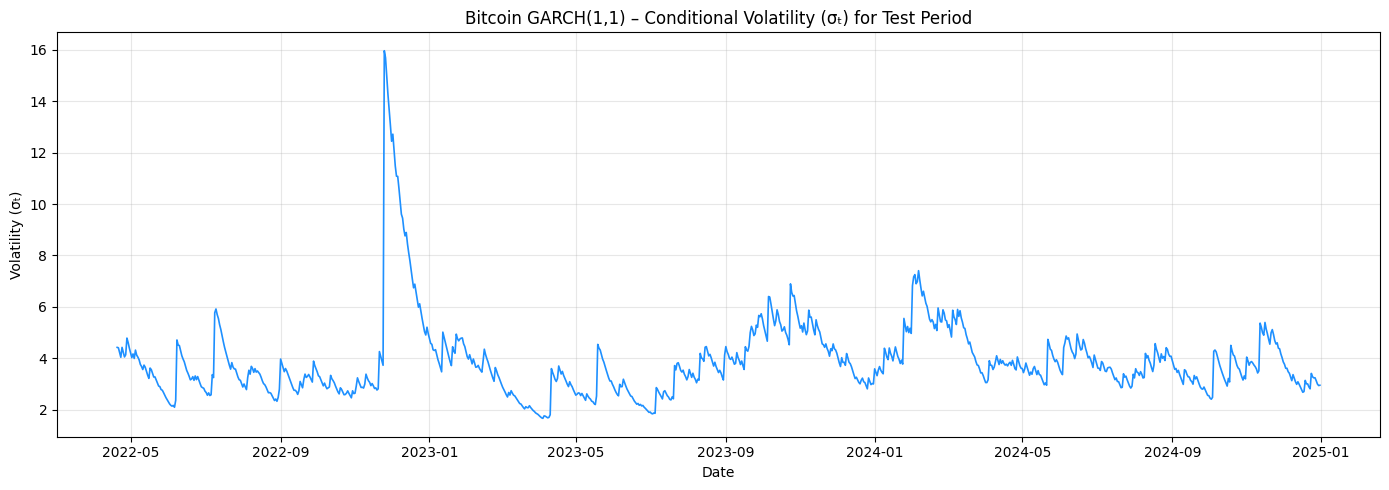

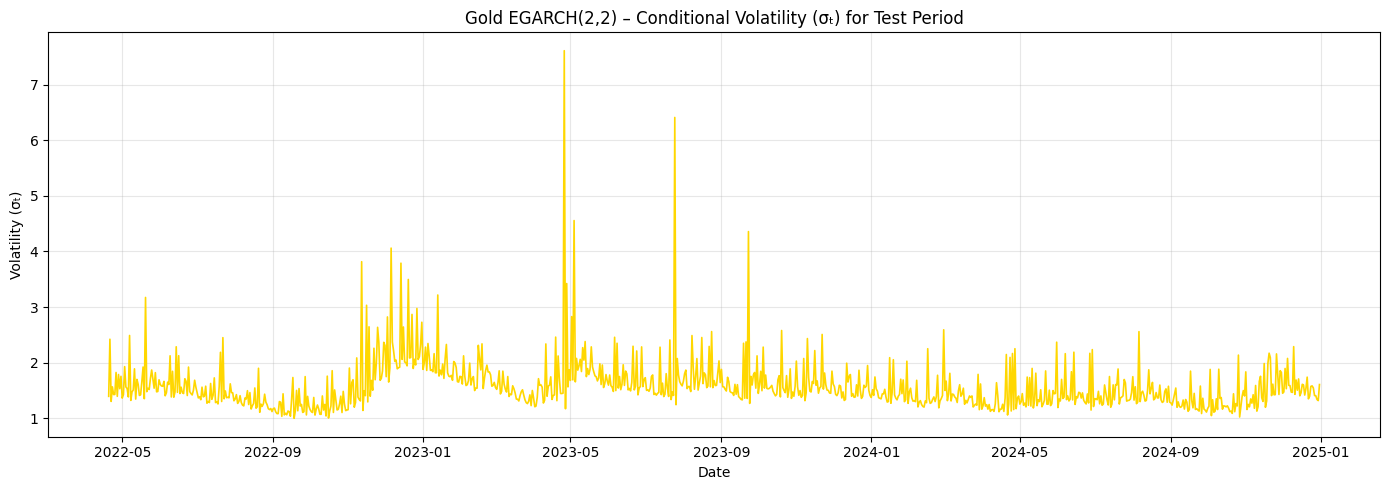

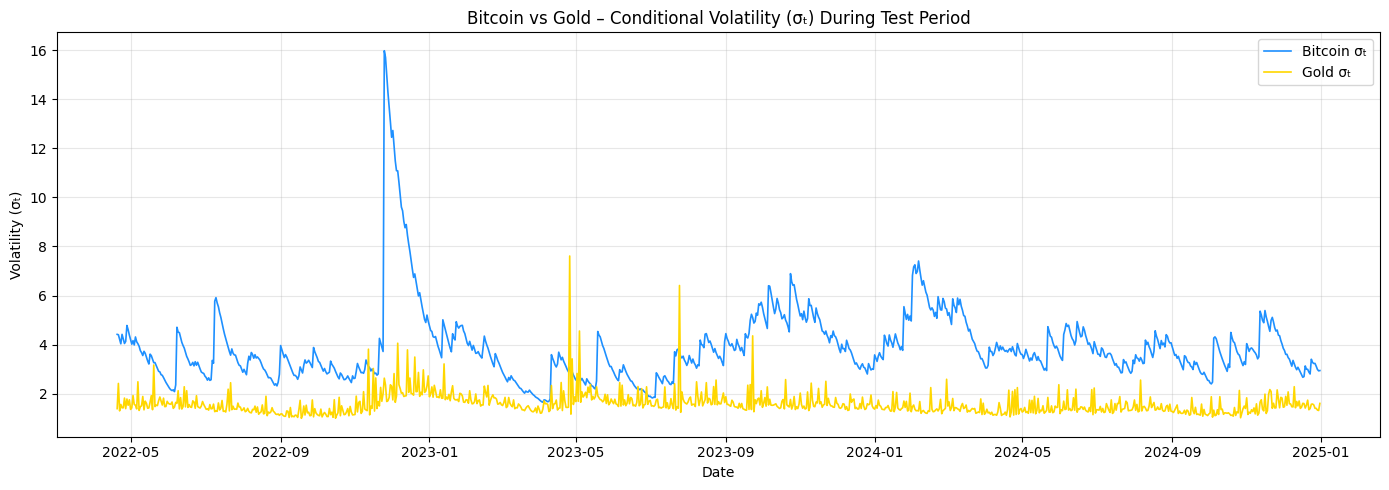

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

test_data['Date'] = pd.to_datetime(test_data['Date'])
dates_test = test_data['Date']

# ============================
# 1. Bitcoin σₜ Plot
# ============================
plt.figure(figsize=(14,5))
plt.plot(dates_test, btc_sigma_test, color='dodgerblue', linewidth=1.2)
plt.title("Bitcoin GARCH(1,1) – Conditional Volatility (σₜ) for Test Period")
plt.xlabel("Date")
plt.ylabel("Volatility (σₜ)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================
# 2. Gold σₜ Plot
# ============================
plt.figure(figsize=(14,5))
plt.plot(dates_test, gold_sigma_test, color='gold', linewidth=1.2)
plt.title("Gold EGARCH(2,2) – Conditional Volatility (σₜ) for Test Period")
plt.xlabel("Date")
plt.ylabel("Volatility (σₜ)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================
# 3. Comparison Plot: Bitcoin vs Gold
# ============================
plt.figure(figsize=(14,5))
plt.plot(dates_test, btc_sigma_test, color='dodgerblue', linewidth=1.2, label='Bitcoin σₜ')
plt.plot(dates_test, gold_sigma_test, color='gold', linewidth=1.2, label='Gold σₜ')

plt.title("Bitcoin vs Gold – Conditional Volatility (σₜ) During Test Period")
plt.xlabel("Date")
plt.ylabel("Volatility (σₜ)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## ACF of the Squared Standardized Residuals (Is the Volatility Clustering Gone?)(GARCH)
*   plot should look like "White Noise." No significant spikes should stick out of the blue shaded area.
*   If you see spikes: Your GARCH model failed to capture all the volatility. You might need a higher order (e.g., GARCH(2,2)) or a different model (EGARCH).



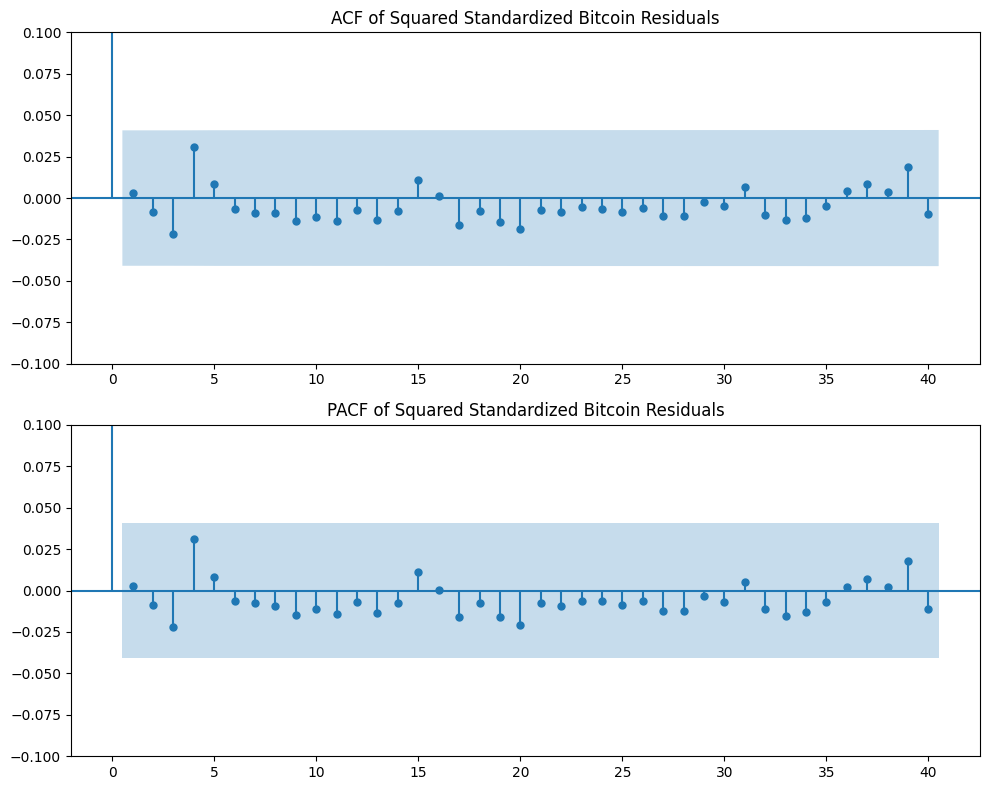

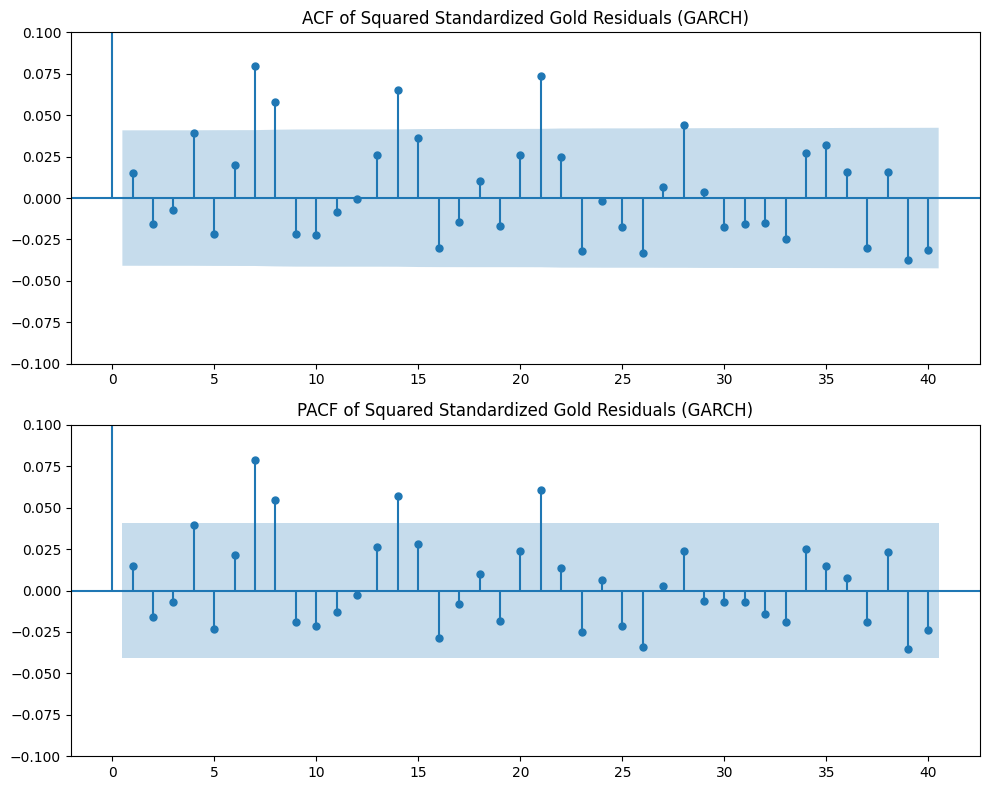

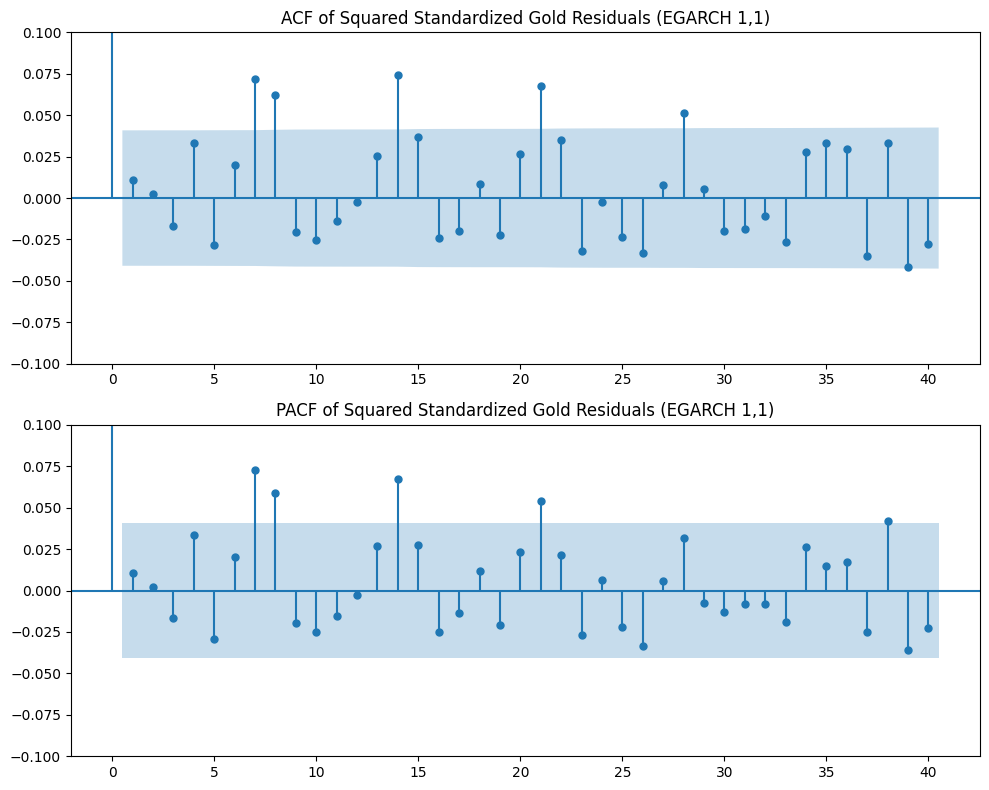

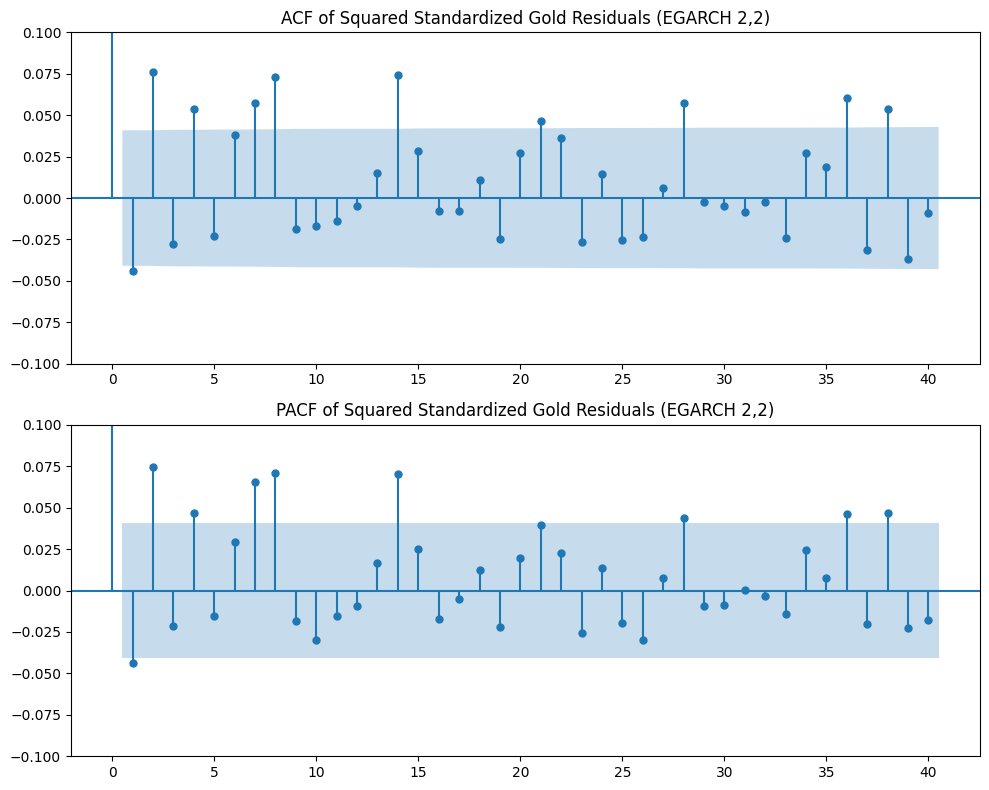

In [38]:
# Get the standardized residuals
btc_std_resid = res_garch_btc.std_resid
gold_std_resid = res_garch_gold.std_resid

# Square the standardized residuals
btc_std_resid_sq = btc_std_resid**2
gold_std_resid_sq = gold_std_resid**2

# Plot ACF and PACF for squared standardized Bitcoin residuals
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(btc_std_resid_sq.dropna(), ax=axes[0], lags=40)
plot_pacf(btc_std_resid_sq.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Bitcoin Residuals')
axes[1].set_title('PACF of Squared Standardized Bitcoin Residuals')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Plot ACF and PACF for squared standardized Gold residuals (GARCH)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_sq.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (GARCH)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (GARCH)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Get standardized residuals for EGARCH
gold_std_resid_egarch11 = res11_egarch_gold.std_resid


# Square the standardized residuals for EGARCH
gold_std_resid_sq_egarch11 = gold_std_resid_egarch11**2


# Plot ACF and PACF for squared standardized Gold residuals (EGARCH)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_sq_egarch11.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq_egarch11.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (EGARCH 1,1)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (EGARCH 1,1)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Get standardized residuals for EGARCH(2,2)
gold_std_resid_egarch22 = res_egarch22_gold.std_resid

# Square the standardized residuals
gold_std_resid_sq_egarch22 = gold_std_resid_egarch22**2

# Plot ACF and PACF for squared standardized Gold residuals (EGARCH 2,2)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(gold_std_resid_sq_egarch22.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq_egarch22.dropna(), ax=axes[1], lags=40)

axes[0].set_title('ACF of Squared Standardized Gold Residuals (EGARCH 2,2)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (EGARCH 2,2)')

# Same y-limits as your other plots
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])

plt.tight_layout()
plt.show()

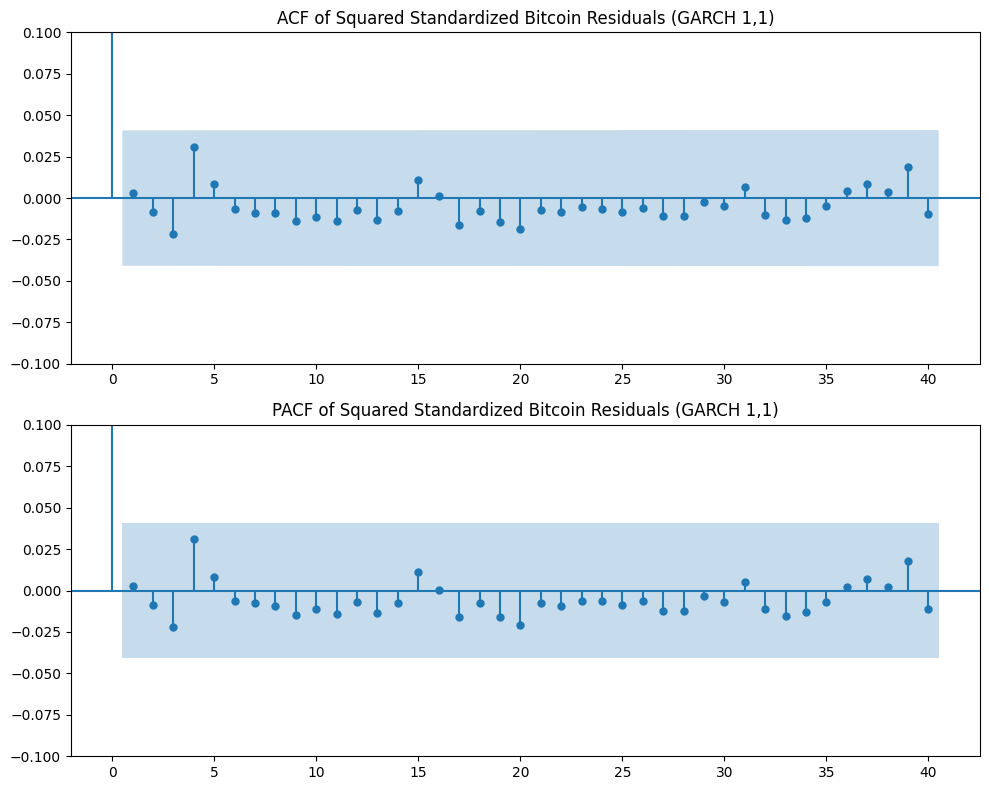

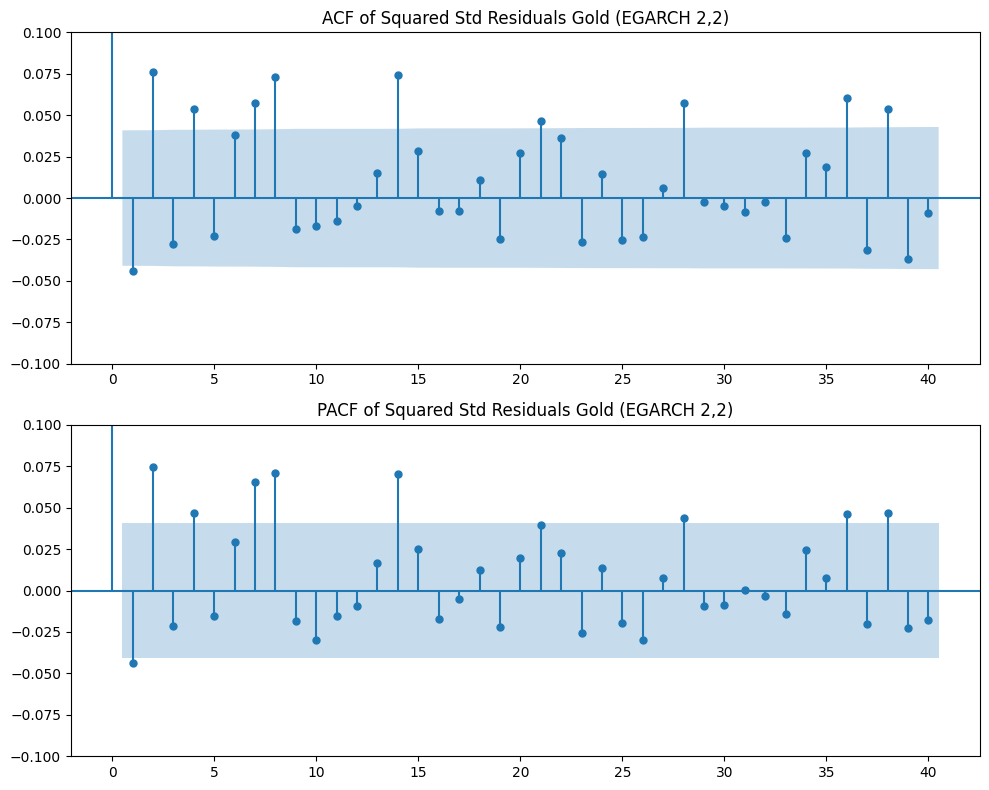

In [66]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==========================================
# 1. BITCOIN DIAGNOSTICS (Model: GARCH 1,1)
# ==========================================

# Get standardized residuals from your GARCH(1,1)
btc_std_resid = res_garch_btc.std_resid

# Square them (to check for remaining volatility clustering)
btc_std_resid_sq = btc_std_resid**2

# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(btc_std_resid_sq.dropna(), ax=axes[0], lags=40)
plot_pacf(btc_std_resid_sq.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Bitcoin Residuals (GARCH 1,1)')
axes[1].set_title('PACF of Squared Standardized Bitcoin Residuals (GARCH 1,1)')
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])
plt.tight_layout()
plt.show()


# ==========================================
# 2. GOLD DIAGNOSTICS (Model: EGARCH 2,2)
# ==========================================
# We use 'res_egarch22_gold' because that was your AIC winner!

# Get standardized residuals
gold_std_resid = res_egarch22_gold.std_resid

# Square them
gold_std_resid_sq = gold_std_resid**2

# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_sq.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Std Residuals Gold (EGARCH 2,2)')
axes[1].set_title('PACF of Squared Std Residuals Gold (EGARCH 2,2)')
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])
plt.tight_layout()
plt.show()

## Plot the ACF of the Standardized Residuals (Is the Autocorrelation Gone?) (The ARIMA Check)


*   Plot the ACF of the Standardized Residuals
*   Success Condition: No significant spikes.
*   If you see spikes: Your ARIMA model missed some information (maybe you need to increase $p$ or $q$).





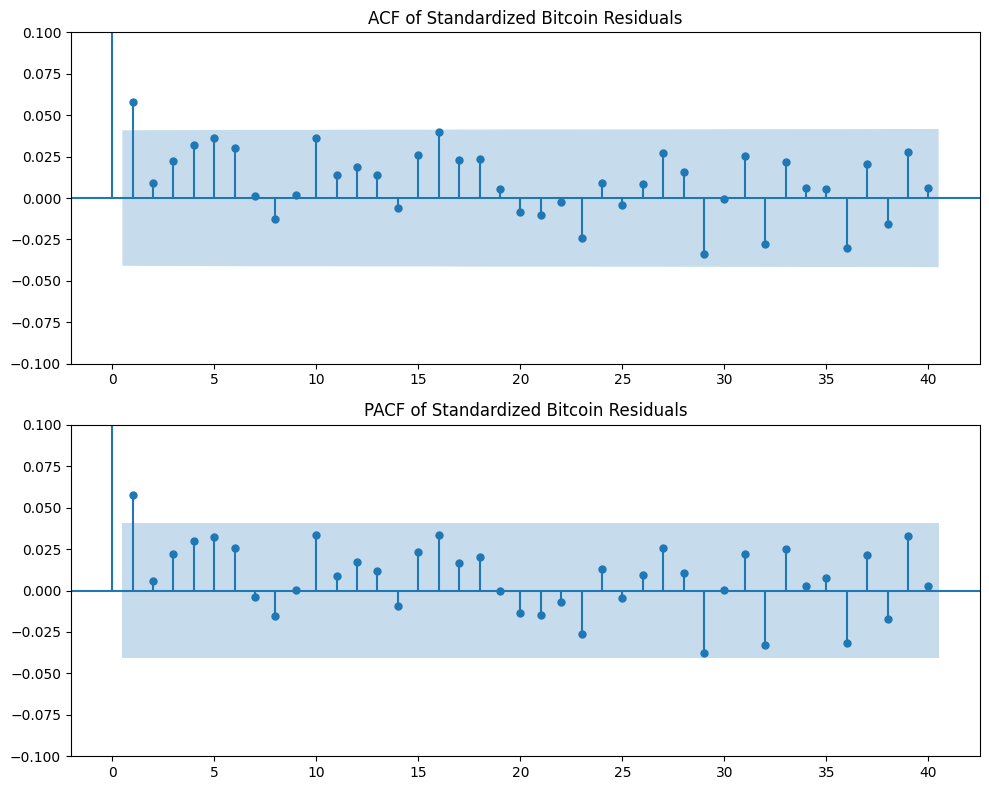

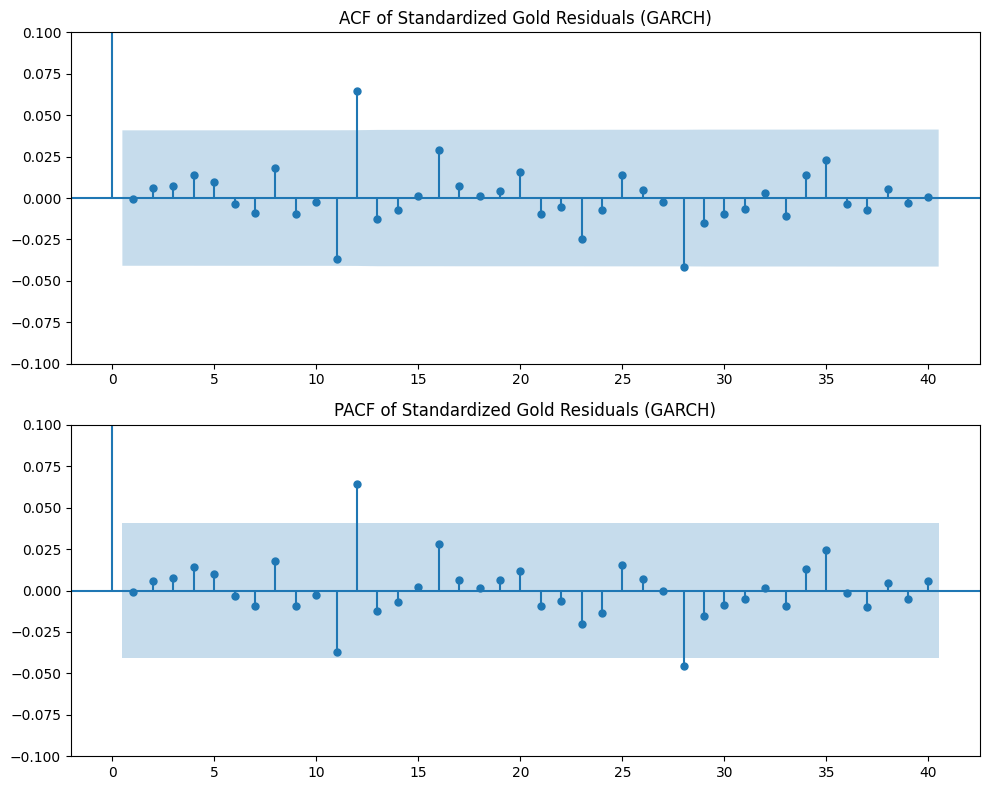

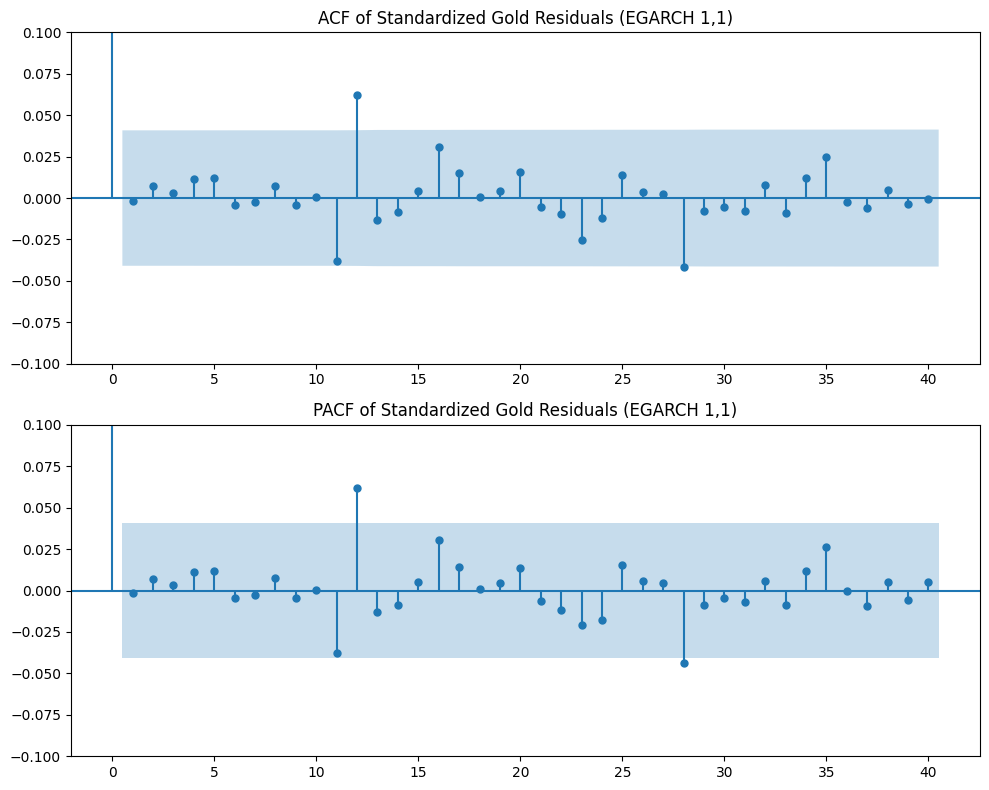

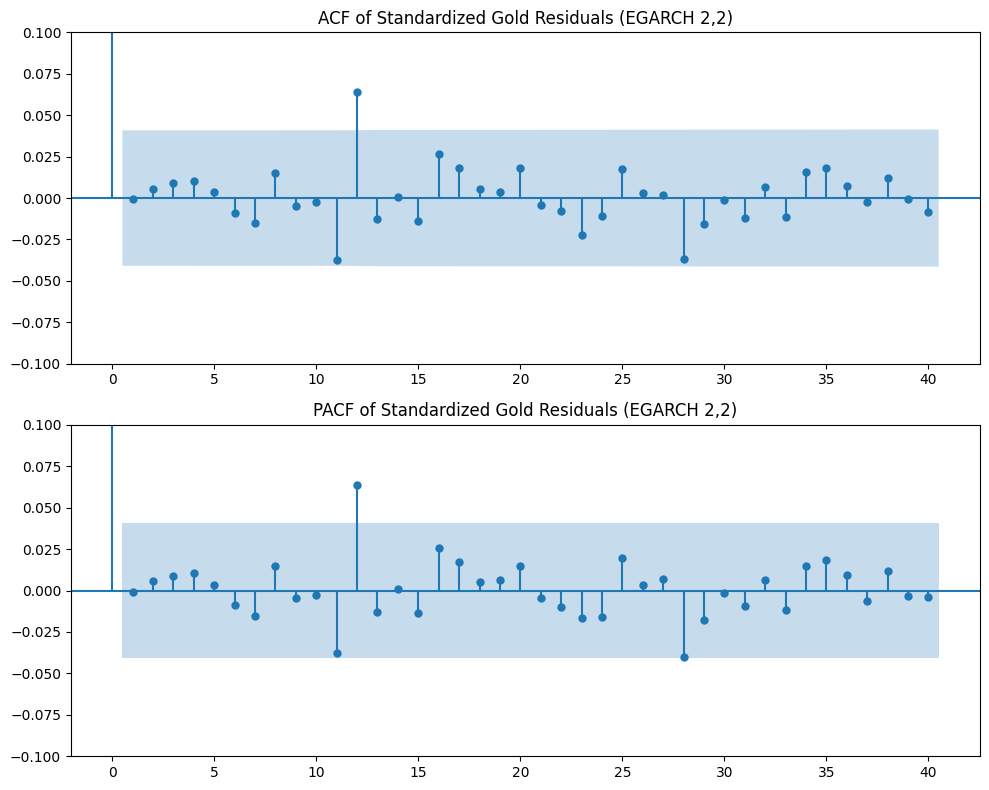

In [67]:
# Get the standardized residuals
btc_std_resid = res_garch_btc.std_resid
gold_std_resid = res_garch_gold.std_resid

# Plot ACF and PACF for standardized Bitcoin residuals
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(btc_std_resid.dropna(), ax=axes[0], lags=40)
plot_pacf(btc_std_resid.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Standardized Bitcoin Residuals')
axes[1].set_title('PACF of Standardized Bitcoin Residuals')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Plot ACF and PACF for standardized Gold residuals (GARCH)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Standardized Gold Residuals (GARCH)')
axes[1].set_title('PACF of Standardized Gold Residuals (GARCH)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Get standardized residuals for EGARCH
gold_std_resid_egarch11 = res11_egarch_gold.std_resid


# Plot ACF and PACF for standardized Gold residuals (EGARCH)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_egarch11.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_egarch11.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Standardized Gold Residuals (EGARCH 1,1)')
axes[1].set_title('PACF of Standardized Gold Residuals (EGARCH 1,1)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Get standardized residuals for EGARCH(2,2)
gold_std_resid_egarch22 = res_egarch22_gold.std_resid

# Plot ACF and PACF for standardized Gold residuals (EGARCH 2,2)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(gold_std_resid_egarch22.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_egarch22.dropna(), ax=axes[1], lags=40)

axes[0].set_title('ACF of Standardized Gold Residuals (EGARCH 2,2)')
axes[1].set_title('PACF of Standardized Gold Residuals (EGARCH 2,2)')

# Same y-limits as your other plots
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])

plt.tight_layout()
plt.show()

## Is the Distribution Correct? (The "Student's t" Check)

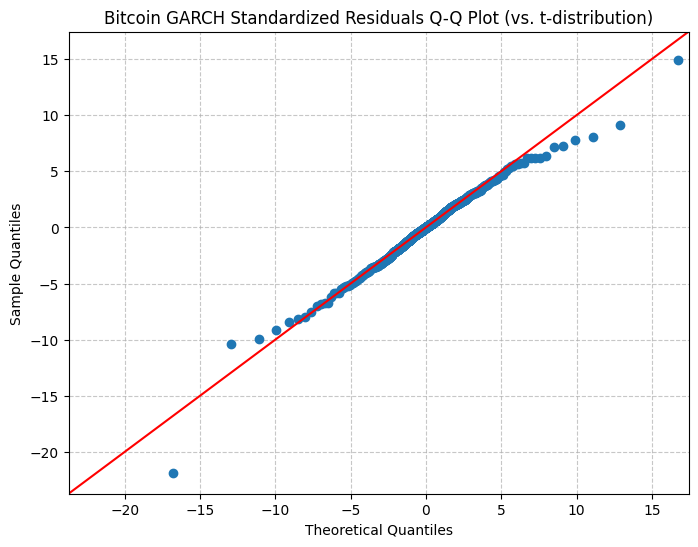

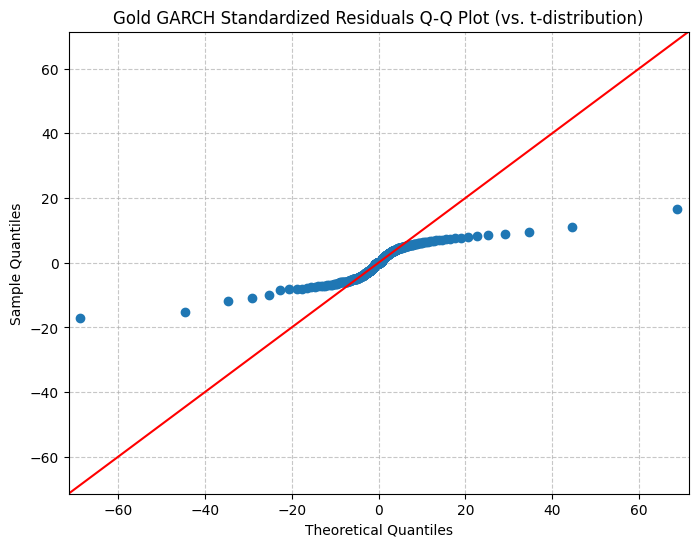

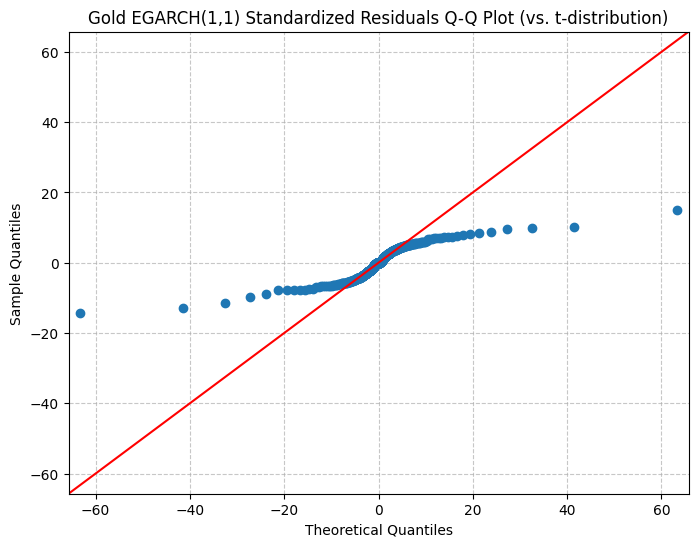

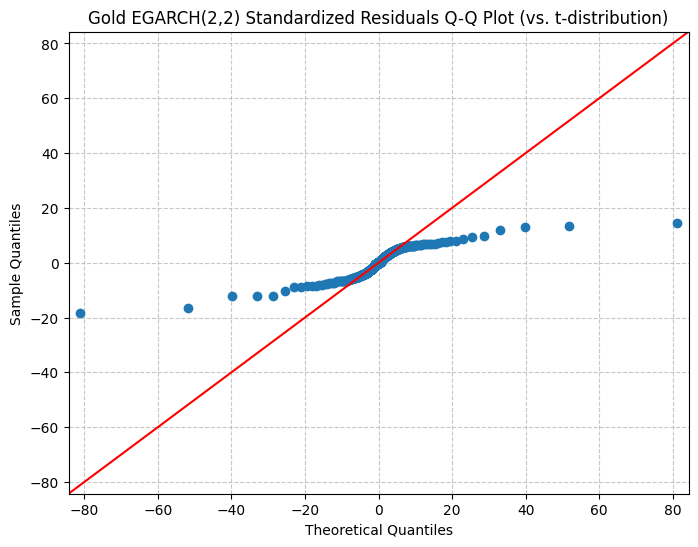

In [68]:
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import t

# --- Bitcoin GARCH Residuals Q-Q Plot ---
btc_std_resid = res_garch_btc.std_resid.dropna() # Get standardized residuals from GARCH model

plt.figure(figsize=(8, 6))
# 'dist="t"' specifies comparison against a Student's t-distribution
# 'fit=True' estimates the parameters (mean, std, df) of the t-distribution from the data
qqplot(btc_std_resid, dist=t, line='45', fit=True, ax=plt.gca())
plt.title('Bitcoin GARCH Standardized Residuals Q-Q Plot (vs. t-distribution)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Gold GARCH Residuals Q-Q Plot ---
gold_std_resid = res_garch_gold.std_resid.dropna() # Get standardized residuals from GARCH model

plt.figure(figsize=(8, 6))
qqplot(gold_std_resid, dist=t, line='45', fit=True, ax=plt.gca())
plt.title('Gold GARCH Standardized Residuals Q-Q Plot (vs. t-distribution)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Gold EGARCH(1,1) Residuals Q-Q Plot (for comparison) ---
gold_std_resid_egarch11 = res11_egarch_gold.std_resid.dropna()

plt.figure(figsize=(8, 6))
qqplot(gold_std_resid_egarch11, dist=t, line='45', fit=True, ax=plt.gca())
plt.title('Gold EGARCH(1,1) Standardized Residuals Q-Q Plot (vs. t-distribution)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Gold EGARCH(2,2) Residuals Q-Q Plot (for comparison) ---
gold_std_resid_egarch22 = res_egarch22_gold.std_resid.dropna()

plt.figure(figsize=(8, 6))
qqplot(gold_std_resid_egarch22, dist=t, line='45', fit=True, ax=plt.gca())
plt.title('Gold EGARCH(2,2) Standardized Residuals Q-Q Plot (vs. t-distribution)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Forecast ARIMA-GARCH/ARIMA-EGARCH

Training data size: 2300
Testing data size: 987
Forecasting over TEST period starting after: 2022-04-19
Bitcoin start price (end of train): 176317.19
Gold start price (end of train):    8292.7
           Date  BTC_Actual   BTC_Forecast  Gold_Actual  Gold_Forecast
2301 2022-04-20   176475.89  176689.048020      8374.39    8297.539099
2302 2022-04-21   173546.33  177118.892428      8367.38    8300.247445
2303 2022-04-22   171046.52  177466.391824      8347.69    8298.052376
2304 2022-04-23   169793.04  177820.449209      8347.69    8304.408548
2305 2022-04-24   169991.18  178172.373171      8347.69    8304.019610
2306 2022-04-25   175756.38  178525.313854      8262.26    8304.869113
2307 2022-04-26   165715.32  178878.851005      8293.37    8310.308078
2308 2022-04-27   170962.13  179233.103146      8217.71    8308.623005
2309 2022-04-28   173360.90  179588.052973      8257.81    8312.257241
2310 2022-04-29   168174.58  179943.706382      8253.29    8315.399878
2311 2022-04-30   164116.3

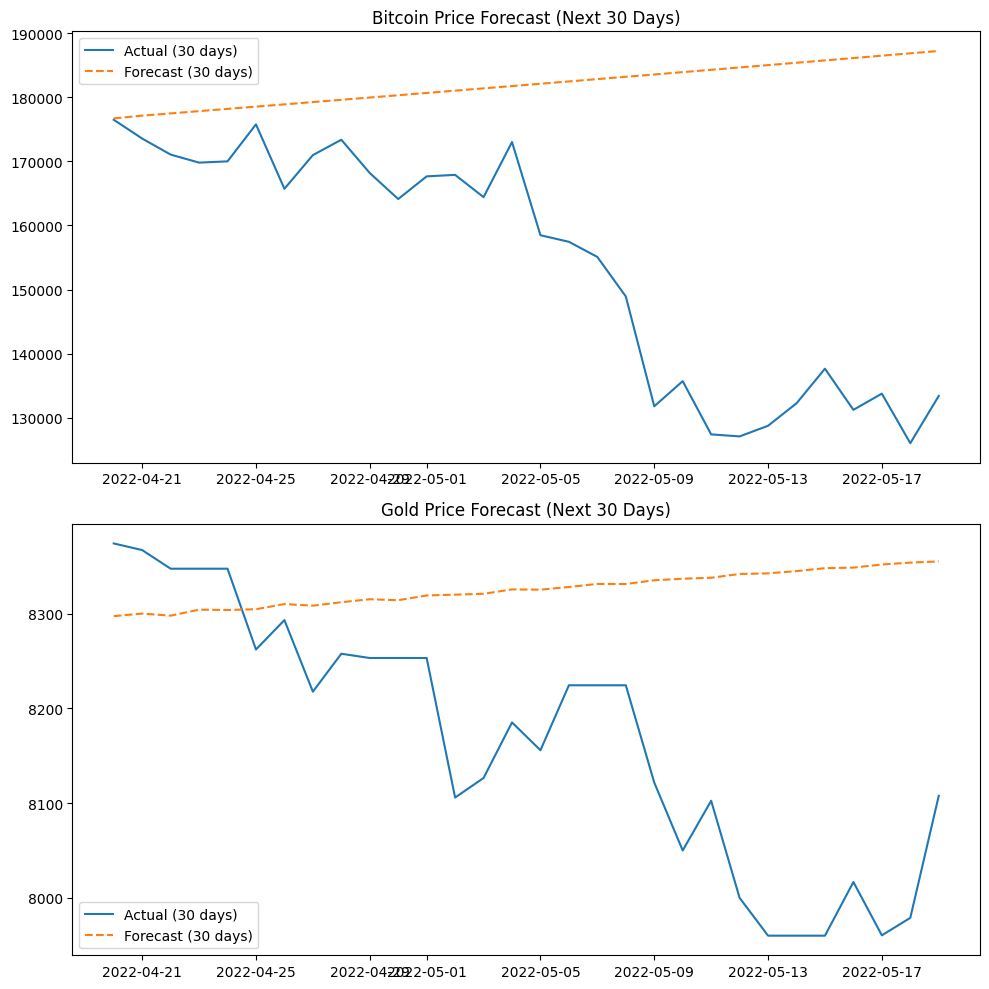

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

# ======================================================
# 0. TRAIN–TEST SPLIT (70:30)  - similar to your screenshot
# ======================================================
train_size = int(len(merged) * 0.7)

train_data = merged[['Date', 'Bitcoin_logret', 'Gold_logret', 'Bitcoin', 'Gold']].iloc[:train_size]
test_data  = merged[['Date', 'Bitcoin_logret', 'Gold_logret', 'Bitcoin', 'Gold']].iloc[train_size:]

print("Training data size:", len(train_data))
print("Testing data size:", len(test_data))

# ======================================================
# 1. SETUP: USE TRAINING DATA ONLY FOR MODEL FIT
# ======================================================
btc_train_scaled  = train_data['Bitcoin_logret']*100
gold_train_scaled = train_data['Gold_logret'] *100

# Last price in TRAINING set = starting point for forecast
last_train_btc_price  = train_data['Bitcoin'].iloc[-1]
last_train_gold_price = train_data['Gold'].iloc[-1]
last_train_date       = pd.to_datetime(train_data['Date'].iloc[-1])

print(f"Forecasting over TEST period starting after: {last_train_date.date()}")
print(f"Bitcoin start price (end of train): {last_train_btc_price}")
print(f"Gold start price (end of train):    {last_train_gold_price}")

# ======================================================
# 2. FIT MODELS ON TRAINING DATA ONLY
# ======================================================

# --- Bitcoin (ARIMA 2,0,0 + GARCH 1,1) ---
model_btc_arima = ARIMA(btc_train_scaled, order=(2, 0, 0), trend='c').fit()
model_btc_garch = arch_model(
    btc_train_scaled,
    mean='Zero',
    vol='Garch',
    p=1,
    q=1,
    dist='t'
).fit(disp='off')

# --- Gold (ARIMA 3,0,3  + EGARCH 2,2) ---
model_gold_arima = ARIMA(gold_train_scaled, order=(3, 0, 3), trend='c').fit()
model_gold_egarch = arch_model(
    gold_train_scaled,
    mean='Zero',
    vol='EGARCH',
    p=2,
    q=2,
    dist='t'
).fit(disp='off')

# ======================================================
# 3. FORECAST ONLY 30 DAYS INTO TEST PERIOD
# ======================================================
horizon = 30  # forecast 30 days only

# --- A. Mean Forecast (ARIMA) ---
btc_mean_scaled  = model_btc_arima.forecast(steps=horizon)
gold_mean_scaled = model_gold_arima.forecast(steps=horizon)

# Back to decimal returns
btc_return_pred  = btc_mean_scaled / 100
gold_return_pred = gold_mean_scaled / 100

# --- B. Convert to PRICE ---
btc_price_forecast = []
current_price = last_train_btc_price
for r in btc_return_pred:
    current_price = current_price * np.exp(r)
    btc_price_forecast.append(current_price)

gold_price_forecast = []
current_price = last_train_gold_price
for r in gold_return_pred:
    current_price = current_price * np.exp(r)
    gold_price_forecast.append(current_price)

# ======================================================
# Compare with ACTUAL 30 days ahead
# ======================================================
test_30 = test_data.iloc[:30]  # take first 30 test days
test_dates_30 = pd.to_datetime(test_30['Date'])

btc_actual_30 = test_30['Bitcoin'].values
gold_actual_30 = test_30['Gold'].values

# Create comparison table
forecast_df_30 = pd.DataFrame({
    'Date': test_dates_30,
    'BTC_Actual': btc_actual_30,
    'BTC_Forecast': btc_price_forecast,
    'Gold_Actual': gold_actual_30,
    'Gold_Forecast': gold_price_forecast
})

print(forecast_df_30)

# Plot (30-day only)

fig, ax = plt.subplots(2, 1, figsize=(10, 10))

# Bitcoin
ax[0].plot(test_dates_30, btc_actual_30, label='Actual (30 days)')
ax[0].plot(test_dates_30, btc_price_forecast, '--', label='Forecast (30 days)')
ax[0].set_title('Bitcoin Price Forecast (Next 30 Days)')
ax[0].legend()

# Gold
ax[1].plot(test_dates_30, gold_actual_30, label='Actual (30 days)')
ax[1].plot(test_dates_30, gold_price_forecast, '--', label='Forecast (30 days)')
ax[1].set_title('Gold Price Forecast (Next 30 Days)')
ax[1].legend()

plt.tight_layout()
plt.show()




In [70]:
# RMSE / MAE (for 30-day only)

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_btc_30 = np.sqrt(mean_squared_error(btc_actual_30, btc_price_forecast))
mae_btc_30  = mean_absolute_error(btc_actual_30, btc_price_forecast)

rmse_gold_30 = np.sqrt(mean_squared_error(gold_actual_30, gold_price_forecast))
mae_gold_30  = mean_absolute_error(gold_actual_30, gold_price_forecast)

print("BTC 30-day RMSE:", rmse_btc_30, " MAE:", mae_btc_30)
print("Gold 30-day RMSE:", rmse_gold_30, " MAE:", mae_gold_30)

BTC 30-day RMSE: 35076.21126519594  MAE: 28035.082769965713
Gold 30-day RMSE: 217.7028895134366  MAE: 176.53782484687096


## ARIMA-GARCH 30-Day Future Forecast (Task 2)

Forecasting 30 days starting after: 2024-12-31
Bitcoin last actual price: 418200.68
Gold last actual price:    11723.19

--- 30-Day Future Forecast (ARIMA-GARCH) ---
         Date  BTC_Forecast_ARIMAGARCH  Gold_Forecast_ARIMAEGARCH
0  2025-01-01            418547.396758               11724.292746
1  2025-01-02            419360.906036               11730.987913
2  2025-01-03            420033.663130               11736.459298
3  2025-01-04            420731.442266               11737.984364
4  2025-01-05            421423.971982               11745.366629
5  2025-01-06            422118.828974               11748.276951
6  2025-01-07            422814.538073               11751.391007
7  2025-01-08            423511.451566               11757.993360
8  2025-01-09            424209.500157               11759.569127
9  2025-01-10            424908.702079               11764.321866
10 2025-01-11            425609.055824               11769.257150
11 2025-01-12            426310.564056    

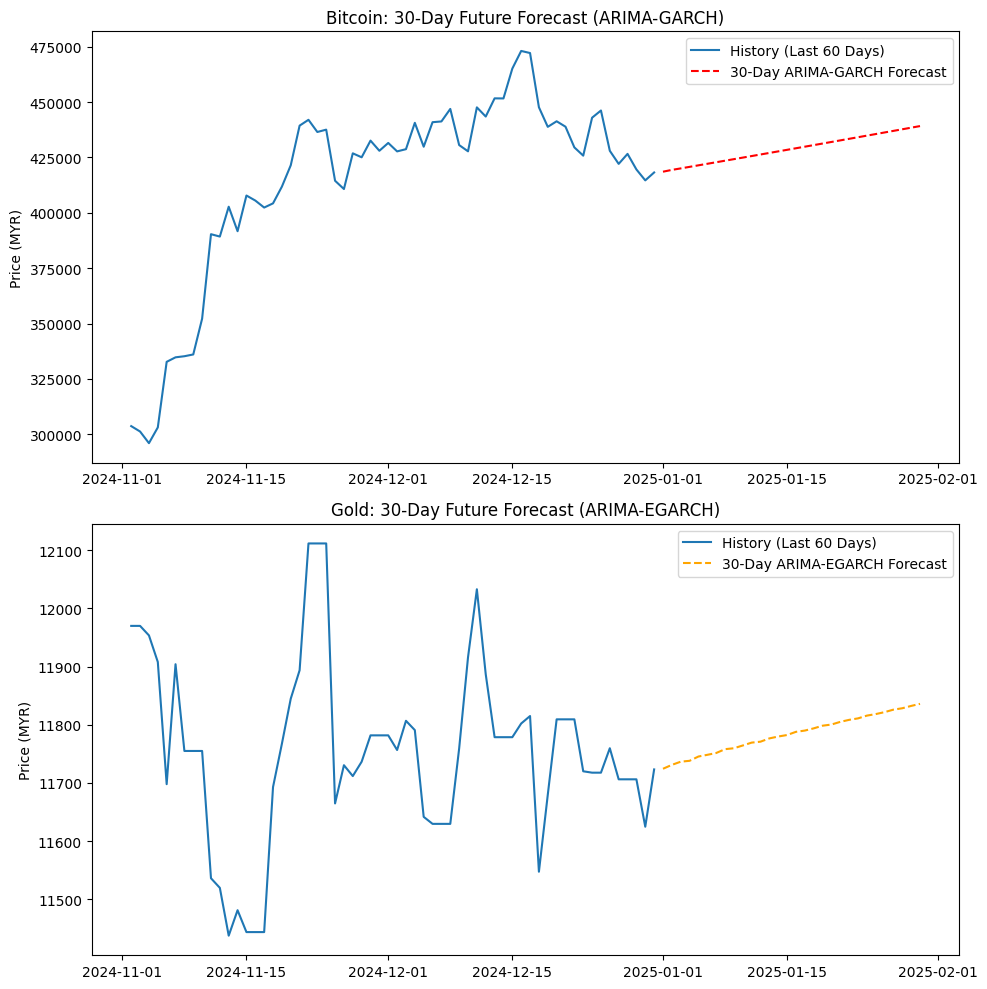

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

# ======================================================
# 1. USE FULL DATA (NO TRAIN/TEST SPLIT) FOR FUTURE FORECAST
# ======================================================
btc_full_scaled  = merged['Bitcoin_logret'] * 100
gold_full_scaled = merged['Gold_logret'] * 100

# Last actual prices and date
last_real_btc_price  = merged['Bitcoin'].iloc[-1]
last_real_gold_price = merged['Gold'].iloc[-1]
last_date            = pd.to_datetime(merged['Date'].iloc[-1])

print(f"Forecasting 30 days starting after: {last_date.date()}")
print(f"Bitcoin last actual price: {last_real_btc_price}")
print(f"Gold last actual price:    {last_real_gold_price}")

# ======================================================
# 2. FIT ARIMA + (E)GARCH ON FULL SERIES
#    (use the orders you already selected)
# ======================================================

# --- Bitcoin (ARIMA 2,0,0 + GARCH 1,1) ---
model_btc_arima = ARIMA(btc_full_scaled, order=(2, 0, 0), trend='c').fit()
model_btc_garch = arch_model(
    btc_full_scaled,
    mean='Zero',
    vol='Garch',
    p=1,
    q=1,
    dist='t'
).fit(disp='off')

# --- Gold (ARIMA 3,0,3 + EGARCH 2,2) ---
model_gold_arima = ARIMA(gold_full_scaled, order=(3, 0, 3), trend='c').fit()
model_gold_egarch = arch_model(
    gold_full_scaled,
    mean='Zero',
    vol='EGARCH',
    p=2,
    q=2,
    dist='t'
).fit(disp='off')

# ======================================================
# 3. 30-DAY AHEAD MEAN FORECAST (LOG RETURNS)
# ======================================================
horizon = 30

btc_mean_scaled  = model_btc_arima.forecast(steps=horizon)
gold_mean_scaled = model_gold_arima.forecast(steps=horizon)

btc_return_pred  = btc_mean_scaled / 100
gold_return_pred = gold_mean_scaled / 100

# (Optional) volatility forecast
btc_risk_forecast  = model_btc_garch.forecast(horizon=horizon)
btc_sigma_future   = np.sqrt(btc_risk_forecast.variance.values[-1, :]) / 100

gold_risk_forecast = model_gold_egarch.forecast(
    horizon=horizon,
    method='simulation',
    simulations=1000
)
gold_sigma_future  = np.sqrt(gold_risk_forecast.variance.values[-1, :]) / 100

# ======================================================
# 4. CONVERT FORECAST RETURNS TO PRICE PATH (MYR)
# ======================================================
btc_price_forecast = []
cur_btc = last_real_btc_price
for r in btc_return_pred:
    cur_btc = cur_btc * np.exp(r)
    btc_price_forecast.append(cur_btc)

gold_price_forecast = []
cur_gold = last_real_gold_price
for r in gold_return_pred:
    cur_gold = cur_gold * np.exp(r)
    gold_price_forecast.append(cur_gold)

future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                             periods=horizon, freq='D')

arima_garch_future_df = pd.DataFrame({
    'Date': future_dates,
    'BTC_Forecast_ARIMAGARCH': btc_price_forecast,
    'Gold_Forecast_ARIMAEGARCH': gold_price_forecast
})

print("\n--- 30-Day Future Forecast (ARIMA-GARCH) ---")
print(arima_garch_future_df)

# ======================================================
# 5. PLOT LAST 60 DAYS + 30-DAY FUTURE FORECAST
# ======================================================
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

# Bitcoin
ax[0].plot(merged['Date'].iloc[-60:], merged['Bitcoin'].iloc[-60:],
           label='History (Last 60 Days)')
ax[0].plot(future_dates, btc_price_forecast,
           '--', color='red', label='30-Day ARIMA-GARCH Forecast')
ax[0].set_title('Bitcoin: 30-Day Future Forecast (ARIMA-GARCH)')
ax[0].set_ylabel('Price (MYR)')
ax[0].legend()

# Gold
ax[1].plot(merged['Date'].iloc[-60:], merged['Gold'].iloc[-60:],
           label='History (Last 60 Days)')
ax[1].plot(future_dates, gold_price_forecast,
           '--', color='orange', label='30-Day ARIMA-EGARCH Forecast')
ax[1].set_title('Gold: 30-Day Future Forecast (ARIMA-EGARCH)')
ax[1].set_ylabel('Price (MYR)')
ax[1].legend()

plt.tight_layout()
plt.show()


# Multivariate LSTM


--- Data Shapes (Multivariate 70:30 Split) ---
X_train: (2280, 30, 2)
X_test:  (978, 30, 2)

--- Starting Multivariate Model Training ---
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0073 - val_loss: 0.0010
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 6.8010e-04 - val_loss: 0.0011
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 5.6625e-04 - val_loss: 9.2455e-04
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 5.5707e-04 - val_loss: 8.9368e-04
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 4.9586e-04 - val_loss: 9.8645e-04
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 4.7005e-04 - val_loss: 0.0011
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 5.4756e-04 - val_loss: 0.0013
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 4.3689e-04 - val_loss: 0.0014
Epoch 9/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 4.7048e-04 - val_loss: 0.0014
--- Model Training Complete ---


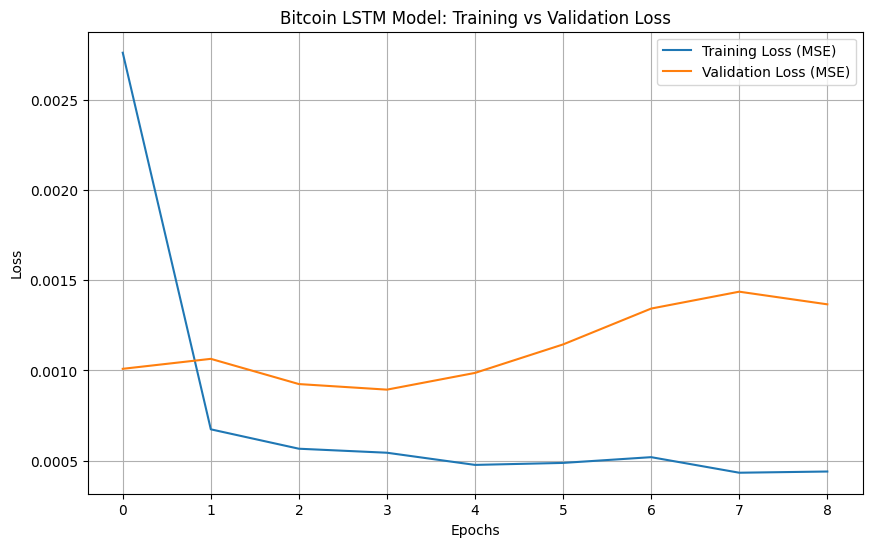


=== Ringkasan Metrik (Multivariate Train/Test) ===


,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,6108.19,7.313350e+07,8551.81,36.87
1,Test,10291.28,1.986892e+08,14095.72,6.38


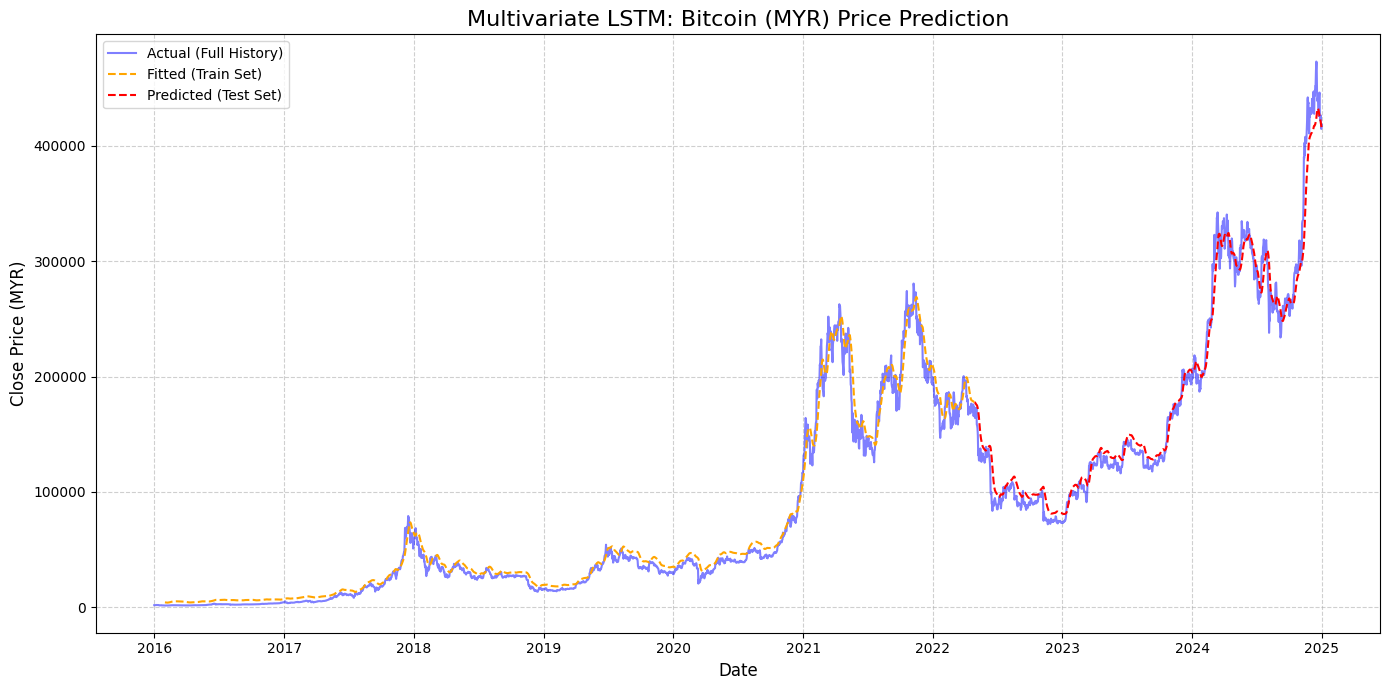

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. SET UP FOR MULTIVARIATE LSTM ---
df = merged.copy()
feature_cols = ['Bitcoin', 'Gold']
target_col = 'Bitcoin'
date_col = 'Date'
window_size = 30

# --- 2. SCALING ---
data_to_use = df[feature_cols].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_to_use)

# --- 3. CREATE SEQUENCES (Multivariate) ---
def make_sequences_multi(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :]) # All features for the window
        y.append(data[i, 0])               # Only the 1st col (Bitcoin) as target
    return np.array(X), np.array(y)

X, y = make_sequences_multi(scaled_data, window_size)

# --- 4. TRAIN / TEST SPLIT (70% Train, 30% Test) ---
train_split_idx = int(len(X) * 0.70)
X_tr, y_tr = X[:train_split_idx], y[:train_split_idx]
X_test, y_test = X[train_split_idx:], y[train_split_idx:]

# --- 5. RESHAPE FOR LSTM [samples, timesteps, features] ---
n_features = len(feature_cols)
# X_tr and X_test are already (samples, 30, 2)
print("\n--- Data Shapes (Multivariate 70:30 Split) ---")
print(f"X_train: {X_tr.shape}")
print(f"X_test:  {X_test.shape}")

# --- 7. BUILD & TRAIN MODEL ---
tf.random.set_seed(42)
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, n_features)),
    Dropout(0.1),
    LSTM(32),
    Dropout(0.1),
    Dense(1) # Still 1 output (predicting Bitcoin)
])
model.compile(optimizer="adam", loss="mse")
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("\n--- Starting Multivariate Model Training ---")
history = model.fit(
    X_tr, y_tr,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[es],
    verbose=1
)
print("--- Model Training Complete ---")

# --- ADD THIS TO VISUALIZE OVERFITTING ---
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Bitcoin LSTM Model: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- 8. EVALUATION & METRICS (Multivariate) ---
def inverse_and_metrics_multi(y_true_scaled, y_pred_scaled, scaler_obj):
    n_features = scaler_obj.n_features_in_

    pred_combined = np.zeros((len(y_pred_scaled), n_features))
    pred_combined[:, 0] = y_pred_scaled.flatten()
    y_pred = scaler_obj.inverse_transform(pred_combined)[:, 0]

    true_combined = np.zeros((len(y_true_scaled), n_features))
    true_combined[:, 0] = y_true_scaled.flatten()
    y_true = scaler_obj.inverse_transform(true_combined)[:, 0]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

y_pred_tr_skala = model.predict(X_tr, verbose=0).flatten()
y_pred_test_skala = model.predict(X_test, verbose=0).flatten()

y_true_tr, y_pred_tr, mae_tr, mse_tr, rmse_tr, mape_tr = inverse_and_metrics_multi(y_tr, y_pred_tr_skala, scaler)
y_true_test, y_pred_test, mae_te, mse_te, rmse_te, mape_te = inverse_and_metrics_multi(y_test, y_pred_test_skala, scaler)

metrics_df = pd.DataFrame({
    "Set": ["Train", "Test"],
    "MAE": [mae_tr, mae_te],
    "MSE": [mse_tr, mse_te],
    "RMSE": [rmse_tr, rmse_te],
    "MAPE(%)": [mape_tr, mape_te]
})

print("\n=== Ringkasan Metrik (Multivariate Train/Test) ===")
display(metrics_df.round(2))

# --- 9. PLOTTING (Full History Plot) ---
date_index = df[date_col].iloc[window_size:]
train_dates = date_index.iloc[:train_split_idx]
test_dates = date_index.iloc[train_split_idx:]

plt.figure(figsize=(14, 7))
plt.plot(df[date_col], df[target_col], label="Actual (Full History)", color='blue', alpha=0.5)
plt.plot(train_dates, y_pred_tr, label="Fitted (Train Set)", color='orange', linestyle='--')
plt.plot(test_dates, y_pred_test, label="Predicted (Test Set)", color='red', linestyle='--')
plt.title(f"Multivariate LSTM: Bitcoin (MYR) Price Prediction", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Close Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Forecast Bitcoin MV LSTM



Generating 30-Day LSTM Forecast on TEST Set...

--- 30-Day LSTM Forecast on TEST Set ---
         Date  BTC_Actual  BTC_LSTM_Forecast
0  2022-04-29   168174.58      174731.803179
1  2022-04-30   164116.35      174488.235686
2  2022-05-01   167651.50      173777.122031
3  2022-05-02   167882.53      173157.741405
4  2022-05-03   164412.76      172657.565940
5  2022-05-04   172999.99      171968.177049
6  2022-05-05   158473.06      171954.363697
7  2022-05-06   157449.35      171109.978588
8  2022-05-07   155083.83      169784.444748
9  2022-05-08   148927.35      168098.217987
10 2022-05-09   131801.05      165822.176515
11 2022-05-10   135719.83      161971.342553
12 2022-05-11   127420.45      157857.492797
13 2022-05-12   127103.22      153213.367674
14 2022-05-13   128763.51      148629.062942
15 2022-05-14   132263.52      144580.499897
16 2022-05-15   137664.35      141460.494884
17 2022-05-16   131246.05      139594.596169
18 2022-05-17   133772.81      138085.610323
19 2022-05

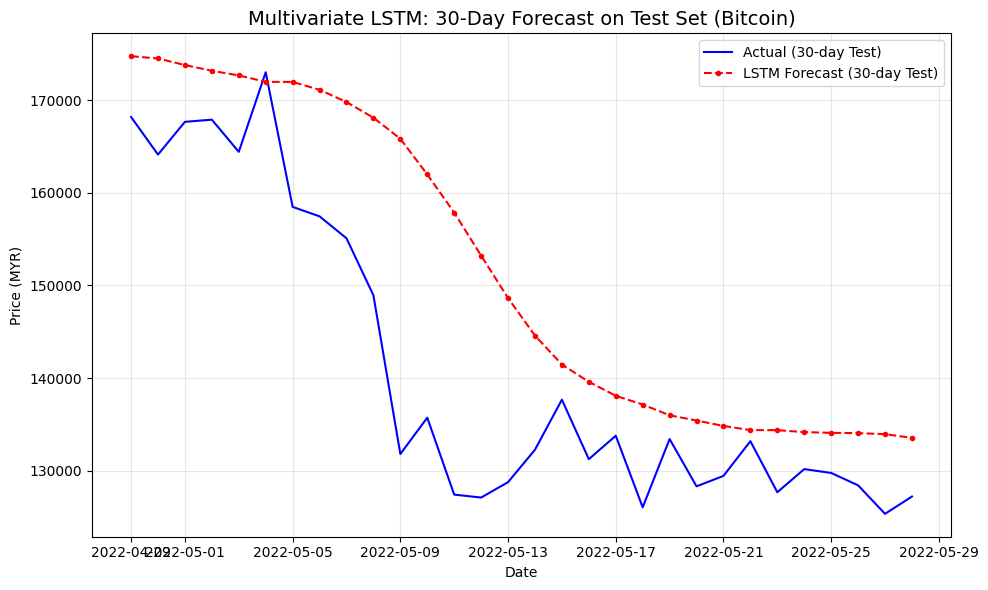

In [88]:
# ======================================================
#    STEP 10: 30-DAY TEST FORECAST (for fair comparison)
# ======================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

forecast_horizon = 30  # first 30 days of test set

# 1) Take the first 30 samples from X_test and y_test
X_test_30 = X_test[:forecast_horizon]
y_test_30 = y_test[:forecast_horizon]

print(f"\nGenerating {forecast_horizon}-Day LSTM Forecast on TEST Set...")

# 2) Predict (still in scaled space)
y_pred_30_scaled = model.predict(X_test_30, verbose=0).flatten()

# 3) Inverse-scale PREDICTIONS
dummy_pred = np.zeros((forecast_horizon, n_features))
dummy_pred[:, 0] = y_pred_30_scaled          # fill Bitcoin column
btc_pred_30 = scaler.inverse_transform(dummy_pred)[:, 0]

# 4) Inverse-scale TRUE values
dummy_true = np.zeros((forecast_horizon, n_features))
dummy_true[:, 0] = y_test_30.flatten()
btc_true_30 = scaler.inverse_transform(dummy_true)[:, 0]

# 5) Get corresponding TEST DATES (first 30 days of test set)
#    date_index starts after the initial window_size (same as in your plotting code)
date_index = df[date_col].iloc[window_size:]
test_dates = date_index.iloc[train_split_idx:]
test_dates_30 = test_dates[:forecast_horizon]

# 6) Put into DataFrame
lstm_test_forecast_df = pd.DataFrame({
    'Date': test_dates_30.values,
    'BTC_Actual': btc_true_30,
    'BTC_LSTM_Forecast': btc_pred_30
})

print("\n--- 30-Day LSTM Forecast on TEST Set ---")
print(lstm_test_forecast_df)

# 7) Metrics for 30-day horizon (same style as ARIMA-GARCH)
rmse_lstm_30 = np.sqrt(mean_squared_error(btc_true_30, btc_pred_30))
mae_lstm_30  = mean_absolute_error(btc_true_30, btc_pred_30)

print("\nLSTM 30-day RMSE:", rmse_lstm_30)
print("LSTM 30-day MAE :", mae_lstm_30)

# ======================================================
#    STEP 11: VISUALIZATION (30-day test forecast)
# ======================================================

plt.figure(figsize=(10, 6))
plt.plot(test_dates_30, btc_true_30, label="Actual (30-day Test)", color='blue')
plt.plot(test_dates_30, btc_pred_30, label="LSTM Forecast (30-day Test)",
         color='red', linestyle='--', marker='.')
plt.title("Multivariate LSTM: 30-Day Forecast on Test Set (Bitcoin)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (MYR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Multivariate LSTM 30-Day Future Forecast (Task 2)


Generating 30-Day Future Forecast (LSTM)...

--- 30-Day Future Forecast (Multivariate LSTM) ---
         Date  Bitcoin_LSTM_Forecast
0  2025-01-01          390421.504918
1  2025-01-02          386367.208558
2  2025-01-03          381469.271859
3  2025-01-04          376171.548904
4  2025-01-05          370719.026463
5  2025-01-06          365264.958275
6  2025-01-07          359889.891785
7  2025-01-08          354644.415062
8  2025-01-09          349549.887512
9  2025-01-10          344626.010376
10 2025-01-11          339886.273806
11 2025-01-12          335322.471293
12 2025-01-13          330938.003480
13 2025-01-14          326727.024633
14 2025-01-15          322689.197500
15 2025-01-16          318817.018184
16 2025-01-17          315101.718086
17 2025-01-18          311528.935817
18 2025-01-19          308100.807315
19 2025-01-20          304814.775075
20 2025-01-21          301661.845661
21 2025-01-22          298633.643938
22 2025-01-23          295726.263384
23 2025-01-24  

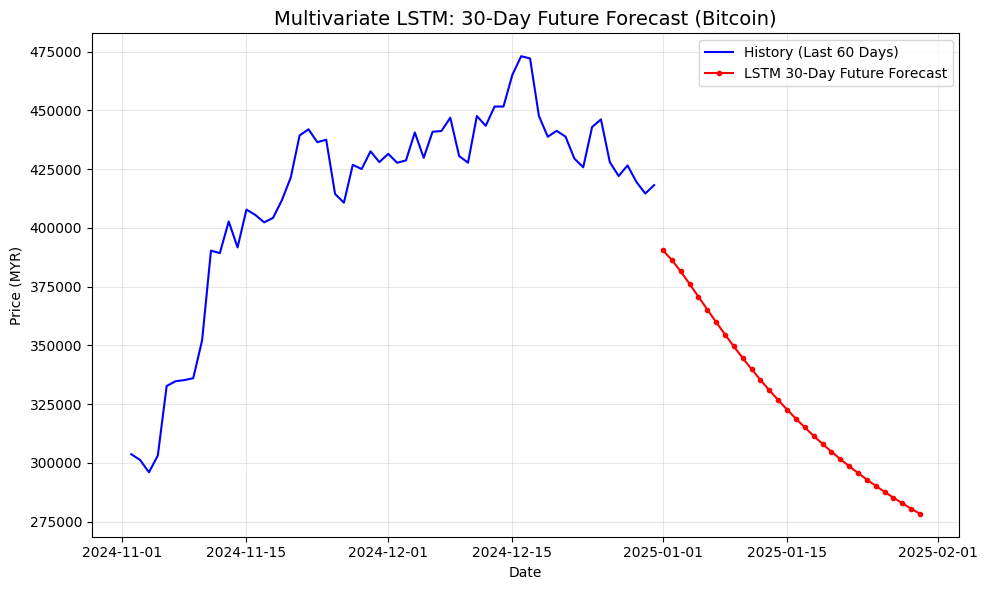

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================
# 1. PREP: GET SCALED FULL DATA AGAIN
#    (use same scaler and feature_cols as in training)
# ======================================================
data_full = df[feature_cols].values
scaled_full = scaler.transform(data_full)   # same scaler as before

# Last window_size days as starting sequence
last_sequence = scaled_full[-window_size:]   # shape: (30, 2)
current_seq   = last_sequence.copy()

forecast_horizon = 30
future_forecast_scaled = []

print(f"\nGenerating {forecast_horizon}-Day Future Forecast (LSTM)...")

# ======================================================
# 2. ITERATIVE 30-DAY FUTURE FORECAST
# ======================================================
for _ in range(forecast_horizon):
    # shape (1, 30, 2) for LSTM input
    input_seq = current_seq.reshape(1, window_size, n_features)

    # predict next Bitcoin (scaled)
    pred_scaled = model.predict(input_seq, verbose=0)[0, 0]
    future_forecast_scaled.append(pred_scaled)

    # assume Gold stays at last known scaled value (naive)
    last_known_gold_scaled = current_seq[-1, 1]
    new_step = np.array([[pred_scaled, last_known_gold_scaled]])

    # slide window forward
    current_seq = np.concatenate([current_seq[1:], new_step], axis=0)

# ======================================================
# 3. INVERSE SCALE FORECAST TO ACTUAL PRICE (MYR)
# ======================================================
dummy = np.zeros((forecast_horizon, n_features))
dummy[:, 0] = np.array(future_forecast_scaled)
btc_lstm_future = scaler.inverse_transform(dummy)[:, 0]

last_date = df[date_col].iloc[-1]
future_dates_lstm = pd.date_range(start=last_date + pd.Timedelta(days=1),
                                  periods=forecast_horizon)

lstm_future_df = pd.DataFrame({
    'Date': future_dates_lstm,
    'Bitcoin_LSTM_Forecast': btc_lstm_future
})

print("\n--- 30-Day Future Forecast (Multivariate LSTM) ---")
print(lstm_future_df)

# ======================================================
# 4. PLOT LAST 60 DAYS + LSTM 30-DAY FUTURE FORECAST
# ======================================================
plt.figure(figsize=(10, 6))

# history (last 60 days)
plt.plot(df[date_col].iloc[-60:], df['Bitcoin'].iloc[-60:],
         label='History (Last 60 Days)', color='blue')

# future forecast
plt.plot(lstm_future_df['Date'], lstm_future_df['Bitcoin_LSTM_Forecast'],
         label='LSTM 30-Day Future Forecast', color='red', marker='.')

plt.title("Multivariate LSTM: 30-Day Future Forecast (Bitcoin)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (MYR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## MV LSTM Gold

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- 3. SET UP FOR MULTIVARIATE LSTM (Predicting Gold) ---
df_gold_70 = merged.copy()
feature_cols_gold_70 = ['Bitcoin', 'Gold']  # Inputs
target_col_gold_70 = 'Gold'                 # Output
date_col_gold_70 = 'Date'
window_size_gold_70 = 30

# --- 4. SCALING ---
data_to_use_gold_70 = df_gold_70[feature_cols_gold_70].values
scaler_gold_70 = MinMaxScaler(feature_range=(0, 1))
scaled_data_gold_70 = scaler_gold_70.fit_transform(data_to_use_gold_70)

# --- 5. CREATE SEQUENCES (Multivariate for Gold) ---
def make_sequences_multi_gold_70(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])  # All features (BTC & Gold)
        y.append(data[i, 1])                # col 1 = Gold (target)
    return np.array(X), np.array(y)

X_gold_70, y_gold_70 = make_sequences_multi_gold_70(
    scaled_data_gold_70, window_size_gold_70
)

# --- 6. TRAIN / TEST SPLIT (70% Train, 30% Test) ---
train_split_idx_gold_70 = int(len(X_gold_70) * 0.70)
X_tr_gold_70, y_tr_gold_70 = X_gold_70[:train_split_idx_gold_70], y_gold_70[:train_split_idx_gold_70]
X_test_gold_70, y_test_gold_70 = X_gold_70[train_split_idx_gold_70:], y_gold_70[train_split_idx_gold_70:]

# --- 7. RESHAPE FOR LSTM [samples, timesteps, features] ---
n_features_gold_70 = len(feature_cols_gold_70)
print("\n--- Data Shapes (Multivariate Gold 70:30 Split) ---")
print(f"X_train: {X_tr_gold_70.shape}")
print(f"X_test:  {X_test_gold_70.shape}")

# --- 8. BUILD & TRAIN MODEL ---
tf.random.set_seed(42)
model_gold_70 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size_gold_70, n_features_gold_70)),
    Dropout(0.1),
    LSTM(32),
    Dropout(0.1),
    Dense(1)
])
model_gold_70.compile(optimizer="adam", loss="mse")
es_gold_70 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("\n--- Starting Multivariate Model Training (Predicting Gold) ---")
history_gold_70 = model_gold_70.fit(
    X_tr_gold_70, y_tr_gold_70,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_gold_70, y_test_gold_70),
    callbacks=[es_gold_70],
    verbose=1
)
print("--- Model Training Complete ---")

# --- 9. EVALUATION & METRICS (Full Train/Test) ---
def inverse_and_metrics_multi_gold_70(y_true_scaled, y_pred_scaled, scaler_obj_gold_70):
    n_features = scaler_obj_gold_70.n_features_in_

    # Put prediction in col 1 (Gold)
    pred_combined = np.zeros((len(y_pred_scaled), n_features))
    pred_combined[:, 1] = y_pred_scaled.flatten()
    y_pred = scaler_obj_gold_70.inverse_transform(pred_combined)[:, 1]

    # Put actual in col 1 (Gold)
    true_combined = np.zeros((len(y_true_scaled), n_features))
    true_combined[:, 1] = y_true_scaled.flatten()
    y_true = scaler_obj_gold_70.inverse_transform(true_combined)[:, 1]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

y_pred_tr_skala_gold_70 = model_gold_70.predict(X_tr_gold_70, verbose=0).flatten()
y_pred_test_skala_gold_70 = model_gold_70.predict(X_test_gold_70, verbose=0).flatten()

y_true_tr_gold_70, y_pred_tr_gold_70, mae_tr_gold_70, mse_tr_gold_70, rmse_tr_gold_70, mape_tr_gold_70 = \
    inverse_and_metrics_multi_gold_70(y_tr_gold_70, y_pred_tr_skala_gold_70, scaler_gold_70)

y_true_test_gold_70, y_pred_test_gold_70, mae_te_gold_70, mse_te_gold_70, rmse_te_gold_70, mape_te_gold_70 = \
    inverse_and_metrics_multi_gold_70(y_test_gold_70, y_pred_test_skala_gold_70, scaler_gold_70)

metrics_df_gold_70 = pd.DataFrame({
    "Set": ["Train", "Test"],
    "MAE": [mae_tr_gold_70, mae_te_gold_70],
    "MSE": [mse_tr_gold_70, mse_te_gold_70],
    "RMSE": [rmse_tr_gold_70, rmse_te_gold_70],
    "MAPE(%)": [mape_tr_gold_70, mape_te_gold_70]
})

print("\n=== Ringkasan Metrik (Multivariate Gold 70:30 Split) ===")
display(metrics_df_gold_70.round(2))


--- Data Shapes (Multivariate Gold 70:30 Split) ---
X_train: (2280, 30, 2)
X_test:  (978, 30, 2)

--- Starting Multivariate Model Training (Predicting Gold) ---
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 0.0137 - val_loss: 0.0035
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 7.2051e-04 - val_loss: 0.0018
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 5.8606e-04 - val_loss: 0.0025
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 6.6335e-04 - val_loss: 0.0025
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 5.1741e-04 - val_loss: 0.0030
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4.9987e-04 - val_loss: 0.0051
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 6.3289e-04 - val_loss: 0.0024
--- Model Training Complete ---

=== Ringkasan Metrik (Multivariate Gold 70:30 Split) ===


,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,83.35,13090.47,114.41,1.32
1,Test,233.48,105898.70,325.42,2.29


### forecast GOLD MV LSTM

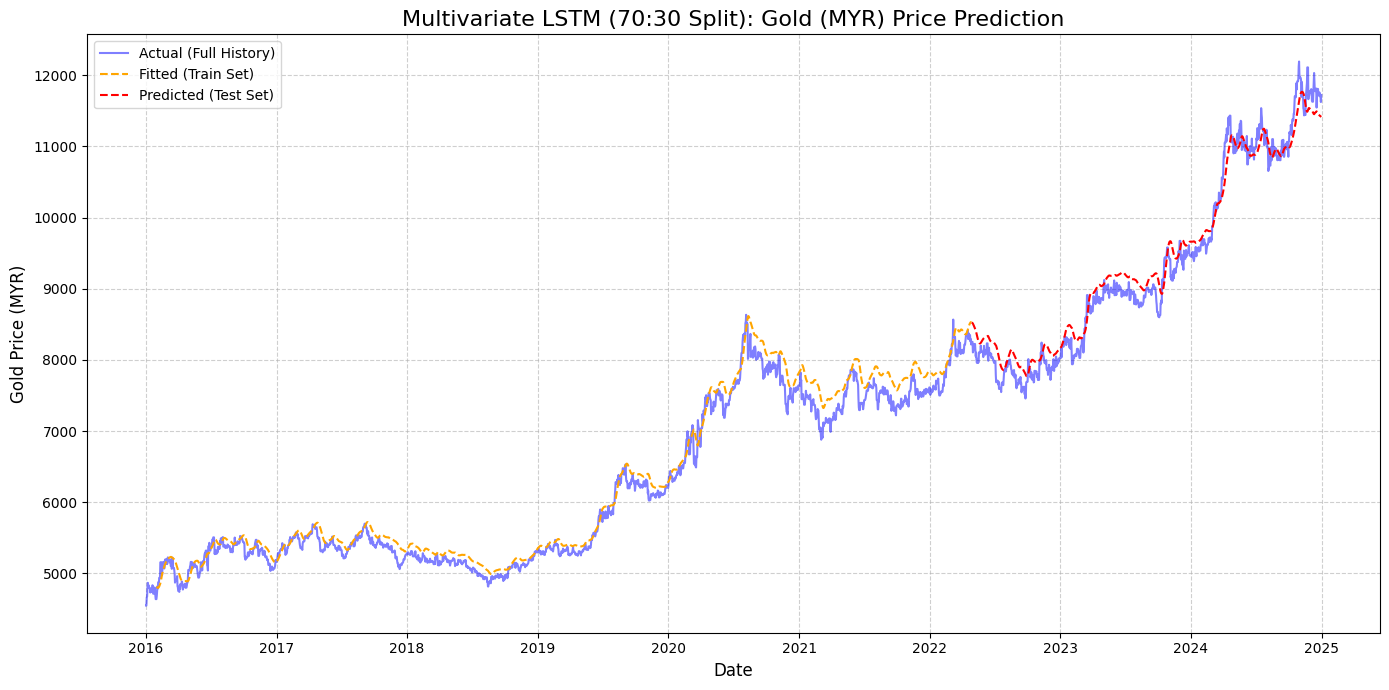


--- 30-Day LSTM Forecast on Test Set (Gold) ---
Gold LSTM 30-day RMSE: 268.04516077449745
Gold LSTM 30-day MAE : 248.38195677139325

=== 30-Day LSTM Forecast Table (Gold) ===


,Date,Gold_Actual,Gold_LSTM_Predicted
0,2022-04-29,8253.29,8528.486870
1,2022-04-30,8253.29,8523.935626
2,2022-05-01,8253.29,8517.397000
3,2022-05-02,8105.80,8511.030636
4,2022-05-03,8126.45,8500.764703
5,2022-05-04,8185.20,8487.693376
6,2022-05-05,8155.80,8476.824074
7,2022-05-06,8224.46,8463.184013
8,2022-05-07,8224.46,8450.678231
9,2022-05-08,8224.46,8439.522282


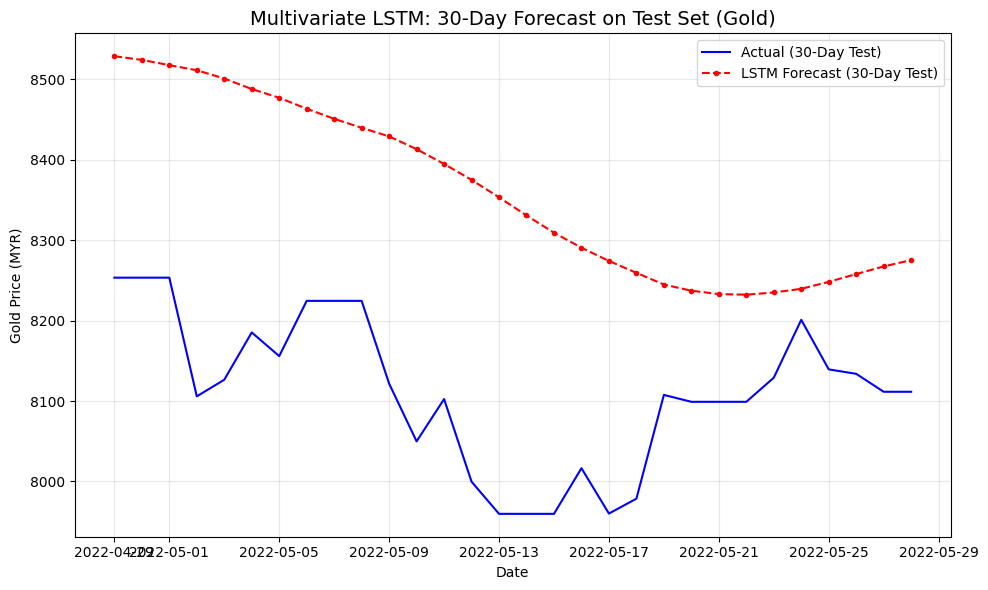

In [ ]:
# --- 10. PLOTTING (Full History Fit) ---
date_index_gold_70 = df_gold_70[date_col_gold_70].iloc[window_size_gold_70:]
train_dates_gold_70 = date_index_gold_70.iloc[:train_split_idx_gold_70]
test_dates_gold_70 = date_index_gold_70.iloc[train_split_idx_gold_70:]

plt.figure(figsize=(14, 7))
plt.plot(df_gold_70[date_col_gold_70], df_gold_70[target_col_gold_70],
         label="Actual (Full History)", color='blue', alpha=0.5)
plt.plot(train_dates_gold_70, y_pred_tr_gold_70,
         label="Fitted (Train Set)", color='orange', linestyle='--')
plt.plot(test_dates_gold_70, y_pred_test_gold_70,
         label="Predicted (Test Set)", color='red', linestyle='--')

plt.title("Multivariate LSTM (70:30 Split): Gold (MYR) Price Prediction", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Gold Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 11. TASK (1): 30-DAY TEST FORECAST FOR FAIR COMPARISON ---
horizon_gold_30 = 30

# take first 30 days of TEST (already inverse-transformed above)
y_true_30_gold = y_true_test_gold_70[:horizon_gold_30]
y_pred_30_gold = y_pred_test_gold_70[:horizon_gold_30]

# corresponding test dates
test_dates_30_gold = test_dates_gold_70[:horizon_gold_30]

rmse_gold_30 = np.sqrt(mean_squared_error(y_true_30_gold, y_pred_30_gold))
mae_gold_30 = mean_absolute_error(y_true_30_gold, y_pred_30_gold)

print("\n--- 30-Day LSTM Forecast on Test Set (Gold) ---")
print("Gold LSTM 30-day RMSE:", rmse_gold_30)
print("Gold LSTM 30-day MAE :", mae_gold_30)

# --- Create 30-Day Comparison Table (Actual vs Predicted) ---
lstm_30day_gold_df = pd.DataFrame({
    'Date': test_dates_30_gold.values,
    'Gold_Actual': y_true_30_gold,
    'Gold_LSTM_Predicted': y_pred_30_gold
})

print("\n=== 30-Day LSTM Forecast Table (Gold) ===")
display(lstm_30day_gold_df)

# Plot 30-day test forecast vs actual
plt.figure(figsize=(10, 6))
plt.plot(test_dates_30_gold, y_true_30_gold, label="Actual (30-Day Test)", color='blue')
plt.plot(test_dates_30_gold, y_pred_30_gold,
         label="LSTM Forecast (30-Day Test)", color='red', linestyle='--', marker='.')
plt.title("Multivariate LSTM: 30-Day Forecast on Test Set (Gold)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Gold Price (MYR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### MV GOLD 30 future


Generating 30-Day Future Forecast (LSTM - Gold)...

--- 30-Day Future Forecast (Multivariate LSTM - Gold) ---
         Date  Gold_LSTM_Forecast
0  2025-01-01        11411.563561
1  2025-01-02        11401.296716
2  2025-01-03        11386.685523
3  2025-01-04        11369.025128
4  2025-01-05        11349.255675
5  2025-01-06        11328.197455
6  2025-01-07        11306.399151
7  2025-01-08        11284.290960
8  2025-01-09        11262.116689
9  2025-01-10        11240.133364
10 2025-01-11        11218.532841
11 2025-01-12        11197.332438
12 2025-01-13        11176.592764
13 2025-01-14        11156.304706
14 2025-01-15        11136.509277
15 2025-01-16        11117.188250
16 2025-01-17        11098.320205
17 2025-01-18        11079.861394
18 2025-01-19        11061.831869
19 2025-01-20        11044.273098
20 2025-01-21        11027.170957
21 2025-01-22        11010.499011
22 2025-01-23        10994.266377
23 2025-01-24        10978.492194
24 2025-01-25        10963.114941
25 20

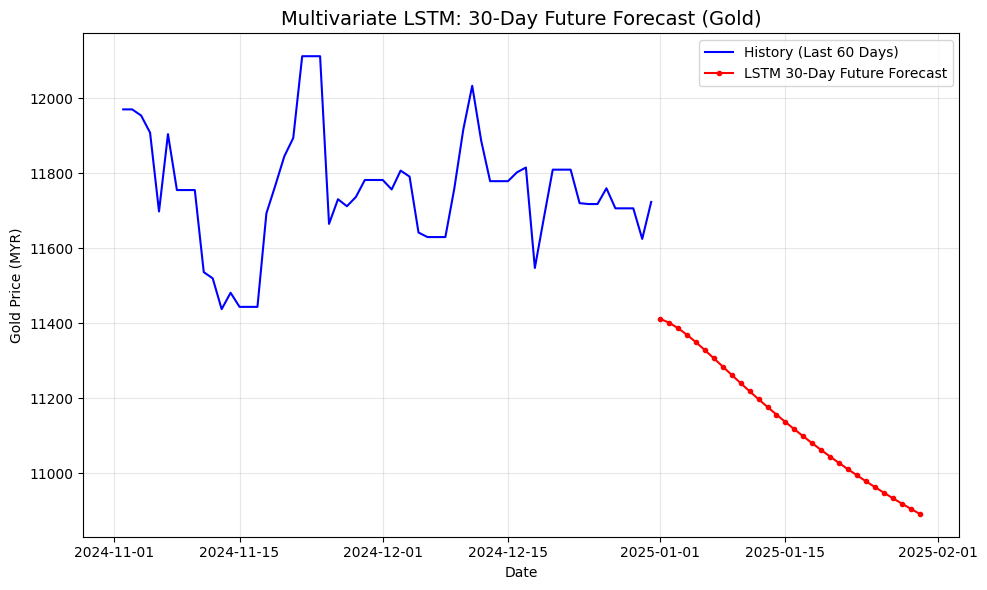

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================
# 1. PREP: GET SCALED FULL DATA AGAIN (GOLD MODEL)
#    (use same scaler and feature_cols as in Gold training)
# ======================================================
data_full_gold = df_gold_70[feature_cols_gold_70].values
scaled_full_gold = scaler_gold_70.transform(data_full_gold)   # same scaler as before

# Last window_size days as starting sequence
last_sequence_gold = scaled_full_gold[-window_size_gold_70:]   # shape: (30, 2)
current_seq_gold   = last_sequence_gold.copy()

forecast_horizon = 30
future_forecast_scaled_gold = []

print(f"\nGenerating {forecast_horizon}-Day Future Forecast (LSTM - Gold)...")

# ======================================================
# 2. ITERATIVE 30-DAY FUTURE FORECAST (GOLD)
# ======================================================
for _ in range(forecast_horizon):
    # shape (1, 30, 2) for LSTM input
    input_seq = current_seq_gold.reshape(1, window_size_gold_70, n_features_gold_70)

    # predict next Gold (scaled) – model_gold_70 predicts Gold
    pred_scaled_gold = model_gold_70.predict(input_seq, verbose=0)[0, 0]
    future_forecast_scaled_gold.append(pred_scaled_gold)

    # assume Bitcoin stays at last known scaled value (naive)
    last_known_btc_scaled = current_seq_gold[-1, 0]
    new_step = np.array([[last_known_btc_scaled, pred_scaled_gold]])

    # slide window forward
    current_seq_gold = np.concatenate([current_seq_gold[1:], new_step], axis=0)

# ======================================================
# 3. INVERSE SCALE FORECAST TO ACTUAL GOLD PRICE (MYR)
# ======================================================
dummy_gold = np.zeros((forecast_horizon, n_features_gold_70))
dummy_gold[:, 1] = np.array(future_forecast_scaled_gold)   # col 1 = Gold
gold_lstm_future = scaler_gold_70.inverse_transform(dummy_gold)[:, 1]

last_date_gold = df_gold_70[date_col_gold_70].iloc[-1]
future_dates_lstm_gold = pd.date_range(start=last_date_gold + pd.Timedelta(days=1),
                                       periods=forecast_horizon)

lstm_future_gold_df = pd.DataFrame({
    'Date': future_dates_lstm_gold,
    'Gold_LSTM_Forecast': gold_lstm_future
})

print("\n--- 30-Day Future Forecast (Multivariate LSTM - Gold) ---")
print(lstm_future_gold_df)

# ======================================================
# 4. PLOT LAST 60 DAYS + LSTM 30-DAY FUTURE FORECAST (GOLD)
# ======================================================
plt.figure(figsize=(10, 6))

# history (last 60 days)
plt.plot(df_gold_70[date_col_gold_70].iloc[-60:], df_gold_70[target_col_gold_70].iloc[-60:],
         label='History (Last 60 Days)', color='blue')

# future forecast
plt.plot(lstm_future_gold_df['Date'], lstm_future_gold_df['Gold_LSTM_Forecast'],
         label='LSTM 30-Day Future Forecast', color='red', marker='.')

plt.title("Multivariate LSTM: 30-Day Future Forecast (Gold)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Gold Price (MYR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# The Hybrid model

### Bitcoin

Len test_dates : 978
Len y_pred_test: 978
Len btc_sigma_test: 987
Len btc_sigma_test_aligned: 978

--- HYBRID LSTM+ARIMA-GARCH (Bitcoin, TEST period) ---
        Date  BTC_Actual  BTC_LSTM_Pred  BTC_GARCH_sigma_return  \
0 2022-04-29   168174.58  174731.803179                4.607528   
1 2022-04-30   164116.35  174488.235686                4.391375   
2 2022-05-01   167651.50  173777.122031                4.210292   
3 2022-05-02   167882.53  173157.741405                4.020685   
4 2022-05-03   164412.76  172657.565940                4.165292   

   BTC_GARCH_sigma_price   BTC_Upper_95   BTC_Lower_95  
0            8050.816652  190511.403817  158952.202541  
1            7662.433212  189506.604782  159469.866590  
2            7316.524131  188117.509328  159436.734734  
3            6962.128083  186803.512448  159511.970362  
4            7191.691805  186753.281877  158561.850003  


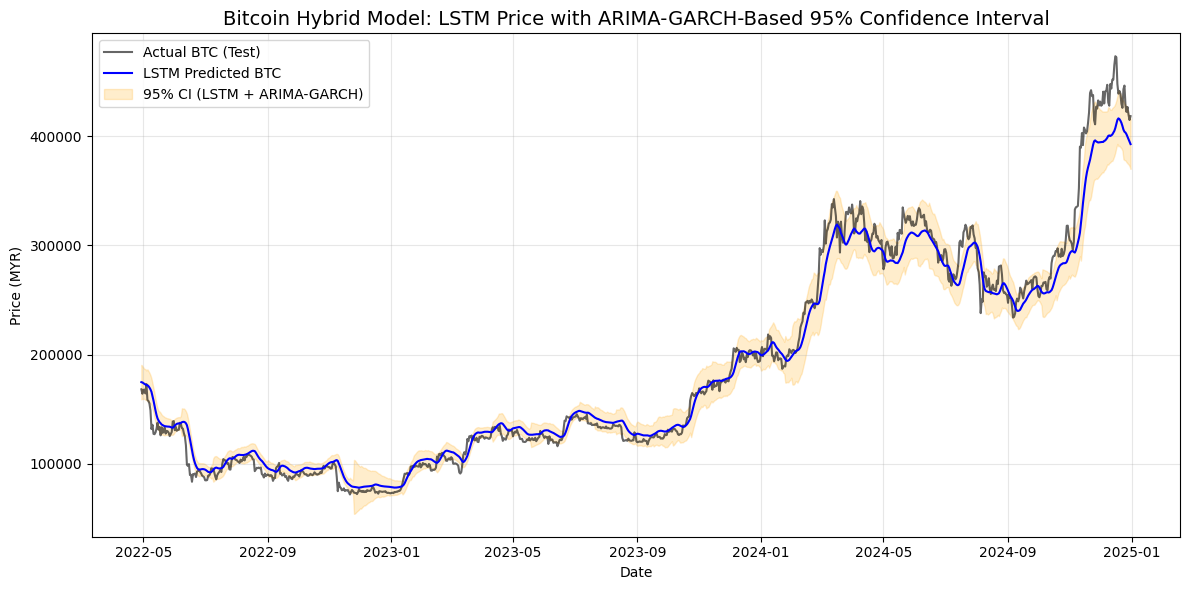

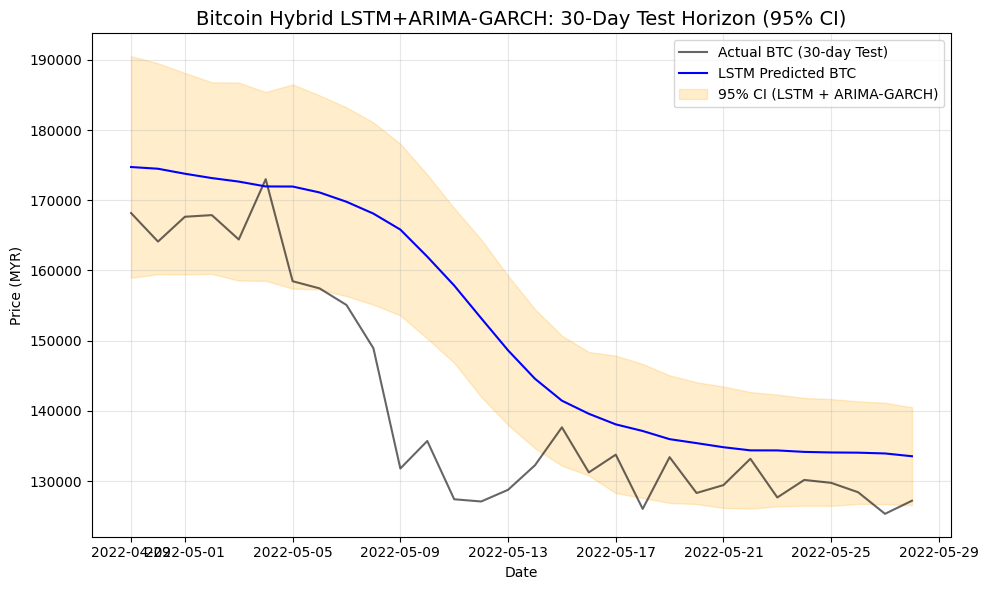

In [84]:
# ======================================================
# HYBRID STEP (BITCOIN): LSTM PRICE + GARCH VOLATILITY
# ======================================================

# 1) Check alignment
print("Len test_dates :", len(test_dates))
print("Len y_pred_test:", len(y_pred_test))
print("Len btc_sigma_test:", len(btc_sigma_test))

# Align GARCH σ to the test period length
if len(btc_sigma_test) > len(y_pred_test):
    btc_sigma_test_aligned = btc_sigma_test[-len(y_pred_test):]
else:
    btc_sigma_test_aligned = btc_sigma_test.copy()

print("Len btc_sigma_test_aligned:", len(btc_sigma_test_aligned))

# 2) Convert GARCH volatility from "return scale (%)" to "price scale"
#    First: convert percent → decimal
btc_sigma_return = btc_sigma_test_aligned / 100.0   # ✅ KEY FIX

#    Then: price volatility = predicted price × return volatility
btc_sigma_price = y_pred_test * btc_sigma_return

# 3) Build 95% confidence interval around LSTM price
z = 1.96  # 95% CI
btc_upper_95 = y_pred_test + z * btc_sigma_price
btc_lower_95 = y_pred_test - z * btc_sigma_price

# 4) Put everything into a single dataframe
btc_hybrid_df = pd.DataFrame({
    "Date": test_dates.values,
    "BTC_Actual": y_true_test,
    "BTC_LSTM_Pred": y_pred_test,
    "BTC_GARCH_sigma_return": btc_sigma_test_aligned,
    "BTC_GARCH_sigma_price": btc_sigma_price,
    "BTC_Upper_95": btc_upper_95,
    "BTC_Lower_95": btc_lower_95
})

print("\n--- HYBRID LSTM+ARIMA-GARCH (Bitcoin, TEST period) ---")
print(btc_hybrid_df.head())

# ======================================================
# PLOT: HYBRID LSTM + GARCH CONFIDENCE INTERVAL (TEST)
# ======================================================

plt.figure(figsize=(12, 6))

# Actual BTC price during test period
plt.plot(btc_hybrid_df["Date"], btc_hybrid_df["BTC_Actual"],
         label="Actual BTC (Test)", color="black", alpha=0.6)

# LSTM point forecast
plt.plot(btc_hybrid_df["Date"], btc_hybrid_df["BTC_LSTM_Pred"],
         label="LSTM Predicted BTC", color="blue")

# Confidence band
plt.fill_between(btc_hybrid_df["Date"],
                 btc_hybrid_df["BTC_Lower_95"],
                 btc_hybrid_df["BTC_Upper_95"],
                 color="orange", alpha=0.2,
                 label="95% CI (LSTM + ARIMA-GARCH)")

plt.title("Bitcoin Hybrid Model: LSTM Price with ARIMA-GARCH-Based 95% Confidence Interval",
          fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (MYR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

h = 30  # first 30 test days

btc_hybrid_30 = btc_hybrid_df.iloc[:h].copy()

plt.figure(figsize=(10, 6))
plt.plot(btc_hybrid_30["Date"], btc_hybrid_30["BTC_Actual"],
         label="Actual BTC (30-day Test)", color="black", alpha=0.6)
plt.plot(btc_hybrid_30["Date"], btc_hybrid_30["BTC_LSTM_Pred"],
         label="LSTM Predicted BTC", color="blue")
plt.fill_between(btc_hybrid_30["Date"],
                 btc_hybrid_30["BTC_Lower_95"],
                 btc_hybrid_30["BTC_Upper_95"],
                 color="orange", alpha=0.2,
                 label="95% CI (LSTM + ARIMA-GARCH)")

plt.title("Bitcoin Hybrid LSTM+ARIMA-GARCH: 30-Day Test Horizon (95% CI)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (MYR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




--- HYBRID LSTM+ARIMA-GARCH (Bitcoin, 30-Day FUTURE) ---
        Date  BTC_LSTM_Future  BTC_GARCH_sigma_return_future  \
0 2025-01-01    390421.504918                       0.028737   
1 2025-01-02    386367.208558                       0.029000   
2 2025-01-03    381469.271859                       0.029261   
3 2025-01-04    376171.548904                       0.029519   
4 2025-01-05    370719.026463                       0.029775   

   BTC_GARCH_sigma_price_future  BTC_Upper_95_future  BTC_Lower_95_future  
0                  11219.716591        412412.149437        368430.860398  
1                  11204.764701        408328.547373        364405.869744  
2                  11162.093146        403346.974425        359591.569294  
3                  11104.202941        397935.786669        354407.311140  
4                  11038.137573        392353.776106        349084.276819  


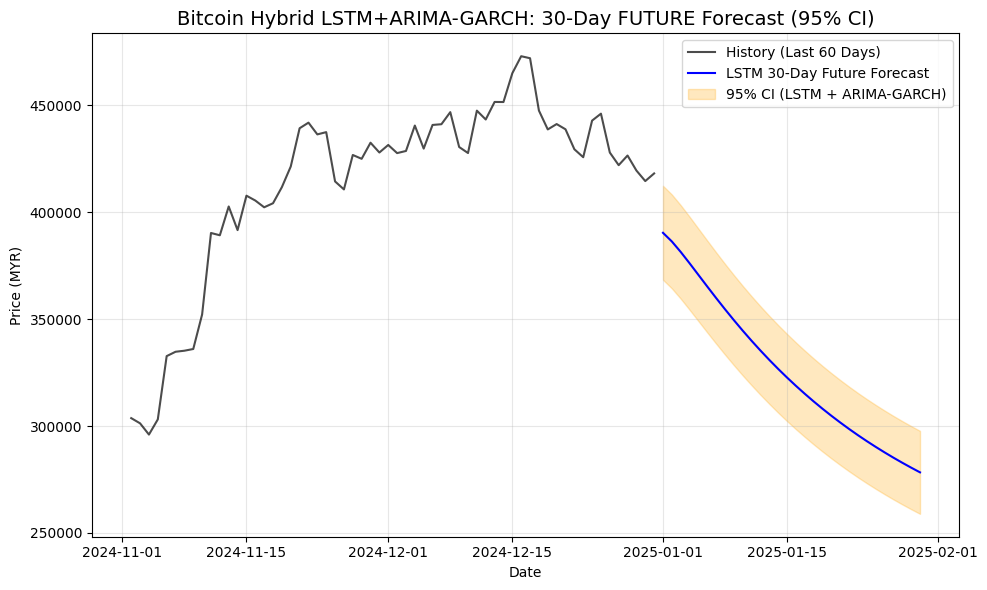

In [90]:
# ======================================================
# HYBRID FUTURE 30-DAY FORECAST: LSTM PRICE + ARIMA-GARCH VOL
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. GARCH FUTURE VOLATILITY FORECAST (on returns) ---
# NOTE: change 'res_garch_btc' to your ARIMA-GARCH result variable
garch_future = res_garch_btc.forecast(horizon=30)

# For horizon=30, arch will give columns h.1 ... h.30 on the last row
btc_sigma_future_ret = np.sqrt(garch_future.variance.iloc[-1].values)   # shape (30,)

# If your GARCH model was estimated on percentage returns (e.g. 4.5 instead of 0.045),
# scale it back to decimal form
if btc_sigma_future_ret.mean() > 1:
    btc_sigma_future_ret = btc_sigma_future_ret / 100.0

# --- 2. Convert volatility from "return scale" to "price scale" ---
# Use LSTM future price as the level
btc_sigma_future_price = btc_lstm_future * btc_sigma_future_ret

# --- 3. Build 95% confidence interval around LSTM future forecast ---
z = 1.96  # 95% confidence
btc_upper_future_95 = btc_lstm_future + z * btc_sigma_future_price
btc_lower_future_95 = btc_lstm_future - z * btc_sigma_future_price

# --- 4. Put everything into a single DataFrame ---
btc_hybrid_future_df = pd.DataFrame({
    "Date": future_dates_lstm,
    "BTC_LSTM_Future": btc_lstm_future,
    "BTC_GARCH_sigma_return_future": btc_sigma_future_ret,
    "BTC_GARCH_sigma_price_future": btc_sigma_future_price,
    "BTC_Upper_95_future": btc_upper_future_95,
    "BTC_Lower_95_future": btc_lower_future_95
})

print("\n--- HYBRID LSTM+ARIMA-GARCH (Bitcoin, 30-Day FUTURE) ---")
print(btc_hybrid_future_df.head())

# --- 5. Plot: last 60 days of history + 30-day hybrid future forecast ---
plt.figure(figsize=(10, 6))

# History: last 60 days of actual BTC
plt.plot(
    df[date_col].iloc[-60:],
    df['Bitcoin'].iloc[-60:],
    label='History (Last 60 Days)',
    color='black',
    alpha=0.7
)

# LSTM future point forecast
plt.plot(
    btc_hybrid_future_df["Date"],
    btc_hybrid_future_df["BTC_LSTM_Future"],
    label='LSTM 30-Day Future Forecast',
    color='blue'
)

# Confidence band from ARIMA-GARCH volatility
plt.fill_between(
    btc_hybrid_future_df["Date"],
    btc_hybrid_future_df["BTC_Lower_95_future"],
    btc_hybrid_future_df["BTC_Upper_95_future"],
    color='orange',
    alpha=0.25,
    label='95% CI (LSTM + ARIMA-GARCH)'
)

plt.title("Bitcoin Hybrid LSTM+ARIMA-GARCH: 30-Day FUTURE Forecast (95% CI)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (MYR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Split 75:25


In [35]:
train75_size = int(len(merged) * 0.75)
train75_data = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[0:train75_size]
test75_data = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[train75_size:len(merged)]

print("Training data size:", len(train75_data))
print("Testing data size:", len(test75_data))

Training data size: 2464
Testing data size: 822


## ACF dan PACF of 75:25

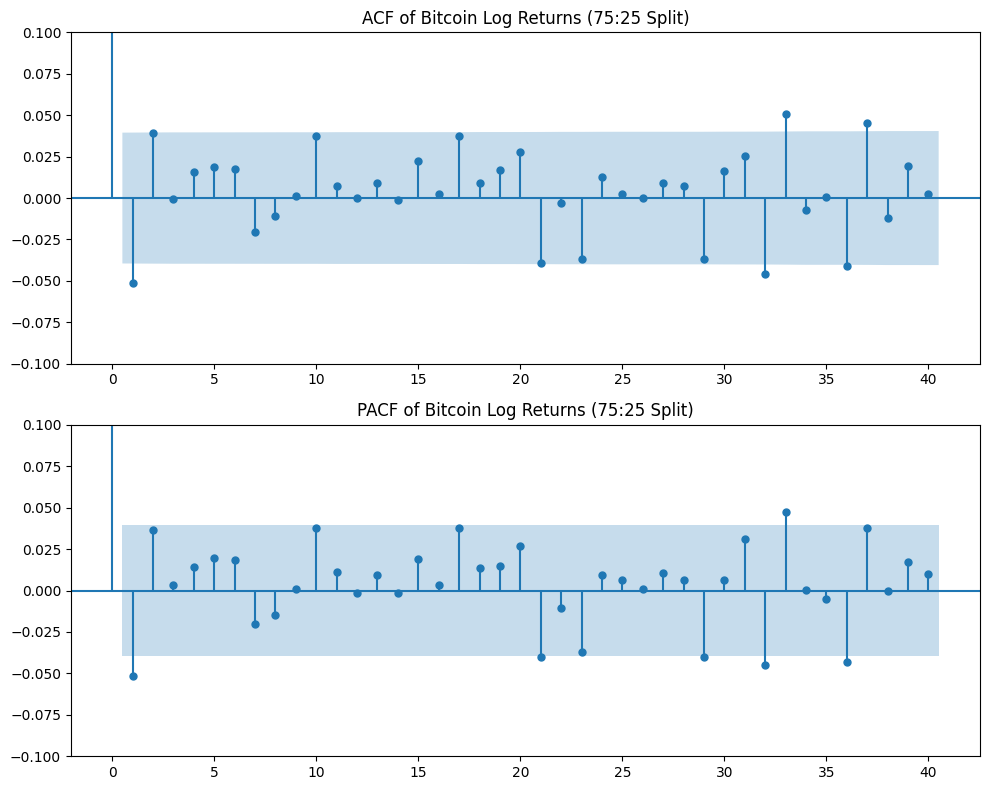

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for Bitcoin Log Returns (75:25 Split)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(train75_data['Bitcoin_logret'].dropna(), ax=axes[0], lags=40)
plot_pacf(train75_data['Bitcoin_logret'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Bitcoin Log Returns (75:25 Split)')
axes[1].set_title('PACF of Bitcoin Log Returns (75:25 Split)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

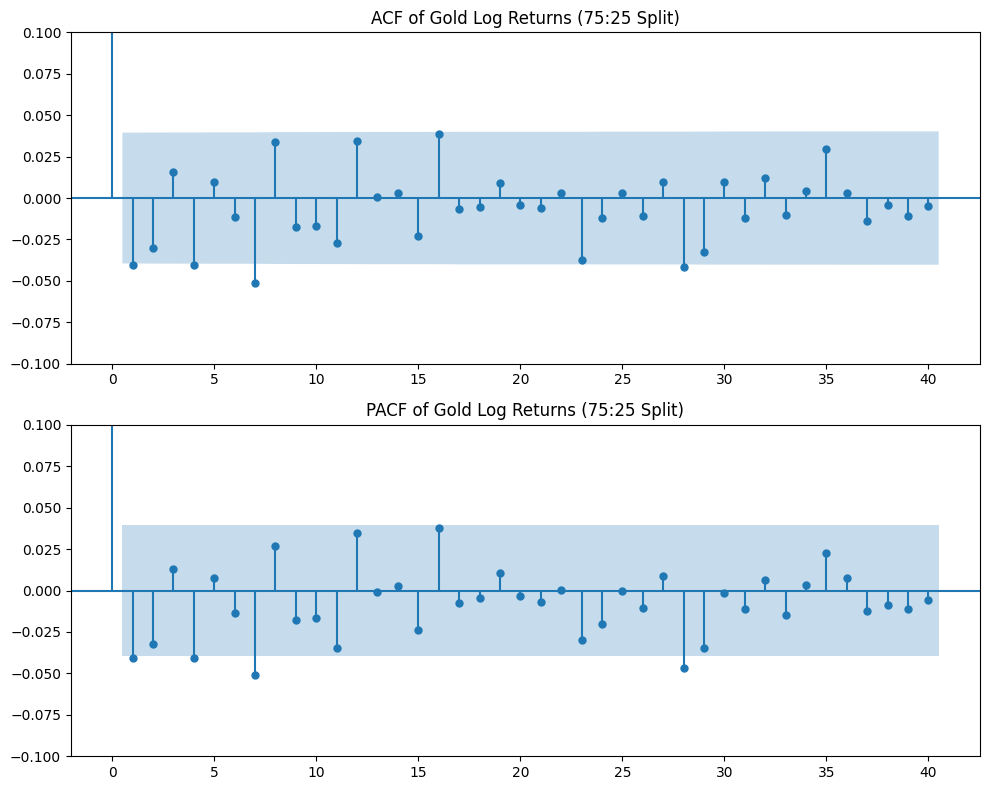

In [ ]:
# Plot ACF and PACF for Gold Log Returns (75:25 Split)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(train75_data['Gold_logret'].dropna(), ax=axes[0], lags=40)
plot_pacf(train75_data['Gold_logret'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Gold Log Returns (75:25 Split)')
axes[1].set_title('PACF of Gold Log Returns (75:25 Split)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

## ARIMA


In [38]:
# Fit auto_arima model on Bitcoin log returns
model75_bitcoin = pm.auto_arima(train75_data['Bitcoin_logret']*100, start_p=1, start_q=1,
                              max_p=5, max_q=5,
                              m=1,            # frequency of series (set to 1 for non-seasonal data)
                              d=None,         # let the model determine 'd'
                              seasonal=False, # assuming no seasonality
                              test='adf',     # use ADF test to find 'd'
                              trace=True,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)
print("Bitcoin auto ARIMA Model Summary:")
print(model75_bitcoin.summary())

# Fit auto_arima model on Gold log returns
model75_gold = pm.auto_arima(train75_data['Gold_logret']*100,
                             max_p=5, max_q=5,
                              m=1,            # frequency of series (set to 1 for non-seasonal data)
                              d=None,         # let the model determine 'd'
                              seasonal=False, # assuming no seasonality
                              test='adf',     # use ADF test to find 'd'
                              trace=True,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)
print("\nGold ARIMA(3,0,3) Model Summary:")
print(model75_gold.summary())

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=13848.123, Time=0.72 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=13852.957, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=13848.875, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=13849.323, Time=0.16 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=13846.480, Time=0.98 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=13847.244, Time=0.16 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=13846.504, Time=1.64 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=13846.562, Time=1.71 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=13846.973, Time=2.23 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=13849.180, Time=0.31 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=13848.459, Time=4.52 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=13846.381, Time=2.88 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=13846.072, Time=1.77 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=13847.163, Time=0.36 sec
 ARIMA(1,0,0)(0,0,0

## ARIMA REJA DAN UJIAN


In [41]:
# 1. Get residuals from your auto_arima models (which are already fitted)
btc75_residuals = model75_bitcoin.resid()
gold75_residuals = model75_gold.resid()

# 2. Rescale the residuals to fix the DataScaleWarning
# (This is still a good practice)
btc75_resid_scaled = btc75_residuals
gold75_resid_scaled = gold75_residuals


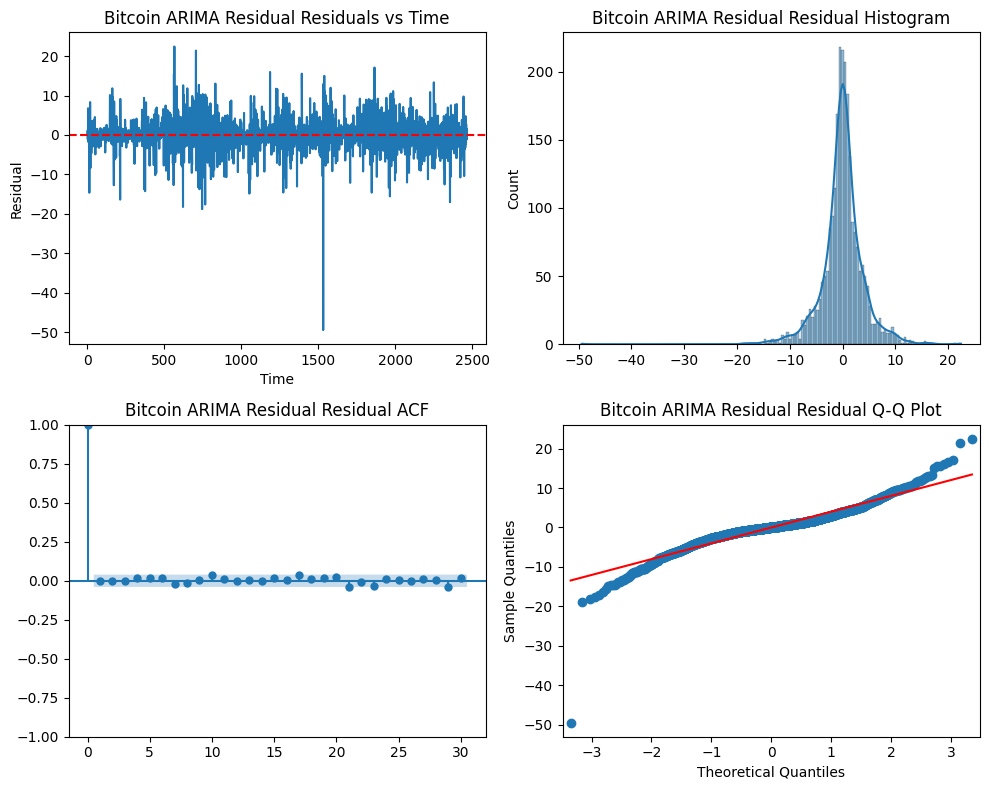

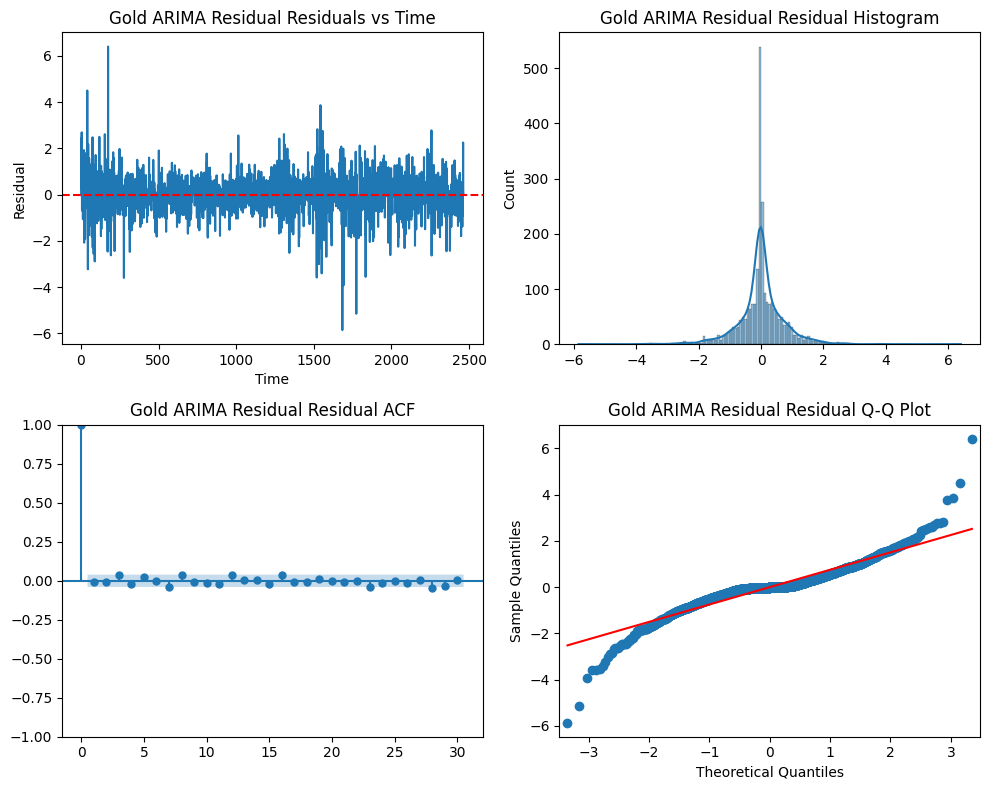

In [45]:
# ================================
# 1. RESIDUAL DIAGNOSTIC PLOTS
# ================================
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot

def residual_diagnostic_plots(residuals, title_prefix):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    # (a) Residual vs Time
    axes[0, 0].plot(residuals)
    axes[0, 0].axhline(0, linestyle='--',color='red')
    axes[0, 0].set_title(f'{title_prefix} Residuals vs Time')
    axes[0, 0].set_xlabel('Time')
    axes[0, 0].set_ylabel('Residual')

    # (b) Histogram
    sns.histplot(residuals, kde=True, ax=axes[0, 1])
    axes[0, 1].set_title(f'{title_prefix} Residual Histogram')

    # (c) ACF plot
    plot_acf(residuals, ax=axes[1, 0], lags=30)
    axes[1, 0].set_title(f'{title_prefix} Residual ACF')

    # (d) Q-Q plot
    qqplot(residuals, line='s', ax=axes[1, 1])
    axes[1, 1].set_title(f'{title_prefix} Residual Q-Q Plot')

    plt.tight_layout()
    plt.show()

# ---- Bitcoin ----
residual_diagnostic_plots(btc75_resid_scaled, "Bitcoin ARIMA Residual")

# ---- Gold ----
residual_diagnostic_plots(gold75_resid_scaled, "Gold ARIMA Residual")

In [ ]:
# ================================
# 2. LJUNG-BOX TEST
# ================================
from statsmodels.stats.diagnostic import acorr_ljungbox

print("\n=== Ljung-Box Test: Bitcoin ===")
lb_btc = acorr_ljungbox(btc75_resid_scaled, lags=[10, 20], return_df=True)
print(lb_btc)

print("\n=== Ljung-Box Test: Gold ===")
lb_gold = acorr_ljungbox(gold75_resid_scaled, lags=[10, 20], return_df=True)
print(lb_gold)


=== Ljung-Box Test: Bitcoin ===
      lb_stat  lb_pvalue
10   7.783698   0.649956
20  15.680475   0.736239

=== Ljung-Box Test: Gold ===
      lb_stat  lb_pvalue
10  14.720783   0.142578
20  24.681075   0.213906


In [ ]:
# ================================
# 4. JARQUE-BERA TEST
# ================================
from statsmodels.stats.stattools import jarque_bera

print("\n=== Jarque-Bera Test: Bitcoin ===")
jb_btc = jarque_bera(btc75_resid_scaled)
print(f"JB stat   : {jb_btc[0]:.4f}")
print(f"JB p-value: {jb_btc[1]:.4f}")
print(f"Skewness  : {jb_btc[2]:.4f}")
print(f"Kurtosis  : {jb_btc[3]:.4f}")

print("\n=== Jarque-Bera Test: Gold ===")
jb_gold = jarque_bera(gold75_resid_scaled)
print(f"JB stat   : {jb_gold[0]:.4f}")
print(f"JB p-value: {jb_gold[1]:.4f}")
print(f"Skewness  : {jb_gold[2]:.4f}")
print(f"Kurtosis  : {jb_gold[3]:.4f}")


=== Jarque-Bera Test: Bitcoin ===
JB stat   : 15388.7328
JB p-value: 0.0000
Skewness  : -0.8354
Kurtosis  : 15.1259

=== Jarque-Bera Test: Gold ===
JB stat   : 6207.7424
JB p-value: 0.0000
Skewness  : -0.1911
Kurtosis  : 10.7650


# ARCHLM test

In [ ]:
# ================================
# 3. ARCH-LM TEST
# ================================
from statsmodels.stats.diagnostic import het_arch

print("\n=== ARCH-LM Test: Bitcoin ===")
arch_btc = het_arch(btc75_resid_scaled, nlags=10)
print(f"LM stat   : {arch_btc[0]:.4f}")
print(f"LM p-value: {arch_btc[1]:.4f}")
print(f"F stat    : {arch_btc[2]:.4f}")
print(f"F p-value : {arch_btc[3]:.4f}")

print("\n=== ARCH-LM Test: Gold ===")
arch_gold = het_arch(gold75_resid_scaled, nlags=10)
print(f"LM stat   : {arch_gold[0]:.4f}")
print(f"LM p-value: {arch_gold[1]:.4f}")
print(f"F stat    : {arch_gold[2]:.4f}")
print(f"F p-value : {arch_gold[3]:.4f}")


=== ARCH-LM Test: Bitcoin ===
LM stat   : 43.5351
LM p-value: 0.0000
F stat    : 4.4122
F p-value : 0.0000

=== ARCH-LM Test: Gold ===
LM stat   : 93.5558
LM p-value: 0.0000
F stat    : 9.6827
F p-value : 0.0000


## ARIMA-GARCH

## ARIMA-GARCH t distribution

In [ ]:
# 1. Get residuals from your auto_arima models (which are already fitted)
btc75_residuals = model75_bitcoin.resid()
gold75_residuals = model75_gold.resid()

# 2. Rescale the residuals to fix the DataScaleWarning
btc75_resid_scaled = btc75_residuals
gold75_resid_scaled = gold75_residuals

# 3. Fit GARCH(1,1) on the SCALED RESIDUALS
garch75_btc = arch_model(btc75_resid_scaled,
mean='Zero',
vol='Garch', p=1, q=1,
dist='t')

res75_garch_btc = garch75_btc.fit(disp='off')
print("Bitcoin GARCH(1,1) on ARMA(2,2) Residuals (t-distribution):")
print(res75_garch_btc.summary())

# 4. Fit GARCH(1,1) on the SCALED RESIDUALS for Gold
garch75_gold = arch_model(gold75_resid_scaled,
mean='Zero',
vol='Garch', p=1, q=1,
dist='t')

res75_garch_gold = garch75_gold.fit(disp='off')
print("\nGold GARCH(1,1) on MA(1) Residuals (t-distribution):")
print(res75_garch_gold.summary())

# 5. Fit EGARCH(1,1) on the SCALED RESIDUALS for Gold
egarch_gold1 = arch_model(gold75_resid_scaled,
mean='Zero',
vol='EGARCH', p=1, q=1,
dist='t')

res75_egarch_gold1 = egarch_gold1.fit(disp='off')
print("\nGold EGARCH(1,1) on MA(1) Residuals (t-distribution):")
print(res75_egarch_gold1.summary())

# 5. Fit EGARCH(2,2) on the SCALED RESIDUALS for Gold
egarch_gold2 = arch_model(gold75_resid_scaled,
mean='Zero',
vol='EGARCH', p=2, q=2,
dist='t')

res75_egarch_gold2 = egarch_gold2.fit(disp='off')
print("\nGold EGARCH(2,2) on MA(1) Residuals (t-distribution):")
print(res75_egarch_gold2.summary())


Bitcoin GARCH(1,1) on ARMA(2,2) Residuals (t-distribution):
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -6433.93
Distribution:      Standardized Student's t   AIC:                           12875.9
Method:                  Maximum Likelihood   BIC:                           12899.1
                                              No. Observations:                 2465
Date:                      Wed, Dec 03 2025   Df Residuals:                     2465
Time:                              14:10:18   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
-----------------------

## ACF & PACF squared


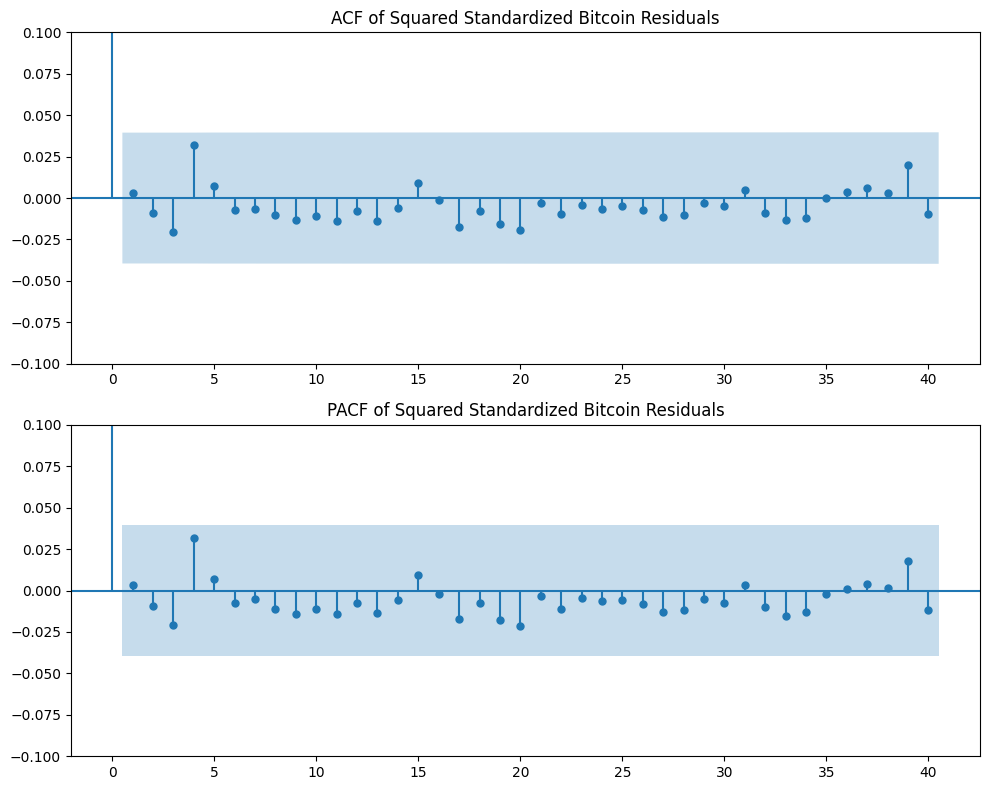

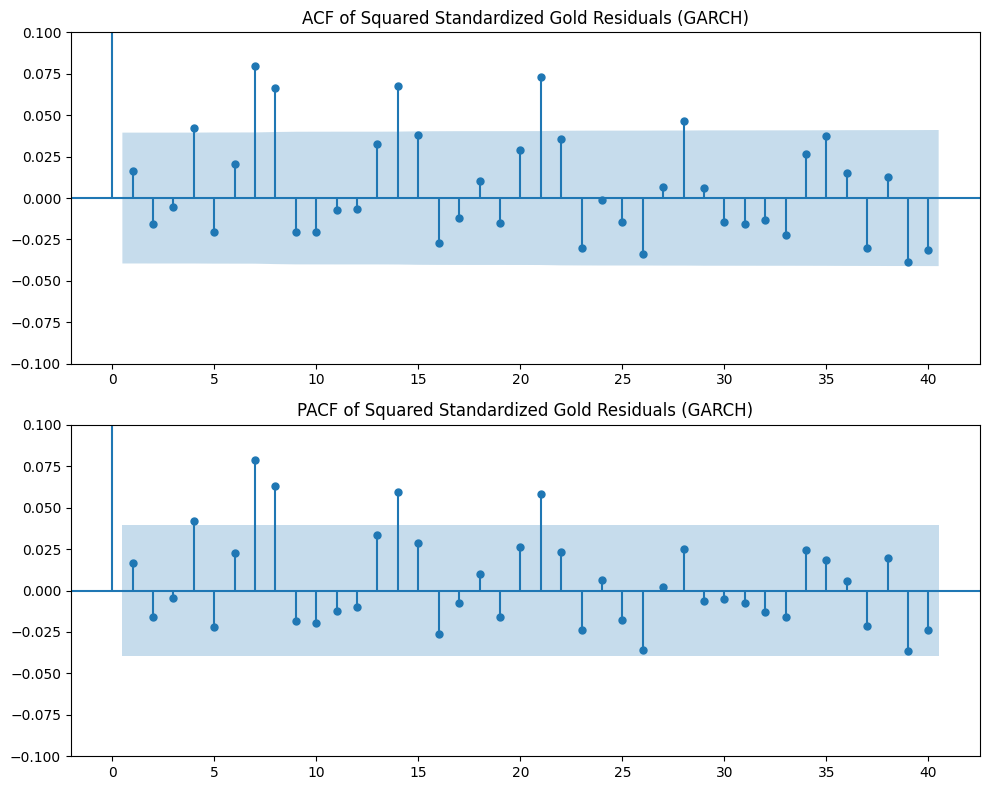

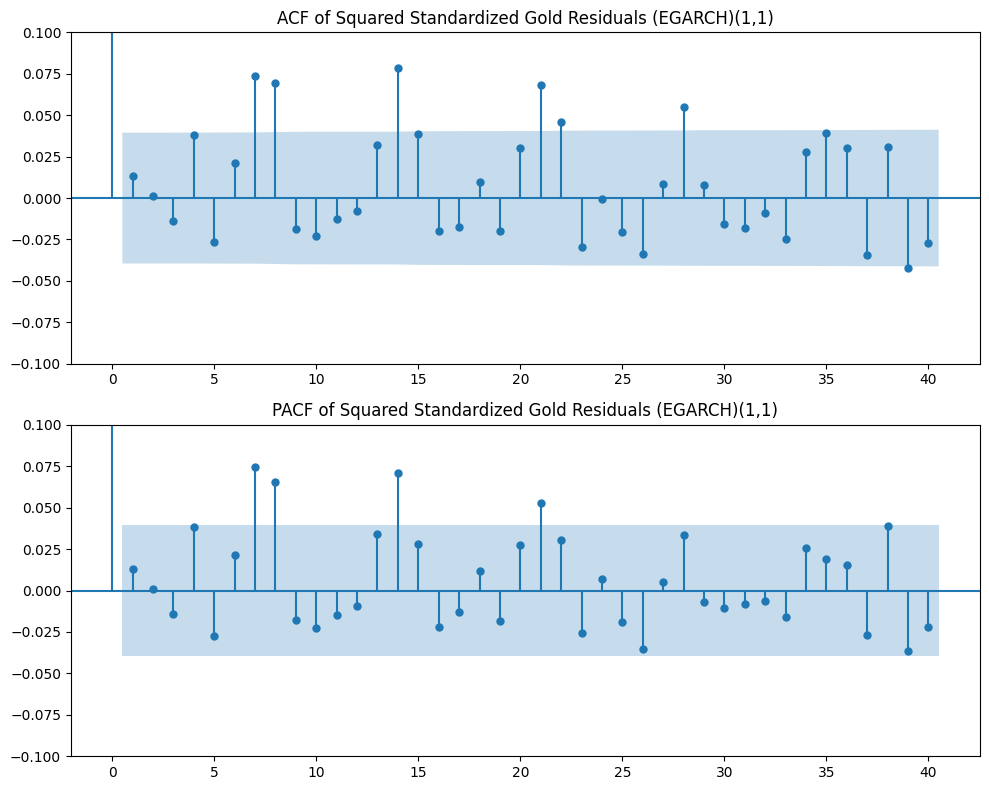

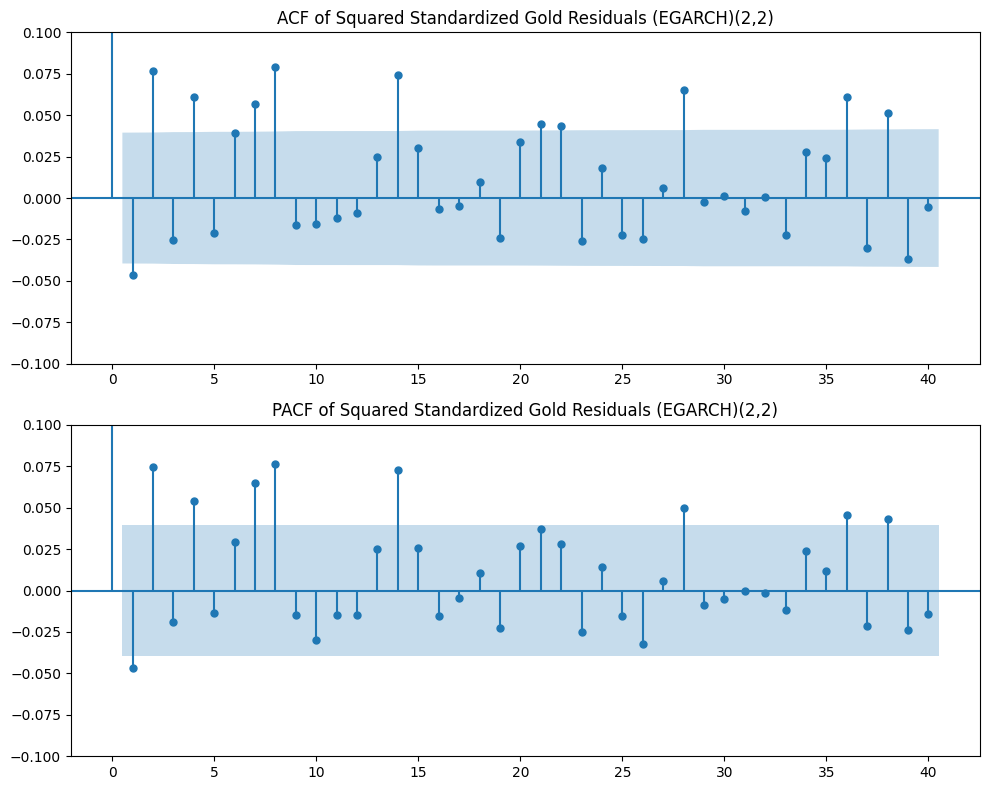

In [ ]:
# Get the standardized residuals
btc75_std_resid = res75_garch_btc.std_resid
gold75_std_resid = res75_garch_gold.std_resid

# Square the standardized residuals
btc75_std_resid_sq = btc75_std_resid**2
gold75_std_resid_sq = gold75_std_resid**2

# Plot ACF and PACF for squared standardized Bitcoin residuals
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(btc75_std_resid_sq.dropna(), ax=axes[0], lags=40)
plot_pacf(btc75_std_resid_sq.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Bitcoin Residuals')
axes[1].set_title('PACF of Squared Standardized Bitcoin Residuals')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Plot ACF and PACF for squared standardized Gold residuals (GARCH)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold75_std_resid_sq.dropna(), ax=axes[0], lags=40)
plot_pacf(gold75_std_resid_sq.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (GARCH)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (GARCH)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

#1 - for 1,1 GARCH and 2- for 2,2 GARCH

# Get standardized residuals for EGARCH and GJR-GARCH Gold models
gold75_std_resid_egarch1 = res75_egarch_gold1.std_resid
gold75_std_resid_egarch2 = res75_egarch_gold2.std_resid
gold75_std_resid_gjr_garch = res75_gjr_garch_gold.std_resid

# Square the standardized residuals for EGARCH and GJR-GARCH Gold models
gold75_std_resid_sq_egarch1 = gold75_std_resid_egarch1**2
gold75_std_resid_sq_egarch2 = gold75_std_resid_egarch2**2
gold75_std_resid_sq_gjr_garch = gold75_std_resid_gjr_garch**2

# Plot ACF and PACF for squared standardized Gold residuals (EGARCH)(1,1)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold75_std_resid_sq_egarch1.dropna(), ax=axes[0], lags=40)
plot_pacf(gold75_std_resid_sq_egarch1.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (EGARCH)(1,1)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (EGARCH)(1,1)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Plot ACF and PACF for squared standardized Gold residuals (EGARCH)(2,2)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold75_std_resid_sq_egarch2.dropna(), ax=axes[0], lags=40)
plot_pacf(gold75_std_resid_sq_egarch2.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (EGARCH)(2,2)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (EGARCH)(2,2)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()


## Is the Distribution correct?

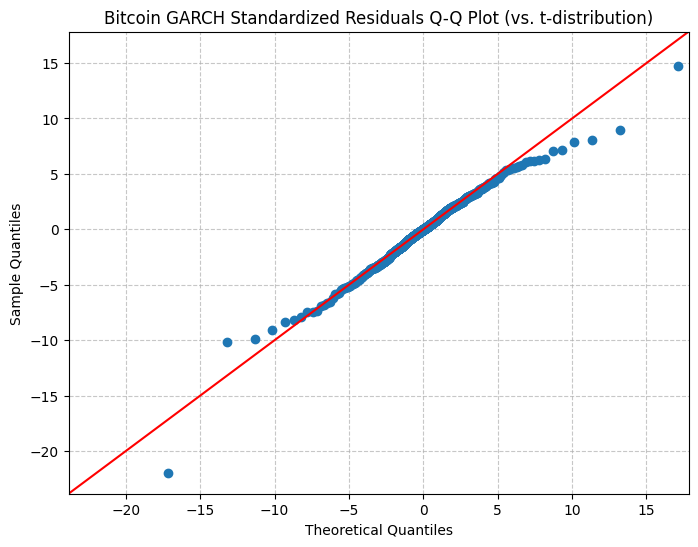

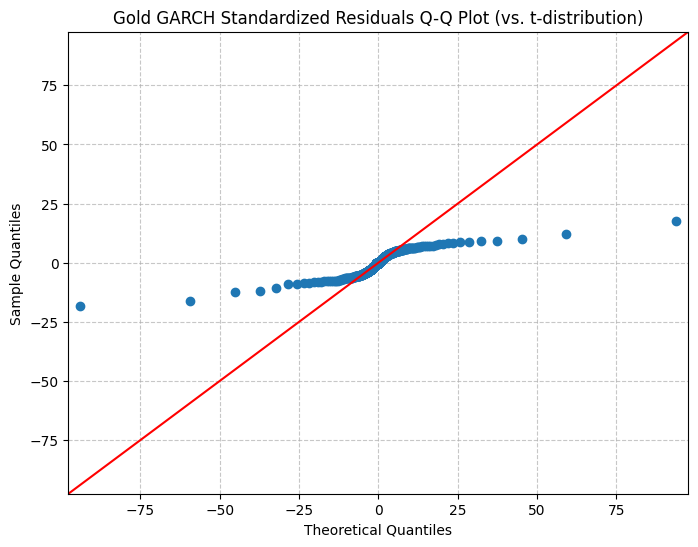

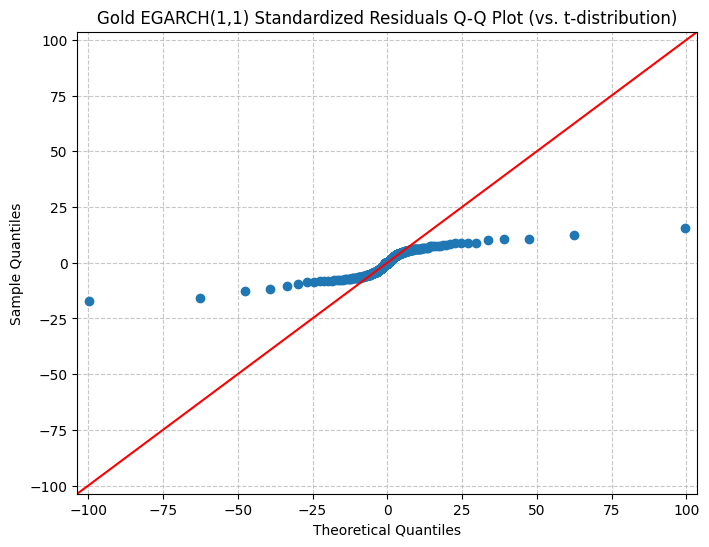

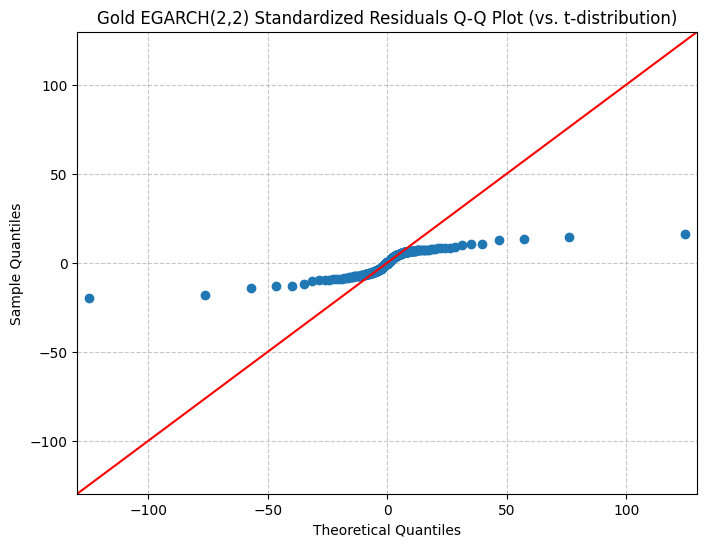

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import t

# --- Bitcoin GARCH Residuals Q-Q Plot ---
# Using variable: res75_garch_btc
btc_std_resid = res75_garch_btc.std_resid.dropna()

plt.figure(figsize=(8, 6))
qqplot(btc_std_resid, dist=t, line='45', fit=True, ax=plt.gca())
plt.title('Bitcoin GARCH Standardized Residuals Q-Q Plot (vs. t-distribution)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Gold GARCH Residuals Q-Q Plot ---
# Using variable: res75_garch_gold
gold_std_resid = res75_garch_gold.std_resid.dropna()

plt.figure(figsize=(8, 6))
qqplot(gold_std_resid, dist=t, line='45', fit=True, ax=plt.gca())
plt.title('Gold GARCH Standardized Residuals Q-Q Plot (vs. t-distribution)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Gold EGARCH(1,1) Residuals Q-Q Plot (for comparison) ---
# Using variable: res75_egarch_gold1
gold_std_resid_egarch11 = res75_egarch_gold1.std_resid.dropna()

plt.figure(figsize=(8, 6))
qqplot(gold_std_resid_egarch11, dist=t, line='45', fit=True, ax=plt.gca())
plt.title('Gold EGARCH(1,1) Standardized Residuals Q-Q Plot (vs. t-distribution)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Gold EGARCH(2,2) Residuals Q-Q Plot (for comparison) ---
# Using variable: res75_egarch_gold2
gold_std_resid_egarch22 = res75_egarch_gold2.std_resid.dropna()

plt.figure(figsize=(8, 6))
qqplot(gold_std_resid_egarch22, dist=t, line='45', fit=True, ax=plt.gca())
plt.title('Gold EGARCH(2,2) Standardized Residuals Q-Q Plot (vs. t-distribution)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Forecast New


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

# ======================================================
# 1. SETUP: PREPARE FINAL FULL DATASET
# ======================================================
# We create a specific copy for the final forecast to avoid touching 'merged' directly
df_final = merged.copy()

# Recalculate returns on the full dataset to be safe
df_final['Bitcoin_logret'] = np.log(df_final['Bitcoin']).diff()
df_final['Gold_logret'] = np.log(df_final['Gold']).diff()

# Drop the single NaN created by differencing
df_final = df_final.dropna()

# Create DISTINCT variables for the full scaled data
final_btc_scaled = df_final['Bitcoin_logret'] * 100
final_gold_scaled = df_final['Gold_logret'] * 100

# Get the anchor points (Last known real values)
last_known_btc_price = df_final['Bitcoin'].iloc[-1]
last_known_gold_price = df_final['Gold'].iloc[-1]
last_known_date = pd.to_datetime(df_final['Date'].iloc[-1])

print(f"--- FINAL MODEL SETUP ---")
print(f"Forecasting starts after date: {last_known_date.date()}")
print(f"Base Bitcoin Price: {last_known_btc_price}")
print(f"Base Gold Price:    {last_known_gold_price}")

# ======================================================
# 2. FIT FINAL MODELS (USING 100% DATA)
# ======================================================

print("\nFitting Final Bitcoin Models...")
# Note the prefix 'final_'
final_model_btc_arima = ARIMA(final_btc_scaled, order=(0, 0, 2), trend='c').fit()
final_model_btc_garch = arch_model(final_btc_scaled, mean='Zero', vol='Garch', p=1, q=1, dist='t').fit(disp='off')

print("Fitting Final Gold Models...")
final_model_gold_arima = ARIMA(final_gold_scaled, order=(1, 0, 1), trend='c').fit()
final_model_gold_egarch = arch_model(final_gold_scaled, mean='Zero', vol='EGARCH', p=2, q=2, dist='t').fit(disp='off')

# ======================================================
# 3. FORECAST INTO THE FUTURE
# ======================================================
forecast_horizon = 30

# --- A. Mean Forecast (ARIMA) ---
# We use distinct variable names for the future results
future_btc_mean = final_model_btc_arima.forecast(steps=forecast_horizon)
future_gold_mean = final_model_gold_arima.forecast(steps=forecast_horizon)

# Rescale back to decimals
future_btc_ret_pred = future_btc_mean / 100
future_gold_ret_pred = future_gold_mean / 100

# ======================================================
# 4. CONVERT TO PRICE (MYR)
# ======================================================

# --- Bitcoin Future Path ---
future_btc_prices = []
curr_price = last_known_btc_price

for r in future_btc_ret_pred:
    curr_price = curr_price * np.exp(r)
    future_btc_prices.append(curr_price)

# --- Gold Future Path ---
future_gold_prices = []
curr_price = last_known_gold_price

for r in future_gold_ret_pred:
    curr_price = curr_price * np.exp(r)
    future_gold_prices.append(curr_price)

# Create Date Range for the unknown future
future_dates_list = pd.date_range(start=last_known_date + pd.Timedelta(days=1), periods=forecast_horizon, freq='D')

# ======================================================
# 5. CREATE THE FINAL DATAFRAME
# ======================================================
# This dataframe is specifically for your "Lampiran" or final results
final_forecast_df = pd.DataFrame({
    'Future_Date': future_dates_list,
    'Bitcoin_Predicted_MYR': future_btc_prices,
    'Gold_Predicted_MYR': future_gold_prices
})

print("\n--- 30-Day Future Forecast Table (Preview) ---")
print(final_forecast_df.head())


# ======================================================
# 6. VISUALIZE (DISTINCT PLOT)
# ======================================================
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Bitcoin Plot
# We plot the last 90 days of REAL history + 30 days of FUTURE prediction
ax[0].plot(df_final['Date'].iloc[-90:], df_final['Bitcoin'].iloc[-90:], label='Historical Data (Last 90 Days)')
ax[0].plot(future_dates_list, future_btc_prices, color='red', marker='.', linestyle='--', label='Future Forecast (30 Days)')
ax[0].set_title('FINAL Bitcoin Forecast: Next 30 Days')
ax[0].set_ylabel('Price (MYR)')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Gold Plot
ax[1].plot(df_final['Date'].iloc[-90:], df_final['Gold'].iloc[-90:], label='Historical Data (Last 90 Days)')
ax[1].plot(future_dates_list, future_gold_prices, color='orange', marker='.', linestyle='--', label='Future Forecast (30 Days)')
ax[1].set_title('FINAL Gold Forecast: Next 30 Days')
ax[1].set_ylabel('Price (MYR)')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### forecast(not final)

In [ ]:
# 1. Set the forecast horizon (if not already set)
horizon75_len = len(test75_data)

# 2. Run the simulations for Bitcoin
fc75_btc = res75_garch_btc.forecast(horizon=horizon_len, method='simulation', simulations=1000)

# 3. Get the *average* variance across all 1000 simulations
btc75_volatility_forecast = fc75_btc.variance.mean(axis=1)

# 4. Rescale
btc75_volatility_forecast = btc75_volatility_forecast * (1/100)**2

print("Bitcoin Volatility Forecast (GARCH):")
display(btc75_volatility_forecast)

Bitcoin Volatility Forecast (GARCH):


,0
822,0.002506


In [ ]:

horizon75_len = len(test75_data)

# 2. Run the simulations for Gold using the stable GJR-GARCH model
fc75_gold_gjr = res75_gjr_garch_gold.forecast(horizon=horizon_len, method='simulation', simulations=1000)

# 3. Get the *average* variance across all 1000 simulations
gold75_vol_forecast_gjr = fc75_gold_gjr.variance.mean(axis=1)

# 4. Rescale
gold75_vol_forecast_gjr = gold75_vol_forecast_gjr * (1/100)**2

print("Gold Volatility Forecast (GJR-GARCH):")
display(gold75_vol_forecast_gjr)

Gold Volatility Forecast (GJR-GARCH):


,0
822,0.000186


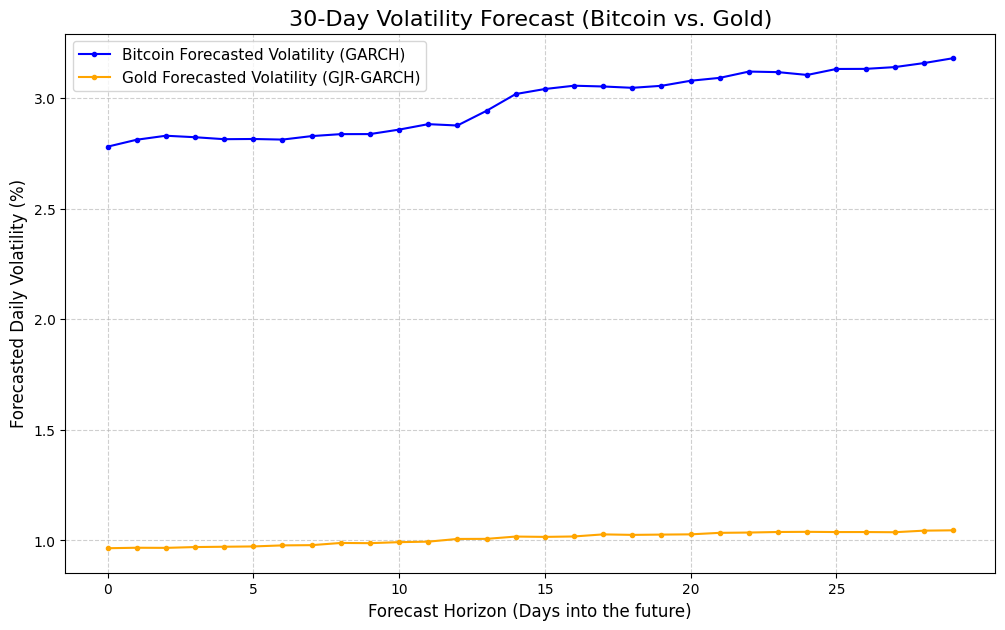

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SET FORECAST HORIZON ---
horizon75_len = len(test75_data)

# --- 2. RUN BITCOIN FORECAST (GARCH) ---
# We use axis=0 to average across the 1000 simulations
fc75_btc = res75_garch_btc.forecast(horizon=horizon75_len, method='simulation', simulations=1000)
btc75_vol_forecast_series = fc75_btc.variance.mean(axis=0)

# --- 3. RUN GOLD FORECAST (GJR-GARCH) ---
# We use axis=0 to average across the 1000 simulations
fc75_gold_gjr = res75_gjr_garch_gold.forecast(horizon=horizon75_len, method='simulation', simulations=1000)
gold75_vol_forecast_series = fc75_gold_gjr.variance.mean(axis=0)

# --- 4. RESCALE AND CONVERT TO % VOLATILITY ---
# Rescale the variance from (return*100)^2 back to return^2
btc75_variance_rescaled = btc75_vol_forecast_series * (1/100)**2
gold75_variance_rescaled = gold75_vol_forecast_series * (1/100)**2

# Convert variance to % volatility (sqrt * 100)
btc75_vol_pct = np.sqrt(btc75_variance_rescaled) * 100
gold75_vol_pct = np.sqrt(gold75_variance_rescaled) * 100

# --- 5. CREATE THE FINAL 30-DAY PLOT ---
days75_to_plot = 30

plt.figure(figsize=(12, 7))

# Plot the first 30 days
# We use .values to plot against a 0-29 index
plt.plot(btc75_vol_pct.values[:days75_to_plot], label='Bitcoin Forecasted Volatility (GARCH)', color='blue', marker='.')
plt.plot(gold75_vol_pct.values[:days75_to_plot], label='Gold Forecasted Volatility (GJR-GARCH)', color='orange', marker='.')

# Add Labels and Title
plt.title('30-Day Volatility Forecast (Bitcoin vs. Gold)', fontsize=16)
plt.xlabel('Forecast Horizon (Days into the future)', fontsize=12)
plt.ylabel('Forecasted Daily Volatility (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.arange(0, days75_to_plot, 5)) # Make the x-axis labels cleaner

plt.show()

In [ ]:
# Set the number of days you want to display
days75_to_display = 30

# --- Display the first 30 data points ---

print("--- Bitcoin Forecasted Daily Volatility (%) [First 30 Days] ---")
# We use .iloc[:days_to_display] to get the first 30
# We convert to a DataFrame for nicer printing
display(pd.DataFrame(btc75_vol_pct.iloc[:days75_to_display], columns=['Forecasted Volatility (%)']))

print("\n--- Gold Forecasted Daily Volatility (%) [First 30 Days] ---")
display(pd.DataFrame(gold75_vol_pct.iloc[:days75_to_display], columns=['Forecasted Volatility (%)']))

--- Bitcoin Forecasted Daily Volatility (%) [First 30 Days] ---


,Forecasted Volatility (%)
h.001,2.779442
h.002,2.810865
h.003,2.828886
h.004,2.822177
h.005,2.813283
h.006,2.814202
h.007,2.811507
h.008,2.827255
h.009,2.836127
h.010,2.836379



--- Gold Forecasted Daily Volatility (%) [First 30 Days] ---


,Forecasted Volatility (%)
h.001,0.964953
h.002,0.967070
h.003,0.966534
h.004,0.970213
h.005,0.971661
h.006,0.973012
h.007,0.977759
h.008,0.978821
h.009,0.988714
h.010,0.987794


## LSTM 75:25


## Multivariate LSTM 75:25


--- Data Shapes (Multivariate 75:25 Split) ---
X_train: (2443, 30, 2)
X_test:  (815, 30, 2)

--- Starting Multivariate Model Training (75:25 Split) ---
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0056 - val_loss: 0.0025
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 7.1164e-04 - val_loss: 0.0010
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 6.2149e-04 - val_loss: 0.0014
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 5.4498e-04 - val_loss: 8.6979e-04
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 4.6633e-04 - val_loss: 7.7675e-04
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 4.6763e-04 - val_loss: 0.0011
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 4.7127e-04 - val_loss: 0.0014
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 3.8289e-04 - val_loss: 0.0013
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 3.8959e-04 - val_loss: 8.9551e-04
Epoch 10/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 4.1316e-04 - val_loss: 0.0011
--- Model Training Complete ---


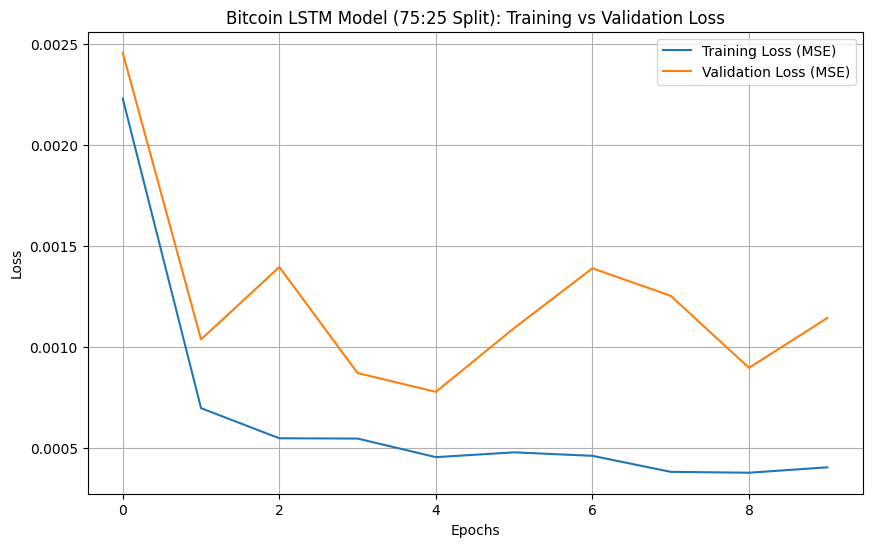


=== Ringkasan Metrik (Multivariate 75:25 Split) ===


,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,4459.83,5.697539e+07,7548.20,14.70
1,Test,8962.91,1.726920e+08,13141.23,4.42


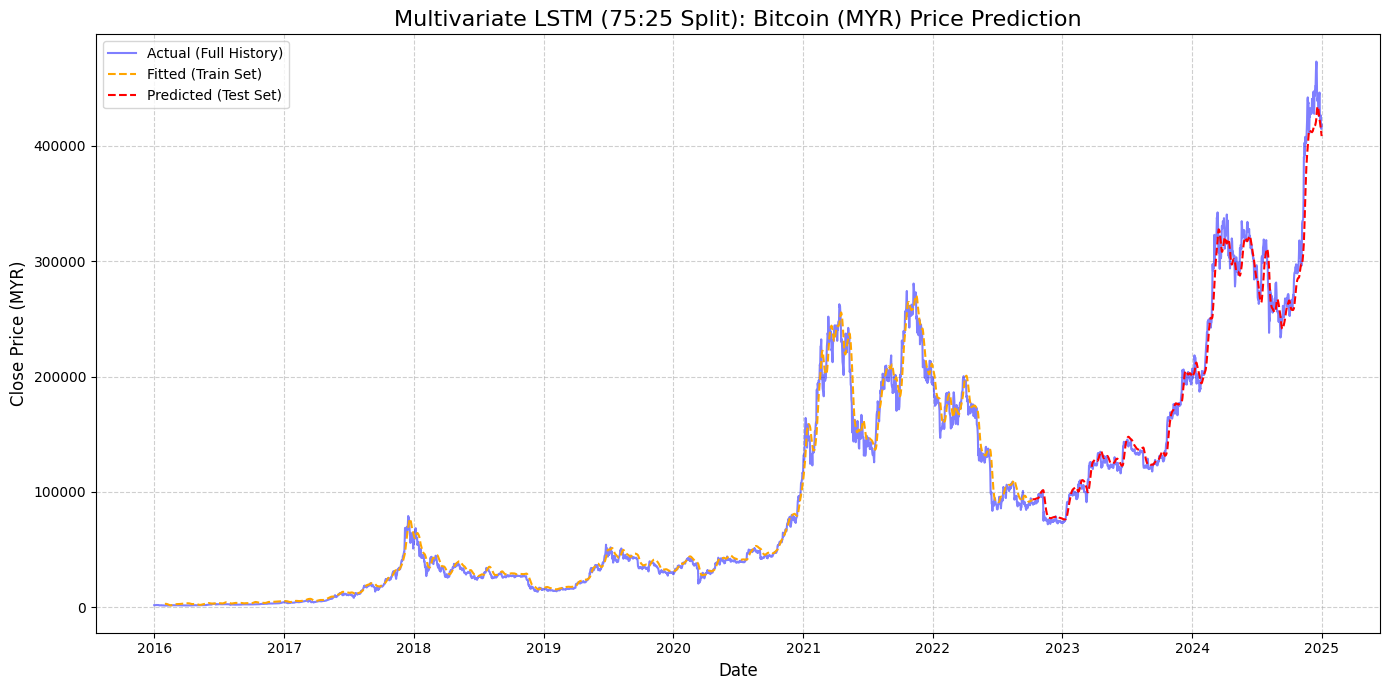

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. SET UP FOR MULTIVARIATE LSTM (75:25) ---
df_75 = merged.copy()   # Use a new df variable
feature_cols_75 = ['Bitcoin', 'Gold']
target_col_75 = 'Bitcoin'
date_col_75 = 'Date'
window_size_75 = 30

# --- 2. SCALING ---
data_to_use_75 = df_75[feature_cols_75].values
scaler_75 = MinMaxScaler(feature_range=(0, 1))
scaled_data_75 = scaler_75.fit_transform(data_to_use_75)

# --- 3. CREATE SEQUENCES (Multivariate) ---
def make_sequences_multi_75(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])   # All features for the window
        y.append(data[i, 0])                 # Only Bitcoin (1st col) as target
    return np.array(X), np.array(y)

X_75, y_75 = make_sequences_multi_75(scaled_data_75, window_size_75)

# --- 4. TRAIN / TEST SPLIT (75% Train, 25% Test) ---
train_split_idx_75 = int(len(X_75) * 0.75)
X_tr_75, y_tr_75 = X_75[:train_split_idx_75], y_75[:train_split_idx_75]
X_test_75, y_test_75 = X_75[train_split_idx_75:], y_75[train_split_idx_75:]

# --- 5. RESHAPE FOR LSTM [samples, timesteps, features] ---
n_features_75 = len(feature_cols_75)
# X_75 is already shaped as (samples, 30, 2)
print("\n--- Data Shapes (Multivariate 75:25 Split) ---")
print(f"X_train: {X_tr_75.shape}")
print(f"X_test:  {X_test_75.shape}")

# --- 7. BUILD & TRAIN MODEL ---
tf.random.set_seed(42)
model_75 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size_75, n_features_75)),
    Dropout(0.1),
    LSTM(32),
    Dropout(0.1),
    Dense(1)   # Predicting Bitcoin only
])
model_75.compile(optimizer="adam", loss="mse")
es_75 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("\n--- Starting Multivariate Model Training (75:25 Split) ---")
history_75 = model_75.fit(
    X_tr_75, y_tr_75,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_75, y_test_75),
    callbacks=[es_75],
    verbose=1
)
print("--- Model Training Complete ---")

# --- TRAINING VS VALIDATION LOSS PLOT (OVERFITTING CHECK) ---
plt.figure(figsize=(10, 6))
plt.plot(history_75.history['loss'], label='Training Loss (MSE)')
plt.plot(history_75.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Bitcoin LSTM Model (75:25 Split): Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- 8. EVALUATION & METRICS (Multivariate 75:25) ---
def inverse_and_metrics_multi_75(y_true_scaled, y_pred_scaled, scaler_obj_75):
    n_features = scaler_obj_75.n_features_in_

    # Rebuild combined arrays to inverse-transform only the Bitcoin column
    pred_combined = np.zeros((len(y_pred_scaled), n_features))
    pred_combined[:, 0] = y_pred_scaled.flatten()
    y_pred = scaler_obj_75.inverse_transform(pred_combined)[:, 0]

    true_combined = np.zeros((len(y_true_scaled), n_features))
    true_combined[:, 0] = y_true_scaled.flatten()
    y_true = scaler_obj_75.inverse_transform(true_combined)[:, 0]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

y_pred_tr_skala_75 = model_75.predict(X_tr_75, verbose=0).flatten()
y_pred_test_skala_75 = model_75.predict(X_test_75, verbose=0).flatten()

y_true_tr_75, y_pred_tr_75, mae_tr_75, mse_tr_75, rmse_tr_75, mape_tr_75 = inverse_and_metrics_multi_75(
    y_tr_75, y_pred_tr_skala_75, scaler_75
)
y_true_test_75, y_pred_test_75, mae_te_75, mse_te_75, rmse_te_75, mape_te_75 = inverse_and_metrics_multi_75(
    y_test_75, y_pred_test_skala_75, scaler_75
)

metrics_df_75 = pd.DataFrame({
    "Set": ["Train", "Test"],
    "MAE": [mae_tr_75, mae_te_75],
    "MSE": [mse_tr_75, mse_te_75],
    "RMSE": [rmse_tr_75, rmse_te_75],
    "MAPE(%)": [mape_tr_75, mape_te_75]
})

print("\n=== Ringkasan Metrik (Multivariate 75:25 Split) ===")
display(metrics_df_75.round(2))

# --- 9. PLOTTING (Full History Plot) ---
date_index_75 = df_75[date_col_75].iloc[window_size_75:]
train_dates_75 = date_index_75.iloc[:train_split_idx_75]
test_dates_75 = date_index_75.iloc[train_split_idx_75:]

plt.figure(figsize=(14, 7))
plt.plot(df_75[date_col_75], df_75[target_col_75],
         label="Actual (Full History)", color='blue', alpha=0.5)
plt.plot(train_dates_75, y_pred_tr_75,
         label="Fitted (Train Set)", color='orange', linestyle='--')
plt.plot(test_dates_75, y_pred_test_75,
         label="Predicted (Test Set)", color='red', linestyle='--')
plt.title("Multivariate LSTM (75:25 Split): Bitcoin (MYR) Price Prediction", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Close Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



--- Data Shapes (Multivariate Gold 75:25 Split) ---
X_train: (2443, 30, 2)
X_test:  (815, 30, 2)

--- Starting Multivariate Model Training (Predicting Gold) ---
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0136 - val_loss: 0.0059
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 7.4699e-04 - val_loss: 0.0038
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 6.9089e-04 - val_loss: 0.0027
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 6.3369e-04 - val_loss: 0.0033
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 5.1437e-04 - val_loss: 0.0036
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 5.0180e-04 - val_loss: 0.0016
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 5.8767e-04 - val_loss: 0.0021
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 5.8145e-04 - val_loss: 0.0028
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 4.6910e-04 - val_loss: 0.0027
Epoch 10/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 4.6347e-04 - val_loss: 0.0020
Epoch 11/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 4.1909e-04 - val_loss: 0.0036
--- Model Training Complete ---

=

,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,77.97,11340.31,106.49,1.22
1,Test,224.28,95038.63,308.28,2.14


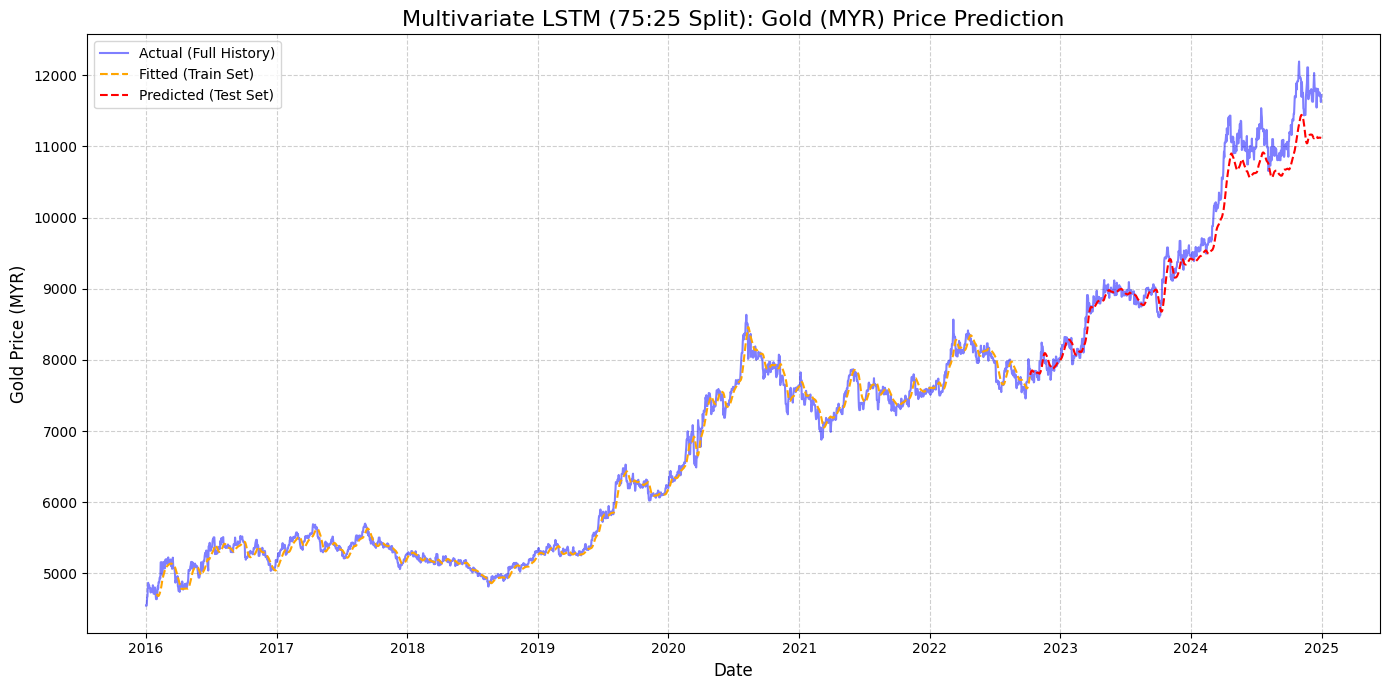

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# --- 3. SET UP FOR MULTIVARIATE LSTM (Predicting Gold) ---
df_gold_75 = merged.copy()
feature_cols_gold_75 = ['Bitcoin', 'Gold'] # <-- Inputs
target_col_gold_75 = 'Gold'               # <-- Output
date_col_gold_75 = 'Date'
window_size_gold_75 = 30

# --- 4. SCALING ---
data_to_use_gold_75 = df_gold_75[feature_cols_gold_75].values
scaler_gold_75 = MinMaxScaler(feature_range=(0, 1)) # New scaler
scaled_data_gold_75 = scaler_gold_75.fit_transform(data_to_use_gold_75)

# --- 5. CREATE SEQUENCES (Multivariate for Gold) ---
def make_sequences_multi_gold_75(data, window_size): # New function
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :]) # All features (BTC & Gold)
        y.append(data[i, 1])               # ⭐ CHANGE: Target is col 1 (Gold)
    return np.array(X), np.array(y)

X_gold_75, y_gold_75 = make_sequences_multi_gold_75(scaled_data_gold_75, window_size_gold_75)

# --- 6. TRAIN / TEST SPLIT (75% Train, 25% Test) ---
train_split_idx_gold_75 = int(len(X_gold_75) * 0.75)
X_tr_gold_75, y_tr_gold_75 = X_gold_75[:train_split_idx_gold_75], y_gold_75[:train_split_idx_gold_75]
X_test_gold_75, y_test_gold_75 = X_gold_75[train_split_idx_gold_75:], y_gold_75[train_split_idx_gold_75:]

# --- 7. RESHAPE FOR LSTM [samples, timesteps, features] ---
n_features_gold_75 = len(feature_cols_gold_75)
print("\n--- Data Shapes (Multivariate Gold 75:25 Split) ---")
print(f"X_train: {X_tr_gold_75.shape}")
print(f"X_test:  {X_test_gold_75.shape}")

# --- 8. BUILD & TRAIN MODEL ---
tf.random.set_seed(42)
model_gold_75 = Sequential([ # New model
    LSTM(64, return_sequences=True, input_shape=(window_size_gold_75, n_features_gold_75)),
    Dropout(0.1),
    LSTM(32),
    Dropout(0.1),
    Dense(1)
])
model_gold_75.compile(optimizer="adam", loss="mse")
es_gold_75 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("\n--- Starting Multivariate Model Training (Predicting Gold) ---")
history_gold_75 = model_gold_75.fit(
    X_tr_gold_75, y_tr_gold_75,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_gold_75, y_test_gold_75),
    callbacks=[es_gold_75],
    verbose=1
)
print("--- Model Training Complete ---")

# --- 9. EVALUATION & METRICS (Multivariate for Gold) ---
def inverse_and_metrics_multi_gold_75(y_true_scaled, y_pred_scaled, scaler_obj_gold_75): # New function
    n_features = scaler_obj_gold_75.n_features_in_

    # ⭐ CHANGE: Put prediction in col 1 (Gold)
    pred_combined = np.zeros((len(y_pred_scaled), n_features))
    pred_combined[:, 1] = y_pred_scaled.flatten()
    y_pred = scaler_obj_gold_75.inverse_transform(pred_combined)[:, 1] # Get col 1

    # ⭐ CHANGE: Put actual in col 1 (Gold)
    true_combined = np.zeros((len(y_true_scaled), n_features))
    true_combined[:, 1] = y_true_scaled.flatten()
    y_true = scaler_obj_gold_75.inverse_transform(true_combined)[:, 1] # Get col 1

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

y_pred_tr_skala_gold_75 = model_gold_75.predict(X_tr_gold_75, verbose=0).flatten()
y_pred_test_skala_gold_75 = model_gold_75.predict(X_test_gold_75, verbose=0).flatten()

y_true_tr_gold_75, y_pred_tr_gold_75, mae_tr_gold_75, mse_tr_gold_75, rmse_tr_gold_75, mape_tr_gold_75 = inverse_and_metrics_multi_gold_75(y_tr_gold_75, y_pred_tr_skala_gold_75, scaler_gold_75)
y_true_test_gold_75, y_pred_test_gold_75, mae_te_gold_75, mse_te_gold_75, rmse_te_gold_75, mape_te_gold_75 = inverse_and_metrics_multi_gold_75(y_test_gold_75, y_pred_test_skala_gold_75, scaler_gold_75)

metrics_df_gold_75 = pd.DataFrame({
    "Set": ["Train", "Test"],
    "MAE": [mae_tr_gold_75, mae_te_gold_75],
    "MSE": [mse_tr_gold_75, mse_te_gold_75],
    "RMSE": [rmse_tr_gold_75, rmse_te_gold_75],
    "MAPE(%)": [mape_tr_gold_75, mape_te_gold_75]
})

print("\n=== Ringkasan Metrik (Multivariate Gold 75:25 Split) ===")
display(metrics_df_gold_75.round(2))

# --- 10. PLOTTING (Full History Plot) ---
date_index_gold_75 = df_gold_75[date_col_gold_75].iloc[window_size_gold_75:]
train_dates_gold_75 = date_index_gold_75.iloc[:train_split_idx_gold_75]
test_dates_gold_75 = date_index_gold_75.iloc[train_split_idx_gold_75:]

plt.figure(figsize=(14, 7))
# ⭐ CHANGE: Plot the 'Gold' column as the actual
plt.plot(df_gold_75[date_col_gold_75], df_gold_75[target_col_gold_75], label="Actual (Full History)", color='blue', alpha=0.5)
plt.plot(train_dates_gold_75, y_pred_tr_gold_75, label="Fitted (Train Set)", color='orange', linestyle='--')
plt.plot(test_dates_gold_75, y_pred_test_gold_75, label="Predicted (Test Set)", color='red', linestyle='--')

# ⭐ CHANGE: Updated titles
plt.title(f"Multivariate LSTM (75:25 Split): Gold (MYR) Price Prediction", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Gold Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


--- Data Shapes (Multivariate Gold 75:25 Split) ---
X_train: (2443, 30, 2)
X_test:  (815, 30, 2)

--- Starting Multivariate Model Training (Predicting Gold) (75:25 Split) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0183 - val_loss: 0.0011
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 9.5072e-04 - val_loss: 0.0016
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 8.6128e-04 - val_loss: 0.0013
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 8.4551e-04 - val_loss: 0.0040
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 7.8155e-04 - val_loss: 0.0024
--- Model Training Complete ---

=== Ringkasan Metrik (Multivariate Gold 75:25 Split) ===


,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,90.30,14411.80,120.05,1.43
1,Test,181.96,64159.43,253.30,1.77


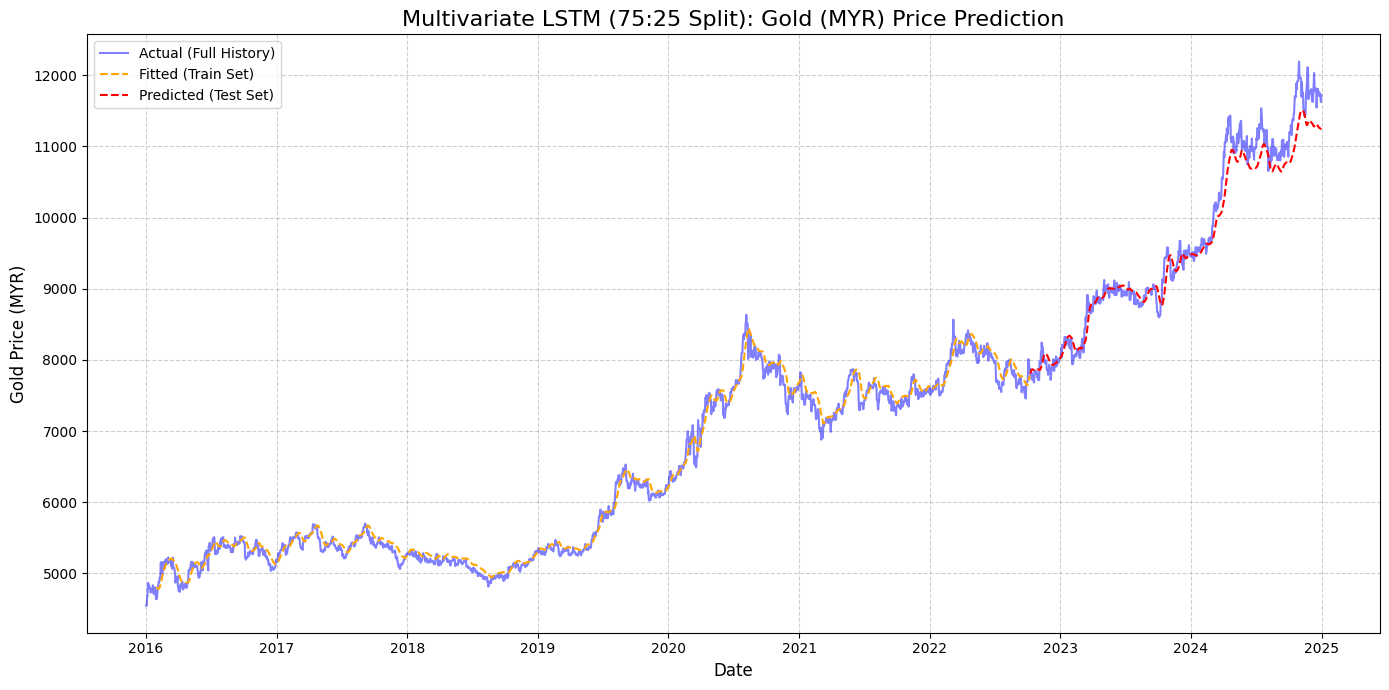

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- 3. SET UP FOR MULTIVARIATE LSTM (Predicting Gold) ---
df_gold_75 = merged.copy() # Renamed df (assuming merged_df is ready)
feature_cols_gold_75 = ['Bitcoin', 'Gold'] # <-- Inputs
target_col_gold_75 = 'Gold'               # <-- Output
date_col_gold_75 = 'Date'
window_size_gold_75 = 30

# --- 4. SCALING ---
data_to_use_gold_75 = df_gold_75[feature_cols_gold_75].values
scaler_gold_75 = MinMaxScaler(feature_range=(0, 1)) # Renamed scaler
scaled_data_gold_75 = scaler_gold_75.fit_transform(data_to_use_gold_75)

# --- 5. CREATE SEQUENCES (Multivariate for Gold) ---
def make_sequences_multi_gold_75(data, window_size): # New function
    X, y = [], []
    for i in range(window_size, len(data)):
        # ⭐ FIX: Corrected indentation
        X.append(data[i-window_size:i, :]) # All features (BTC & Gold)
        y.append(data[i, 1])               # Target is col 1 (Gold)
    return np.array(X), np.array(y)

X_gold_75, y_gold_75 = make_sequences_multi_gold_75(scaled_data_gold_75, window_size_gold_75) # Renamed

# --- 6. TRAIN / TEST SPLIT (75% Train, 25% Test) ---
# ⭐ CHANGE: Updated to 0.75 for 75:25 split
train_split_idx_gold_75 = int(len(X_gold_75) * 0.75)
X_tr_gold_75, y_tr_gold_75 = X_gold_75[:train_split_idx_gold_75], y_gold_75[:train_split_idx_gold_75] # Renamed
X_test_gold_75, y_test_gold_75 = X_gold_75[train_split_idx_gold_75:], y_gold_75[train_split_idx_gold_75:] # Renamed

# --- 7. RESHAPE FOR LSTM [samples, timesteps, features] ---
n_features_gold_75 = len(feature_cols_gold_75)
print("\n--- Data Shapes (Multivariate Gold 75:25 Split) ---") # Updated title
print(f"X_train: {X_tr_gold_75.shape}") # Renamed
print(f"X_test:  {X_test_gold_75.shape}") # Renamed

# --- 8. BUILD & TRAIN MODEL ---
tf.random.set_seed(42)
model_gold_75 = Sequential([ # Renamed model
    LSTM(64, return_sequences=True, input_shape=(window_size_gold_75, n_features_gold_75)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model_gold_75.compile(optimizer="adam", loss="mse")
es_gold_75 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True) # Renamed

print("\n--- Starting Multivariate Model Training (Predicting Gold) (75:25 Split) ---") # Updated title
history_gold_75 = model_gold_75.fit( # Renamed
    X_tr_gold_75, y_tr_gold_75, # Renamed
    epochs=50,
    batch_size=32,
    validation_data=(X_test_gold_75, y_test_gold_75), # Renamed
    callbacks=[es_gold_75], # Renamed
    verbose=1
)
print("--- Model Training Complete ---")

# --- 9. EVALUATION & METRICS (Multivariate for Gold) ---
def inverse_and_metrics_multi_gold_75(y_true_scaled, y_pred_scaled, scaler_obj_gold_75): # New function
    n_features = scaler_obj_gold_75.n_features_in_

    # Put prediction in col 1 (Gold)
    pred_combined = np.zeros((len(y_pred_scaled), n_features))
    pred_combined[:, 1] = y_pred_scaled.flatten()
    y_pred = scaler_obj_gold_75.inverse_transform(pred_combined)[:, 1]

    # Put actual in col 1 (Gold)
    true_combined = np.zeros((len(y_true_scaled), n_features))
    true_combined[:, 1] = y_true_scaled.flatten()
    y_true = scaler_obj_gold_75.inverse_transform(true_combined)[:, 1]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

y_pred_tr_skala_gold_75 = model_gold_75.predict(X_tr_gold_75, verbose=0).flatten() # Renamed
y_pred_test_skala_gold_75 = model_gold_75.predict(X_test_gold_75, verbose=0).flatten() # Renamed

y_true_tr_gold_75, y_pred_tr_gold_75, mae_tr_gold_75, mse_tr_gold_75, rmse_tr_gold_75, mape_tr_gold_75 = inverse_and_metrics_multi_gold_75(y_tr_gold_75, y_pred_tr_skala_gold_75, scaler_gold_75) # Renamed
y_true_test_gold_75, y_pred_test_gold_75, mae_te_gold_75, mse_te_gold_75, rmse_te_gold_75, mape_te_gold_75 = inverse_and_metrics_multi_gold_75(y_test_gold_75, y_pred_test_skala_gold_75, scaler_gold_75) # Renamed

metrics_df_gold_75 = pd.DataFrame({ # Renamed
    "Set": ["Train", "Test"],
    "MAE": [mae_tr_gold_75, mae_te_gold_75],
    "MSE": [mse_tr_gold_75, mse_te_gold_75],
    "RMSE": [rmse_tr_gold_75, rmse_te_gold_75],
    "MAPE(%)": [mape_tr_gold_75, mape_te_gold_75]
})

print("\n=== Ringkasan Metrik (Multivariate Gold 75:25 Split) ===") # Updated title
display(metrics_df_gold_75.round(2)) # Renamed

# --- 10. PLOTTING (Full History Plot) ---
date_index_gold_75 = df_gold_75[date_col_gold_75].iloc[window_size_gold_75:] # Renamed
train_dates_gold_75 = date_index_gold_75.iloc[:train_split_idx_gold_75] # Renamed
test_dates_gold_75 = date_index_gold_75.iloc[train_split_idx_gold_75:] # Renamed

plt.figure(figsize=(14, 7))
plt.plot(df_gold_75[date_col_gold_75], df_gold_75[target_col_gold_75], label="Actual (Full History)", color='blue', alpha=0.5) # Renamed
plt.plot(train_dates_gold_75, y_pred_tr_gold_75, label="Fitted (Train Set)", color='orange', linestyle='--') # Renamed
plt.plot(test_dates_gold_75, y_pred_test_gold_75, label="Predicted (Test Set)", color='red', linestyle='--') # Renamed

plt.title(f"Multivariate LSTM (75:25 Split): Gold (MYR) Price Prediction", fontsize=16) # Updated title
plt.xlabel("Date", fontsize=12)
plt.ylabel("Gold Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 80:20 Split

In [48]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima

# --- 1. Split data (80:20 ratio) ---
# ⭐ CHANGE: Updated to 0.80 and renamed all variables
train_size_80 = int(len(merged) * 0.80)
train_data_80 = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[0:train_size_80]
test_data_80 = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[train_size_80:len(merged)]

print("--- 80:20 Split ---")
print("Training data size (80%):", len(train_data_80))
print("Testing data size (20%):", len(test_data_80))


--- 80:20 Split ---
Training data size (80%): 2628
Testing data size (20%): 658


## ARIMA

In [49]:
# Fit auto_arima model on Bitcoin log returns
model_bitcoin_80 = pm.auto_arima(train_data_80['Bitcoin_logret']*100, start_p=1, start_q=1,
                              max_p=5, max_q=5,
                              m=1,            # frequency of series (set to 1 for non-seasonal data)
                              d=None,         # let the model determine 'd'
                              seasonal=False, # assuming no seasonality
                              test='adf',     # use ADF test to find 'd'
                              trace=True,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)
print("Bitcoin auto ARIMA Model Summary:")
print(model_bitcoin_80.summary())

# Fit auto_arima model on Gold log returns
model_gold_80 = pm.auto_arima(train_data_80['Gold_logret']*100,
                             max_p=5, max_q=5,
                              m=1,            # frequency of series (set to 1 for non-seasonal data)
                              d=None,         # let the model determine 'd'
                              seasonal=False, # assuming no seasonality
                              test='adf',     # use ADF test to find 'd'
                              trace=True,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)
print("\nGold ARIMA(3,0,3) Model Summary:")
print(model_gold_80.summary())

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=14688.339, Time=0.45 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=14692.316, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=14688.955, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=14689.337, Time=0.18 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=14686.695, Time=1.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=14687.316, Time=0.19 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=14686.692, Time=1.80 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=14689.224, Time=0.24 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=14688.679, Time=1.69 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=14688.673, Time=2.80 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=14686.844, Time=2.11 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=14690.714, Time=0.67 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=14690.543, Time=3.43 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=14686.599, Time=5.17 sec
 ARIMA(2,0,1)(0,0,0

#Plot Reja Check

Generating Bitcoin Diagnostic Plots...


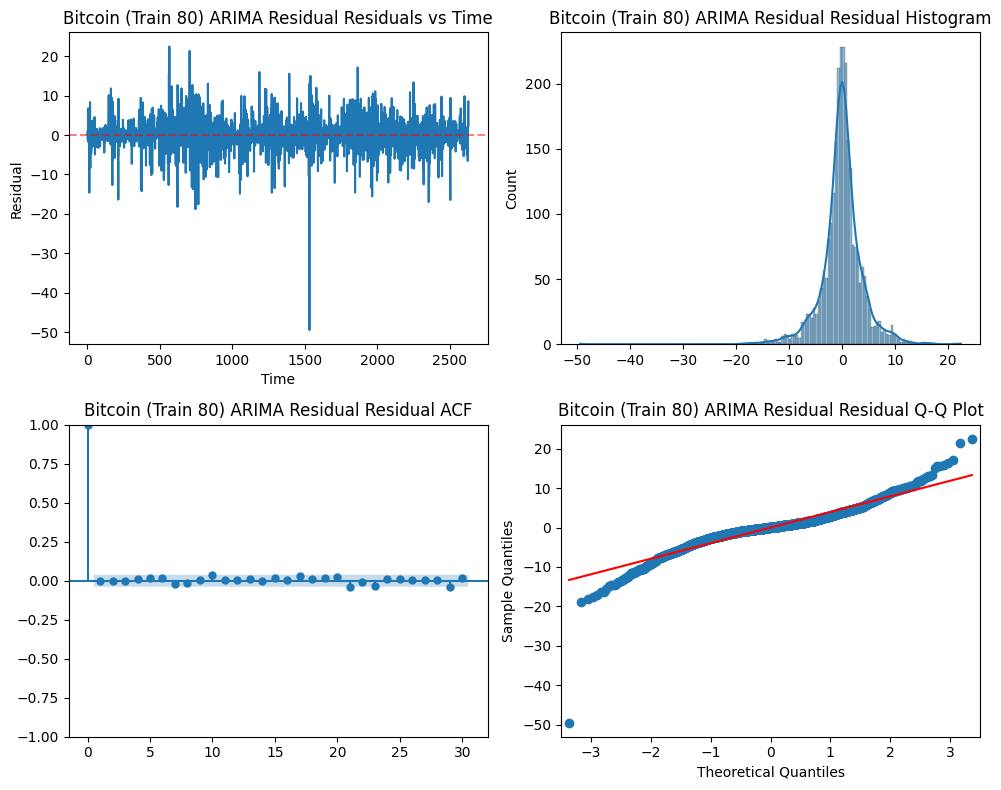

Generating Gold Diagnostic Plots...


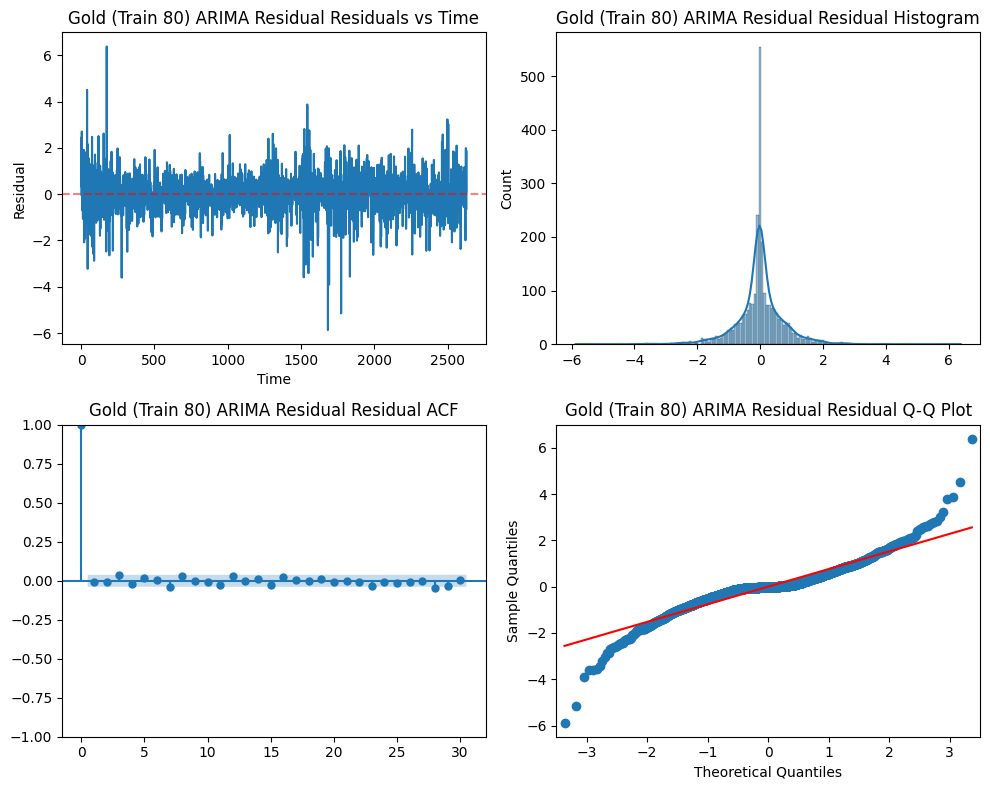

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot

# ================================
# GET RESIDUALS FROM NEW MODEL VARIABLES
# ================================
# 1. Get residuals from the models defined in image_1.png
# The models in the image were trained on data * 100, so these are scaled.
btc_residuals = model_bitcoin_80.resid()
gold_residuals = model_gold_80.resid()

# 2. Assign to the variables used in the plotting logic below
btc_resid_scaled = btc_residuals
gold_resid_scaled = gold_residuals

# ================================
# PLOTTING FUNCTION
# ================================
def residual_diagnostic_plots(residuals, title_prefix):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    # (a) Residual vs Time
    axes[0, 0].plot(residuals)
    axes[0, 0].axhline(0, linestyle='--', color='red', alpha=0.5)
    axes[0, 0].set_title(f'{title_prefix} Residuals vs Time')
    axes[0, 0].set_xlabel('Time')
    axes[0, 0].set_ylabel('Residual')

    # (b) Histogram
    sns.histplot(residuals, kde=True, ax=axes[0, 1])
    axes[0, 1].set_title(f'{title_prefix} Residual Histogram')

    # (c) ACF plot
    # Using lags=30 as a standard default, adjust if needed based on data frequency
    plot_acf(residuals, ax=axes[1, 0], lags=30)
    axes[1, 0].set_title(f'{title_prefix} Residual ACF')

    # (d) Q-Q plot
    qqplot(residuals, line='s', ax=axes[1, 1])
    axes[1, 1].set_title(f'{title_prefix} Residual Q-Q Plot')

    plt.tight_layout()
    plt.show()

# ================================
# GENERATE PLOTS
# ================================
# ---- Bitcoin ----
print("Generating Bitcoin Diagnostic Plots...")
residual_diagnostic_plots(btc_resid_scaled, "Bitcoin (Train 80) ARIMA Residual")

# ---- Gold ----
print("Generating Gold Diagnostic Plots...")
residual_diagnostic_plots(gold_resid_scaled, "Gold (Train 80) ARIMA Residual")

In [ ]:
# ================================
# 4. JARQUE-BERA TEST
# ================================
from statsmodels.stats.stattools import jarque_bera

print("\n=== Jarque-Bera Test: Bitcoin ===")
jb_btc = jarque_bera(btc75_resid_scaled)
print(f"JB stat   : {jb_btc[0]:.4f}")
print(f"JB p-value: {jb_btc[1]:.4f}")
print(f"Skewness  : {jb_btc[2]:.4f}")
print(f"Kurtosis  : {jb_btc[3]:.4f}")

print("\n=== Jarque-Bera Test: Gold ===")
jb_gold = jarque_bera(gold75_resid_scaled)
print(f"JB stat   : {jb_gold[0]:.4f}")
print(f"JB p-value: {jb_gold[1]:.4f}")
print(f"Skewness  : {jb_gold[2]:.4f}")
print(f"Kurtosis  : {jb_gold[3]:.4f}")

In [ ]:
# @title
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# ==========================================
#    CONFIGURATION: AUTO GRID SEARCH
# ==========================================

# Define the maximum order you want to test
# You requested up to 5 (p=0..5, q=0..5)
max_p = 5
max_q = 5
d_value = 0  # Fixed at 0 for Log Returns

# --- AUTOMATICALLY GENERATE CANDIDATE LIST ---
# This creates [(0,0,0)... up to (5,0,5)] -> 36 combinations
grid_search_candidates = [
    (p, d_value, q)
    for p in range(0, max_p + 1)
    for q in range(0, max_q + 1)
]

print(f"Generated {len(grid_search_candidates)} models for grid search.")


# --- HELPER FUNCTION ---
def run_model_list(data, model_list, asset_name):
    results = []
    print(f"Running models for {asset_name}...")

    for param in model_list:
        try:
            # Fit ARIMA model (trend='c' adds intercept)
            model = ARIMA(data, order=param, trend='c')
            model_fit = model.fit()

            results.append({
                'Model': f"ARIMA{param}",
                'AIC': round(model_fit.aic, 2),
                'BIC': round(model_fit.bic, 2)
            })
        except:
            continue

    # Sort by AIC
    df = pd.DataFrame(results)
    df = df.sort_values(by='AIC', ascending=True)
    return df

# ==========================================
#        EXECUTION (SCALED DATA) - 80:20 SPLIT
# ==========================================
# IMPORTANT: Using 'train_data_80' from your image

# 1. Run Bitcoin List (Using train_data_80)
df_btc_80 = run_model_list(train_data_80['Bitcoin_logret'] * 100, grid_search_candidates, "Bitcoin (80:20)")

# 2. Run Gold List (Using train_data_80)
df_gold_80 = run_model_list(train_data_80['Gold_logret'] * 100, grid_search_candidates, "Gold (80:20)")


# --- PRINT RESULTS ---
print("\n" + "="*40)
print(" BITCOIN MODEL SELECTION (80:20 SPLIT)")
print("="*40)
print(df_btc_80) # Printing top 10 best models

print("\n" + "="*40)
print("   GOLD MODEL SELECTION (80:20 SPLIT)")
print("="*40)
print(df_gold_80) # Printing top 10 best models

Generated 36 models for grid search.
Running models for Bitcoin (80:20)...
Running models for Gold (80:20)...

 BITCOIN MODEL SELECTION (80:20 SPLIT)
             Model       AIC       BIC
16  ARIMA(2, 0, 4)  14662.51  14709.50
12  ARIMA(2, 0, 0)  14663.61  14687.10
2   ARIMA(0, 0, 2)  14663.63  14687.12
13  ARIMA(2, 0, 1)  14664.32  14693.70
19  ARIMA(3, 0, 1)  14664.44  14699.69
9   ARIMA(1, 0, 3)  14664.51  14699.76
14  ARIMA(2, 0, 2)  14664.63  14699.88
7   ARIMA(1, 0, 1)  14664.67  14688.17
8   ARIMA(1, 0, 2)  14664.70  14694.08
6   ARIMA(1, 0, 0)  14665.13  14682.75
1   ARIMA(0, 0, 1)  14665.46  14683.08
18  ARIMA(3, 0, 0)  14665.52  14694.89
3   ARIMA(0, 0, 3)  14665.62  14694.99
20  ARIMA(3, 0, 2)  14666.43  14707.55
25  ARIMA(4, 0, 1)  14666.43  14707.55
15  ARIMA(2, 0, 3)  14666.43  14707.55
10  ARIMA(1, 0, 4)  14666.44  14707.56
24  ARIMA(4, 0, 0)  14667.20  14702.44
4   ARIMA(0, 0, 4)  14667.21  14702.45
0   ARIMA(0, 0, 0)  14667.82  14679.57
5   ARIMA(0, 0, 5)  14668.17  1

In [ ]:
from arch import arch_model

# --- 1. Get residuals from your 80:20 auto_arima models ---
# ⭐ FIX: Use the _80 models
btc_residuals_80 = model_bitcoin_80.resid()
gold_residuals_80 = model_gold_80.resid()

# --- 2. Rescale the residuals ---
# ⭐ FIX: Renamed variables
btc_resid_scaled_80 = btc_residuals_80 * 100
gold_resid_scaled_80 = gold_residuals_80 * 100

# --- 3. Fit GARCH(1,1) on Bitcoin 80:20 Residuals ---
# ⭐ FIX: Renamed variables
garch_btc_80 = arch_model(btc_resid_scaled_80,
                            mean='Zero',
                            vol='Garch', p=1, q=1,
                            dist='t')

res_garch_btc_80 = garch_btc_80.fit(disp='off')
print("Bitcoin GARCH(1,1) on ARMA Residuals (80:20 Split, t-dist):")
print(res_garch_btc_80.summary())

# --- 4. Fit GARCH(1,1) on Gold 80:20 Residuals ---
# ⭐ FIX: Renamed variables
garch_gold_80 = arch_model(gold_resid_scaled_80,
                             mean='Zero',
                             vol='Garch', p=1, q=1,
                             dist='t')

res_garch_gold_80 = garch_gold_80.fit(disp='off')
print("\nGold GARCH(1,1) on MA Residuals (80:20 Split, t-dist):")
print(res_garch_gold_80.summary())

# --- 5. Fit EGARCH(1,1) on Gold 80:20 Residuals ---
# ⭐ FIX: Renamed variables
egarch_gold1_80 = arch_model(gold_resid_scaled_80,
                               mean='Zero',
                               vol='EGARCH', p=1, q=1,
                               dist='t')

res_egarch_gold1_80 = egarch_gold1_80.fit(disp='off')
print("\nGold EGARCH(1,1) on MA Residuals (80:20 Split, t-dist):")
print(res_egarch_gold1_80.summary())

# --- 6. Fit EGARCH(2,2) on Gold 80:20 Residuals ---
# ⭐ FIX: Renamed variables
egarch_gold2_80 = arch_model(gold_resid_scaled_80,
                               mean='Zero',
                               vol='EGARCH', p=2, q=2,
                               dist='t')

res_egarch_gold2_80 = egarch_gold2_80.fit(disp='off')
print("\nGold EGARCH(2,2) on MA Residuals (80:20 Split, t-dist):")
print(res_egarch_gold2_80.summary())


Bitcoin GARCH(1,1) on ARMA Residuals (80:20 Split, t-dist):
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -6776.85
Distribution:      Standardized Student's t   AIC:                           13561.7
Method:                  Maximum Likelihood   BIC:                           13585.2
                                              No. Observations:                 2629
Date:                      Wed, Nov 05 2025   Df Residuals:                     2629
Time:                              12:57:13   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
-----------------------

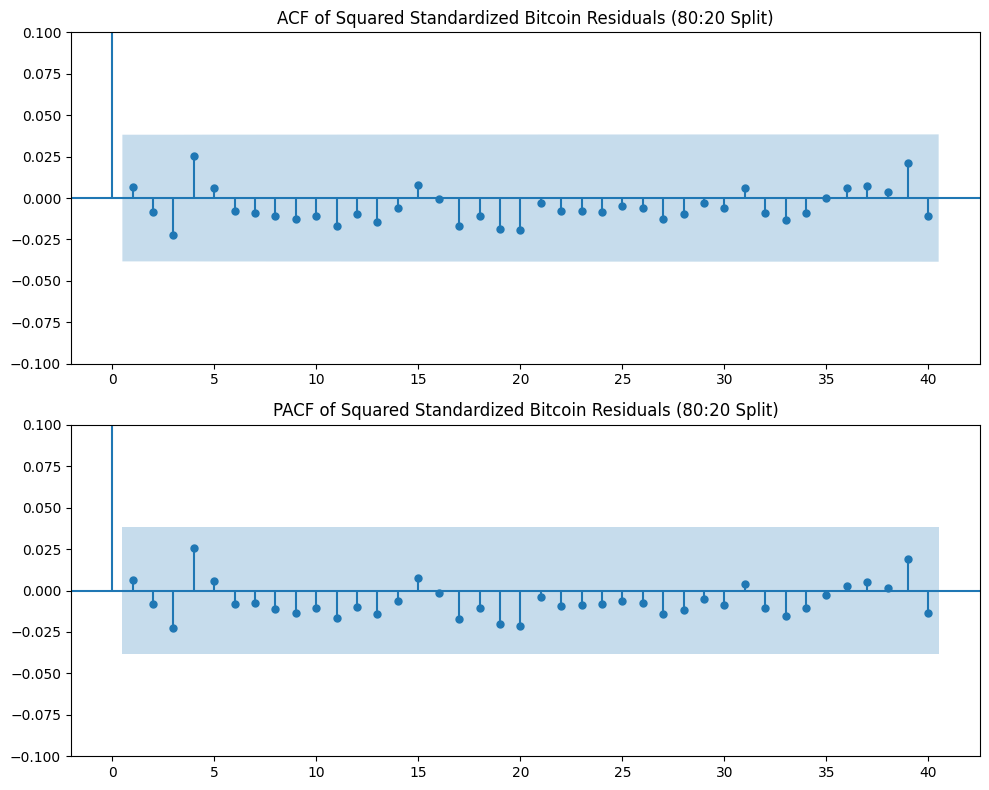

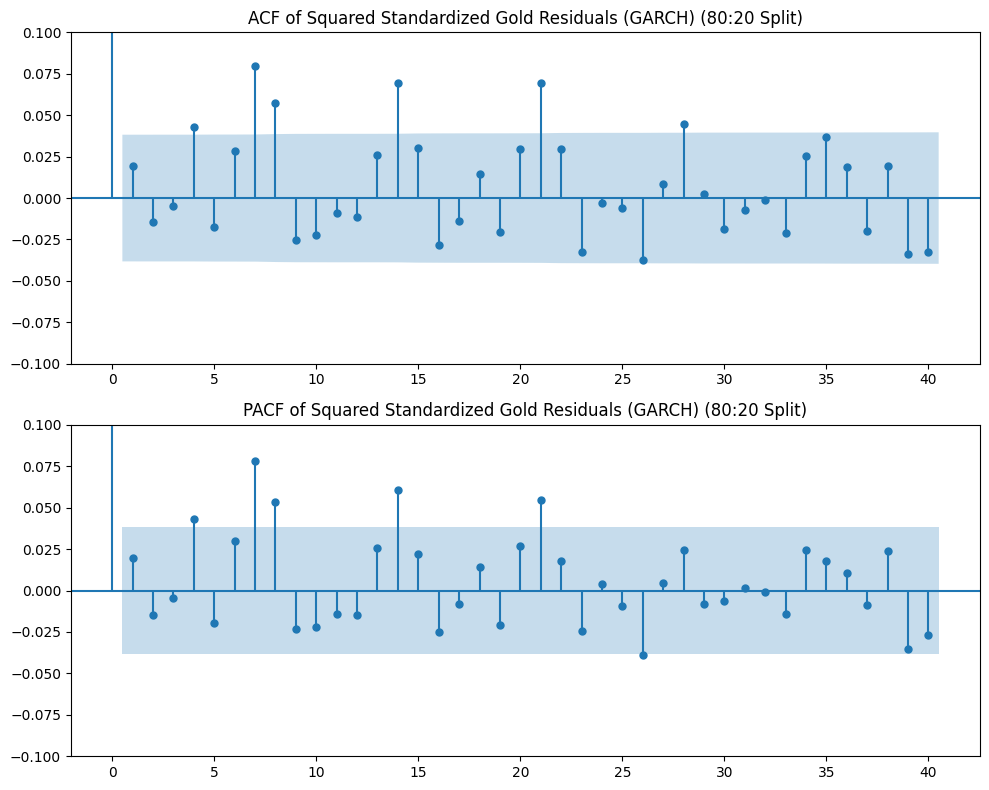

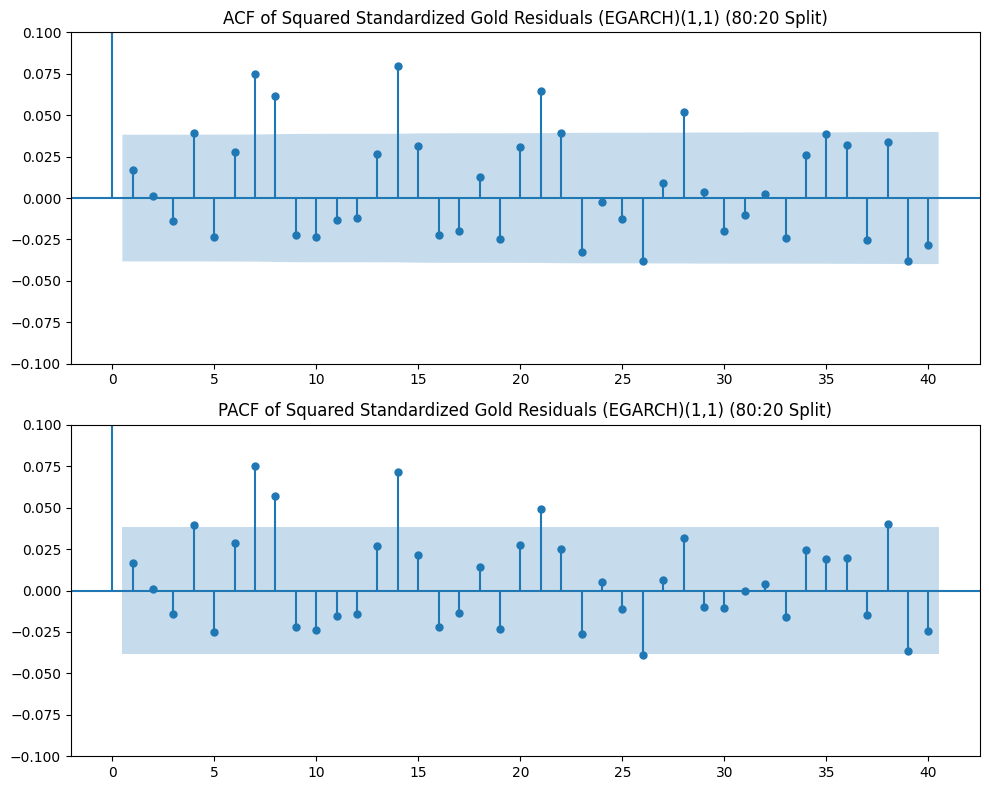

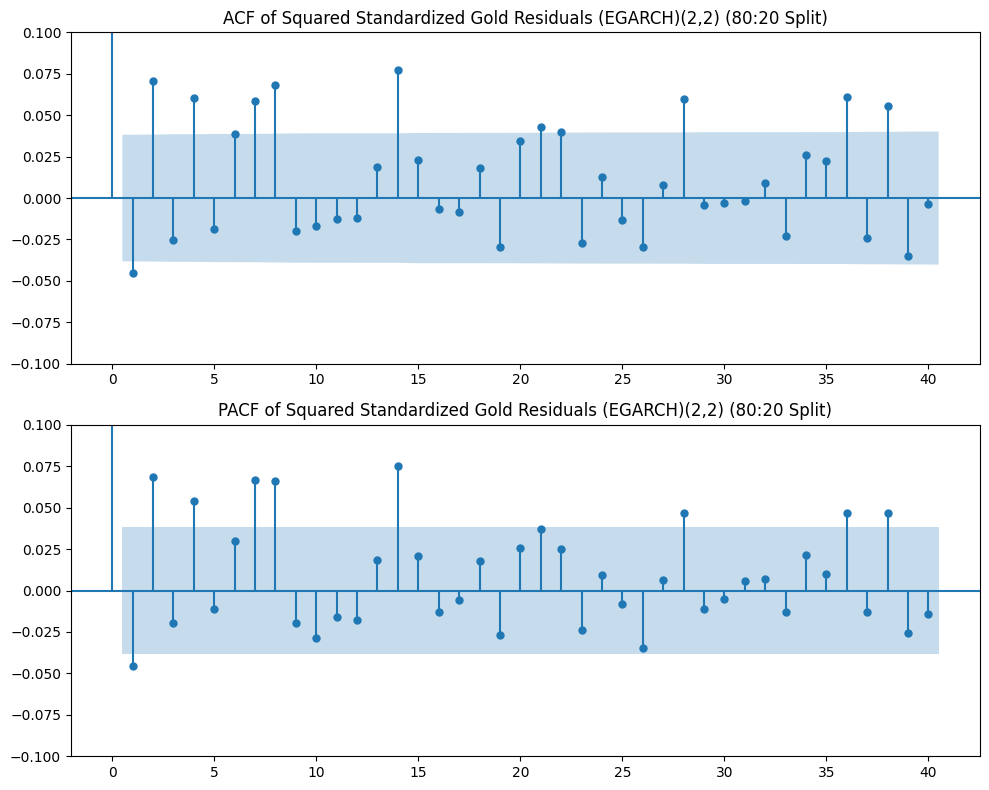

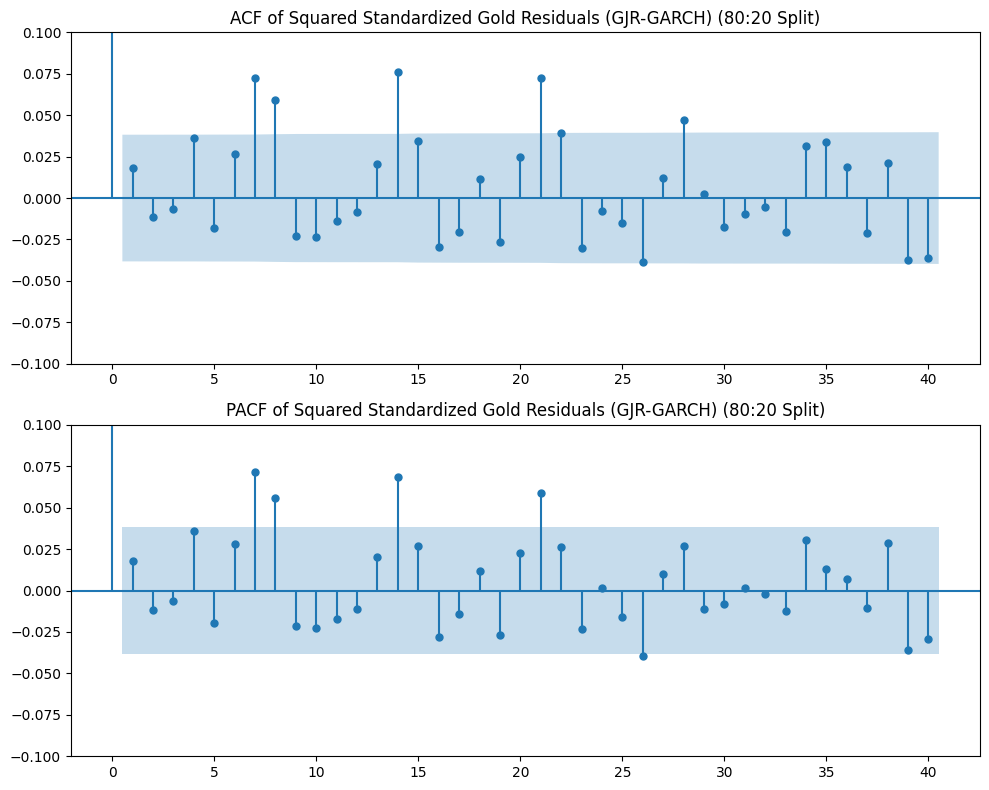

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np

# --- 1. Get the standardized residuals (80:20) ---
# ⭐ FIX: Use the _80 model results
btc_std_resid_80 = res_garch_btc_80.std_resid
gold_std_resid_80 = res_garch_gold_80.std_resid

# --- 2. Square the standardized residuals ---
# ⭐ FIX: Renamed variables
btc_std_resid_sq_80 = btc_std_resid_80**2
gold_std_resid_sq_80 = gold_std_resid_80**2

# --- 3. Plot ACF and PACF for Bitcoin (80:20) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(btc_std_resid_sq_80.dropna(), ax=axes[0], lags=40)
plot_pacf(btc_std_resid_sq_80.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Bitcoin Residuals (80:20 Split)')
axes[1].set_title('PACF of Squared Standardized Bitcoin Residuals (80:20 Split)')
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])
plt.tight_layout()
plt.show()

# --- 4. Plot ACF and PACF for Gold residuals (GARCH) (80:20) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_sq_80.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq_80.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (GARCH) (80:20 Split)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (GARCH) (80:20 Split)')
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])
plt.tight_layout()
plt.show()

# --- 5. Get standardized residuals for other Gold models (80:20) ---
# ⭐ FIX: Use the _80 model results
gold_std_resid_egarch1_80 = res_egarch_gold1_80.std_resid
gold_std_resid_egarch2_80 = res_egarch_gold2_80.std_resid
gold_std_resid_gjr_garch_80 = res_gjr_garch_gold_80.std_resid

# --- 6. Square the standardized residuals ---
# ⭐ FIX: Renamed variables
gold_std_resid_sq_egarch1_80 = gold_std_resid_egarch1_80**2
gold_std_resid_sq_egarch2_80 = gold_std_resid_egarch2_80**2
gold_std_resid_sq_gjr_garch_80 = gold_std_resid_gjr_garch_80**2

# --- 7. Plot ACF and PACF for Gold residuals (EGARCH)(1,1) (80:20) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_sq_egarch1_80.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq_egarch1_80.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (EGARCH)(1,1) (80:20 Split)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (EGARCH)(1,1) (80:20 Split)')
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])
plt.tight_layout()
plt.show()

# --- 8. Plot ACF and PACF for Gold residuals (EGARCH)(2,2) (80:20) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_sq_egarch2_80.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq_egarch2_80.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (EGARCH)(2,2) (80:20 Split)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (EGARCH)(2,2) (80:20 Split)')
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])
plt.tight_layout()
plt.show()

# --- 9. Plot ACF and PACF for Gold residuals (GJR-GARCH) (80:20) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(gold_std_resid_sq_gjr_garch_80.dropna(), ax=axes[0], lags=40)
plot_pacf(gold_std_resid_sq_gjr_garch_80.dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF of Squared Standardized Gold Residuals (GJR-GARCH) (80:20 Split)')
axes[1].set_title('PACF of Squared Standardized Gold Residuals (GJR-GARCH) (80:20 Split)')
axes[0].set_ylim([-0.1, 0.1])
axes[1].set_ylim([-0.1, 0.1])
plt.tight_layout()
plt.show()

# Multivariate LSTM 80:20


--- Data Shapes (Multivariate 80:20 Split) ---
X_train: (2606, 30, 2)
X_test:  (652, 30, 2)

--- Starting Multivariate Model Training (80:20 Split) ---
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0053 - val_loss: 0.0012
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 7.3990e-04 - val_loss: 0.0012
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 5.8275e-04 - val_loss: 9.4244e-04
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 5.3506e-04 - val_loss: 9.5617e-04
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 4.5850e-04 - val_loss: 7.5031e-04
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 4.5131e-04 - val_loss: 0.0011
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 4.9834e-04 - val_loss: 0.0019
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 3.6330e-04 - val_loss: 0.0010
Epoch 9/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 4.1736e-04 - val_loss: 0.0014
Epoch 10/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 3.9603e-04 - val_loss: 6.1759e-04
Epoch 11/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 3.4980e-04 - val_loss: 0.0016
Epoch 12/50
82/82 

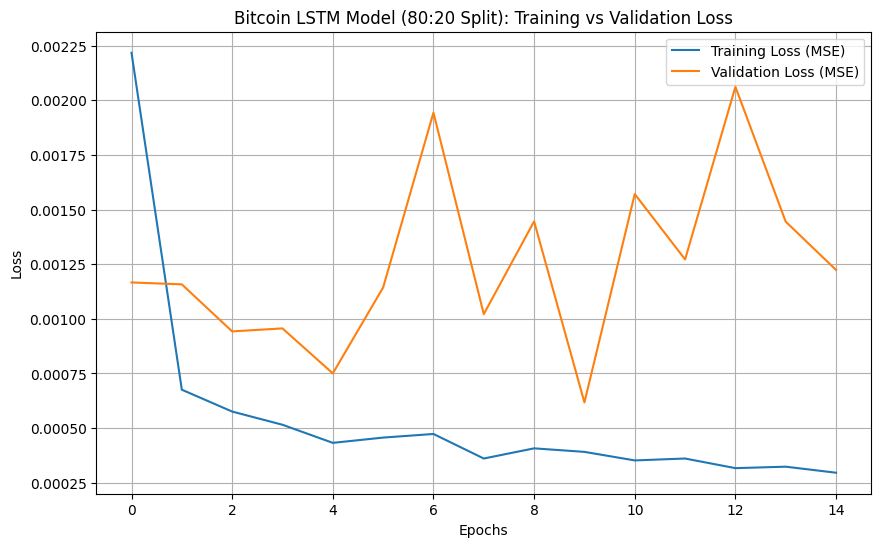


=== Ringkasan Metrik (Multivariate 80:20 Split) ===


,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,4685.34,5.602409e+07,7484.92,10.62
1,Test,8967.55,1.373060e+08,11717.77,4.23


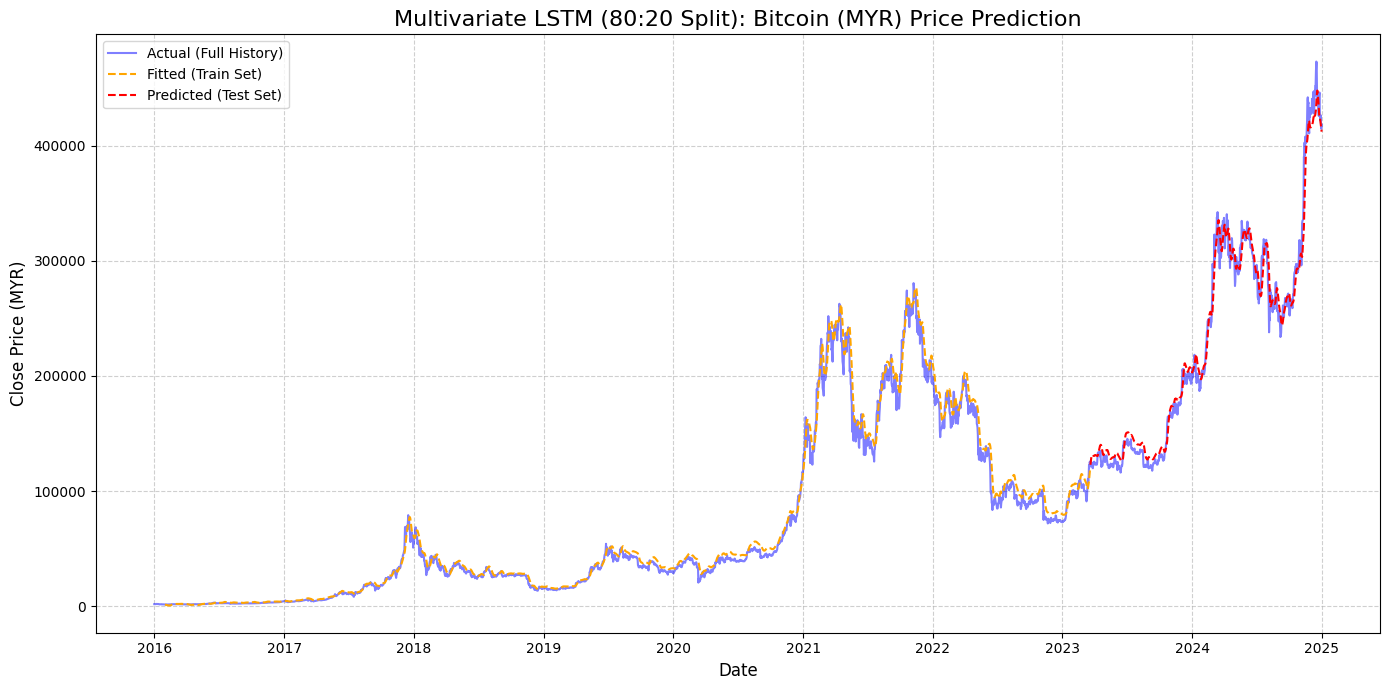

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. SET UP FOR MULTIVARIATE LSTM ---
df_80 = merged.copy()  # Renamed df
feature_cols_80 = ['Bitcoin', 'Gold']
target_col_80 = 'Bitcoin'
date_col_80 = 'Date'
window_size_80 = 30

# --- 2. SCALING ---
data_to_use_80 = df_80[feature_cols_80].values
scaler_80 = MinMaxScaler(feature_range=(0, 1))
scaled_data_80 = scaler_80.fit_transform(data_to_use_80)

# --- 3. CREATE SEQUENCES (Multivariate) ---
def make_sequences_multi_80(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])   # All features for the window
        y.append(data[i, 0])                 # Bitcoin (1st col) as target
    return np.array(X), np.array(y)

X_80, y_80 = make_sequences_multi_80(scaled_data_80, window_size_80)

# --- 4. TRAIN / TEST SPLIT (80% Train, 20% Test) ---
train_split_idx_80 = int(len(X_80) * 0.80)
X_tr_80, y_tr_80 = X_80[:train_split_idx_80], y_80[:train_split_idx_80]
X_test_80, y_test_80 = X_80[train_split_idx_80:], y_80[train_split_idx_80:]

# --- 5. RESHAPE FOR LSTM [samples, timesteps, features] ---
n_features_80 = len(feature_cols_80)
print("\n--- Data Shapes (Multivariate 80:20 Split) ---")
print(f"X_train: {X_tr_80.shape}")
print(f"X_test:  {X_test_80.shape}")

# --- 7. BUILD & TRAIN MODEL ---
tf.random.set_seed(42)
model_80 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size_80, n_features_80)),
    Dropout(0.1),
    LSTM(32),
    Dropout(0.1),
    Dense(1)  # Predict Bitcoin only
])
model_80.compile(optimizer="adam", loss="mse")
es_80 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("\n--- Starting Multivariate Model Training (80:20 Split) ---")
history_80 = model_80.fit(
    X_tr_80, y_tr_80,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_80, y_test_80),
    callbacks=[es_80],
    verbose=1
)
print("--- Model Training Complete ---")

# --- TRAINING VS VALIDATION LOSS PLOT ---
plt.figure(figsize=(10, 6))
plt.plot(history_80.history['loss'], label='Training Loss (MSE)')
plt.plot(history_80.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Bitcoin LSTM Model (80:20 Split): Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- 8. EVALUATION & METRICS (Multivariate) ---
def inverse_and_metrics_multi_80(y_true_scaled, y_pred_scaled, scaler_obj):
    n_features = scaler_obj.n_features_in_

    pred_combined = np.zeros((len(y_pred_scaled), n_features))
    pred_combined[:, 0] = y_pred_scaled.flatten()
    y_pred = scaler_obj.inverse_transform(pred_combined)[:, 0]

    true_combined = np.zeros((len(y_true_scaled), n_features))
    true_combined[:, 0] = y_true_scaled.flatten()
    y_true = scaler_obj.inverse_transform(true_combined)[:, 0]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

y_pred_tr_skala_80 = model_80.predict(X_tr_80, verbose=0).flatten()
y_pred_test_skala_80 = model_80.predict(X_test_80, verbose=0).flatten()

y_true_tr_80, y_pred_tr_80, mae_tr_80, mse_tr_80, rmse_tr_80, mape_tr_80 = inverse_and_metrics_multi_80(
    y_tr_80, y_pred_tr_skala_80, scaler_80
)
y_true_test_80, y_pred_test_80, mae_te_80, mse_te_80, rmse_te_80, mape_te_80 = inverse_and_metrics_multi_80(
    y_test_80, y_pred_test_skala_80, scaler_80
)

metrics_df_80 = pd.DataFrame({
    "Set": ["Train", "Test"],
    "MAE": [mae_tr_80, mae_te_80],
    "MSE": [mse_tr_80, mse_te_80],
    "RMSE": [rmse_tr_80, rmse_te_80],
    "MAPE(%)": [mape_tr_80, mape_te_80]
})

print("\n=== Ringkasan Metrik (Multivariate 80:20 Split) ===")
display(metrics_df_80.round(2))

# --- 9. PLOTTING (Full History Plot) ---
date_index_80 = df_80[date_col_80].iloc[window_size_80:]
train_dates_80 = date_index_80.iloc[:train_split_idx_80]
test_dates_80 = date_index_80.iloc[train_split_idx_80:]

plt.figure(figsize=(14, 7))
plt.plot(df_80[date_col_80], df_80[target_col_80],
         label="Actual (Full History)", color='blue', alpha=0.5)
plt.plot(train_dates_80, y_pred_tr_80,
         label="Fitted (Train Set)", color='orange', linestyle='--')
plt.plot(test_dates_80, y_pred_test_80,
         label="Predicted (Test Set)", color='red', linestyle='--')
plt.title("Multivariate LSTM (80:20 Split): Bitcoin (MYR) Price Prediction", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Close Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



--- Data Shapes (Multivariate Gold 80:20 Split) ---
X_train: (2606, 30, 2)
X_test:  (652, 30, 2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Starting Multivariate Model Training (Predicting Gold) (80:20 Split) ---
Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.0177 - val_loss: 6.1184e-04
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 9.0760e-04 - val_loss: 5.5647e-04
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 7.3531e-04 - val_loss: 4.9653e-04
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 6.6346e-04 - val_loss: 7.7365e-04
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 6.8410e-04 - val_loss: 7.8601e-04
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 5.9293e-04 - val_loss: 6.7275e-04
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 6.3595e-04 - val_loss: 5.9220e-04
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 5.3242e-04 - val_loss: 8.3982e-04
--- Model Training Complete ---

=== Ringkasan Metrik (Multivariate Gold 80:20 Split) ===


,Set,MAE,MSE,RMSE,MAPE(%)
0,Train,80.89,12130.71,110.14,1.24
1,Test,127.02,29025.07,170.37,1.23


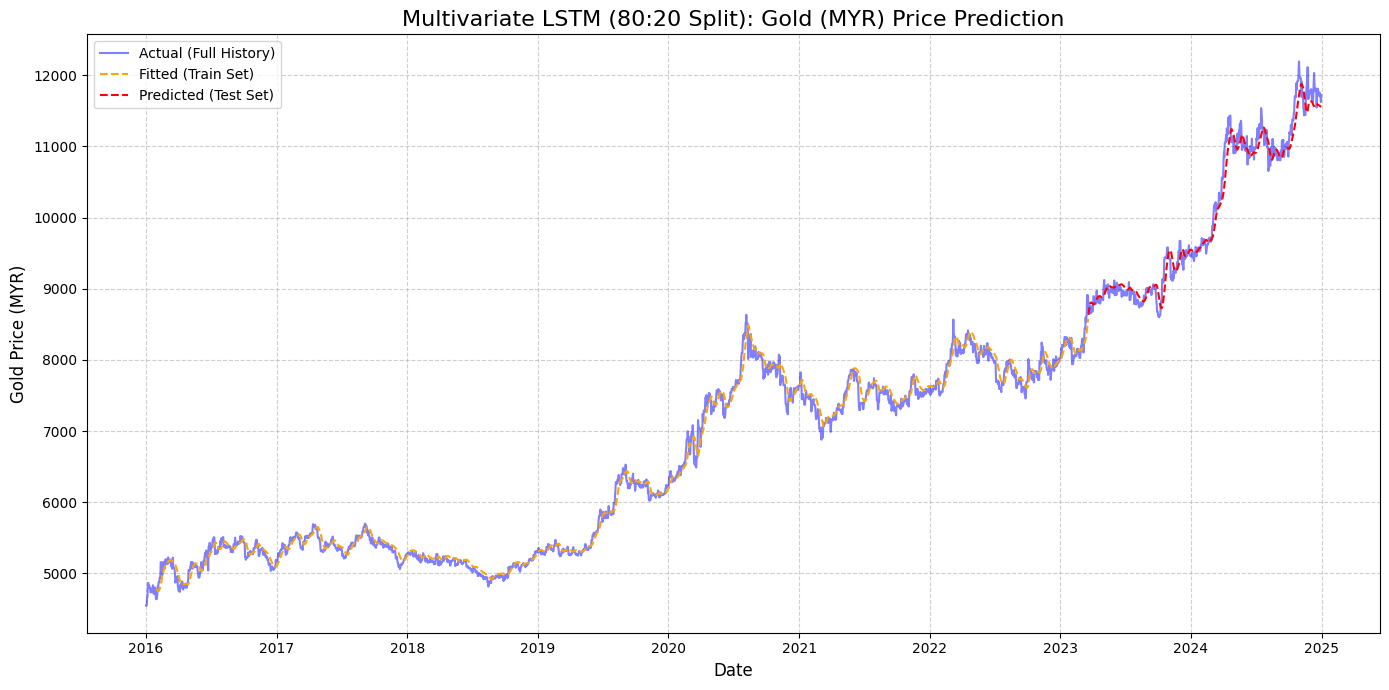

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# --- 3. SET UP FOR MULTIVARIATE LSTM (Predicting Gold) ---
df_gold_80 = merged.copy() # Renamed df
feature_cols_gold_80 = ['Bitcoin', 'Gold']
target_col_gold_80 = 'Gold'
date_col_gold_80 = 'Date'
window_size_gold_80 = 30

# --- 4. SCALING ---
data_to_use_gold_80 = df_gold_80[feature_cols_gold_80].values
scaler_gold_80 = MinMaxScaler(feature_range=(0, 1)) # Renamed scaler
scaled_data_gold_80 = scaler_gold_80.fit_transform(data_to_use_gold_80)

# --- 5. CREATE SEQUENCES (Multivariate for Gold) ---
def make_sequences_multi_gold_80(data, window_size): # Renamed function
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :]) # All features (BTC & Gold)
        y.append(data[i, 1])               # Target is col 1 (Gold)
    return np.array(X), np.array(y)

X_gold_80, y_gold_80 = make_sequences_multi_gold_80(scaled_data_gold_80, window_size_gold_80) # Renamed

# --- 6. TRAIN / TEST SPLIT (80% Train, 20% Test) ---
# ⭐ CHANGE: Updated to 0.80 for 80:20 split
train_split_idx_gold_80 = int(len(X_gold_80) * 0.80)
X_tr_gold_80, y_tr_gold_80 = X_gold_80[:train_split_idx_gold_80], y_gold_80[:train_split_idx_gold_80] # Renamed
X_test_gold_80, y_test_gold_80 = X_gold_80[train_split_idx_gold_80:], y_gold_80[train_split_idx_gold_80:] # Renamed

# --- 7. RESHAPE FOR LSTM [samples, timesteps, features] ---
n_features_gold_80 = len(feature_cols_gold_80)
print("\n--- Data Shapes (Multivariate Gold 80:20 Split) ---") # Updated title
print(f"X_train: {X_tr_gold_80.shape}") # Renamed
print(f"X_test:  {X_test_gold_80.shape}") # Renamed

# --- 8. BUILD & TRAIN MODEL ---
tf.random.set_seed(42)
model_gold_80 = Sequential([ # Renamed model
    LSTM(64, return_sequences=True, input_shape=(window_size_gold_80, n_features_gold_80)),
    Dropout(0.1),
    LSTM(32),
    Dropout(0.1),
    Dense(1)
])
model_gold_80.compile(optimizer="adam", loss="mse")
es_gold_80 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True) # Renamed

print("\n--- Starting Multivariate Model Training (Predicting Gold) (80:20 Split) ---") # Updated title
history_gold_80 = model_gold_80.fit( # Renamed
    X_tr_gold_80, y_tr_gold_80, # Renamed
    epochs=50,
    batch_size=32,
    validation_data=(X_test_gold_80, y_test_gold_80), # Renamed
    callbacks=[es_gold_80], # Renamed
    verbose=1
)
print("--- Model Training Complete ---")

# --- 9. EVALUATION & METRICS (Multivariate for Gold) ---
def inverse_and_metrics_multi_gold_80(y_true_scaled, y_pred_scaled, scaler_obj_gold_80): # Renamed function
    n_features = scaler_obj_gold_80.n_features_in_

    # Put prediction in col 1 (Gold)
    pred_combined = np.zeros((len(y_pred_scaled), n_features))
    pred_combined[:, 1] = y_pred_scaled.flatten()
    y_pred = scaler_obj_gold_80.inverse_transform(pred_combined)[:, 1]

    # Put actual in col 1 (Gold)
    true_combined = np.zeros((len(y_true_scaled), n_features))
    true_combined[:, 1] = y_true_scaled.flatten()
    y_true = scaler_obj_gold_80.inverse_transform(true_combined)[:, 1]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100
    return y_true, y_pred, mae, mse, rmse, mape

y_pred_tr_skala_gold_80 = model_gold_80.predict(X_tr_gold_80, verbose=0).flatten() # Renamed
y_pred_test_skala_gold_80 = model_gold_80.predict(X_test_gold_80, verbose=0).flatten() # Renamed

y_true_tr_gold_80, y_pred_tr_gold_80, mae_tr_gold_80, mse_tr_gold_80, rmse_tr_gold_80, mape_tr_gold_80 = inverse_and_metrics_multi_gold_80(y_tr_gold_80, y_pred_tr_skala_gold_80, scaler_gold_80) # Renamed
y_true_test_gold_80, y_pred_test_gold_80, mae_te_gold_80, mse_te_gold_80, rmse_te_gold_80, mape_te_gold_80 = inverse_and_metrics_multi_gold_80(y_test_gold_80, y_pred_test_skala_gold_80, scaler_gold_80) # Renamed

metrics_df_gold_80 = pd.DataFrame({ # Renamed
    "Set": ["Train", "Test"],
    "MAE": [mae_tr_gold_80, mae_te_gold_80],
    "MSE": [mse_tr_gold_80, mse_te_gold_80],
    "RMSE": [rmse_tr_gold_80, rmse_te_gold_80],
    "MAPE(%)": [mape_tr_gold_80, mape_te_gold_80]
})

print("\n=== Ringkasan Metrik (Multivariate Gold 80:20 Split) ===") # Updated title
display(metrics_df_gold_80.round(2)) # Renamed

# --- 10. PLOTTING (Full History Plot) ---
date_index_gold_80 = df_gold_80[date_col_gold_80].iloc[window_size_gold_80:] # Renamed
train_dates_gold_80 = date_index_gold_80.iloc[:train_split_idx_gold_80] # Renamed
test_dates_gold_80 = date_index_gold_80.iloc[train_split_idx_gold_80:] # Renamed

plt.figure(figsize=(14, 7))
plt.plot(df_gold_80[date_col_gold_80], df_gold_80[target_col_gold_80], label="Actual (Full History)", color='blue', alpha=0.5) # Renamed
plt.plot(train_dates_gold_80, y_pred_tr_gold_80, label="Fitted (Train Set)", color='orange', linestyle='--') # Renamed
plt.plot(test_dates_gold_80, y_pred_test_gold_80, label="Predicted (Test Set)", color='red', linestyle='--') # Renamed

plt.title(f"Multivariate LSTM (80:20 Split): Gold (MYR) Price Prediction", fontsize=16) # Updated title
plt.xlabel("Date", fontsize=12)
plt.ylabel("Gold Price (MYR)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()